# Análisis del dataset High-Resolution Floating Solar PV Data
https://catalog.data.gov/dataset/high-resolution-floating-solar-pv-data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Información básica (vistazo general)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
df_ambiente = pd.read_csv('/content/drive/MyDrive/TFM-Unir/Desarrollo/FSEC_Regional_Test_Ambient_data.csv').drop(['Unnamed: 0'], axis=1)

In [ ]:
df_sensores = pd.read_csv('/content/drive/MyDrive/TFM-Unir/Desarrollo/FSEC_Regional_Test_BaseLine_data.csv').drop(['Unnamed: 0'], axis=1)

In [ ]:
df_sensores = df_sensores.drop_duplicates()
df_ambiente = df_ambiente.drop_duplicates()

result = pd.merge(df_sensores, df_ambiente, on=['DAY', 'HOUR'], how='left')
df_sensores = pd.DataFrame()
df_ambiente = pd.DataFrame()

result = result[(result['DAY'] >= 2018001) & (result['DAY'] < 2024001)]

In [ ]:
display(result)

,DAY,HOUR,SY1VDC,S1S1DC,S1S2DC,SY1VAC,SY1IAC,SY1WAC,SY1VAR,SYS1PF,...,WDDSMM,TMPCAV,RHPCTA,PTMPCA,BATTVA,ANOM1M,GMVAVE,RMMTOT,RMMDAY,TMPCM2
2103839,2018001,00:00:00,4.2,0.04,0.04,282.6,2.10,-99.7,584.5,-0.17,...,341.9,13.39,81.9,12.84,13.69,0.03,-0.02,0.0,0.0,15.79
2103840,2018001,00:01:00,4.2,0.04,0.04,282.5,2.08,-99.5,580.2,-0.17,...,341.9,13.41,82.0,12.86,13.70,0.03,-0.02,0.0,0.0,15.80
2103841,2018001,00:02:00,4.1,0.04,0.04,282.4,2.07,-99.2,577.7,-0.17,...,341.9,13.43,82.0,12.88,13.70,0.03,-0.02,0.0,0.0,15.82
2103842,2018001,00:03:00,4.0,0.04,0.04,282.4,2.06,-98.9,575.1,-0.17,...,341.9,13.42,82.0,12.90,13.68,0.04,-0.02,0.0,0.0,15.82
2103843,2018001,00:04:00,3.8,0.04,0.04,282.3,2.06,-99.0,573.9,-0.17,...,341.9,13.42,82.0,12.91,13.71,0.04,-0.02,0.0,0.0,15.85
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5258874,2023365,23:55:00,0.8,0.03,0.03,284.8,2.66,-103.9,748.2,-0.14,...,175.6,8.30,95.6,9.30,13.56,0.03,-0.01,0.0,0.0,9.84
5258875,2023365,23:56:00,0.8,0.03,0.03,285.0,2.68,-104.1,756.7,-0.14,...,175.6,8.28,95.6,9.28,13.56,0.04,-0.01,0.0,0.0,9.84
5258876,2023365,23:57:00,0.8,0.03,0.03,284.8,2.66,-104.0,751.6,-0.14,...,175.6,8.26,95.6,9.28,13.56,0.04,-0.01,0.0,0.0,9.82
5258877,2023365,23:58:00,0.8,0.03,0.03,284.7,2.66,-103.9,749.2,-0.14,...,175.6,8.24,95.6,9.28,13.56,0.03,-0.01,0.0,0.0,9.79


### FSEC_Regional_Test_Ambient_data columns

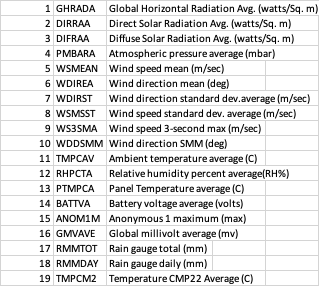

### FSEC_Regional_Test_BaseLine_data columns

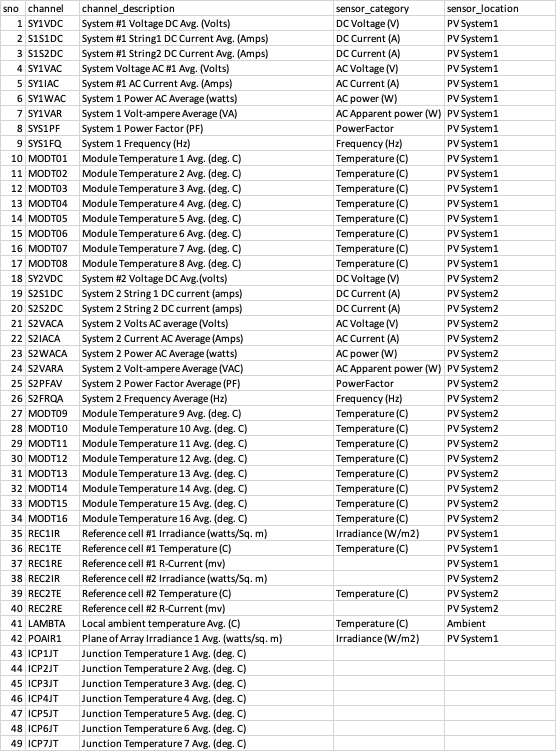

## Análisis EDA

In [ ]:
result.info()
result.columns

<class 'pandas.core.frame.DataFrame'>
Index: 3155040 entries, 2103839 to 5258878
Data columns (total 70 columns):
 #   Column  Dtype  
---  ------  -----  
 0   DAY     int64  
 1   HOUR    object 
 2   SY1VDC  float64
 3   S1S1DC  float64
 4   S1S2DC  float64
 5   SY1VAC  float64
 6   SY1IAC  float64
 7   SY1WAC  float64
 8   SY1VAR  float64
 9   SYS1PF  float64
 10  SYS1FQ  float64
 11  MODT01  float64
 12  MODT02  float64
 13  MODT03  float64
 14  MODT04  float64
 15  MODT05  float64
 16  MODT06  float64
 17  MODT07  float64
 18  MODT08  float64
 19  SY2VDC  float64
 20  S2S1DC  float64
 21  S2S2DC  float64
 22  S2VACA  float64
 23  S2IACA  float64
 24  S2WACA  float64
 25  S2VARA  float64
 26  S2PFAV  float64
 27  S2FRQA  float64
 28  MODT09  float64
 29  MODT10  float64
 30  MODT11  float64
 31  MODT12  float64
 32  MODT13  float64
 33  MODT14  float64
 34  MODT15  float64
 35  MODT16  float64
 36  REC1IR  float64
 37  REC1TE  float64
 38  REC1RE  float64
 39  REC2IR  float64
 40 

Index(['DAY', 'HOUR', 'SY1VDC', 'S1S1DC', 'S1S2DC', 'SY1VAC', 'SY1IAC',
       'SY1WAC', 'SY1VAR', 'SYS1PF', 'SYS1FQ', 'MODT01', 'MODT02', 'MODT03',
       'MODT04', 'MODT05', 'MODT06', 'MODT07', 'MODT08', 'SY2VDC', 'S2S1DC',
       'S2S2DC', 'S2VACA', 'S2IACA', 'S2WACA', 'S2VARA', 'S2PFAV', 'S2FRQA',
       'MODT09', 'MODT10', 'MODT11', 'MODT12', 'MODT13', 'MODT14', 'MODT15',
       'MODT16', 'REC1IR', 'REC1TE', 'REC1RE', 'REC2IR', 'REC2TE', 'REC2RE',
       'LAMBTA', 'POAIR1', 'ICP1JT', 'ICP2JT', 'ICP3JT', 'ICP4JT', 'ICP5JT',
       'ICP6JT', 'ICP7JT', 'GHRADA', 'DIRRAA', 'DIFRAA', 'PMBARA', 'WSMEAN',
       'WDIREA', 'WDIRST', 'WSMSST', 'WS3SMA', 'WDDSMM', 'TMPCAV', 'RHPCTA',
       'PTMPCA', 'BATTVA', 'ANOM1M', 'GMVAVE', 'RMMTOT', 'RMMDAY', 'TMPCM2'],
      dtype='object')

In [ ]:
missing_values_percentage = result.isnull().sum() / len(result) * 100
display(missing_values_percentage[missing_values_percentage > 0].sort_values(ascending=False))

,0


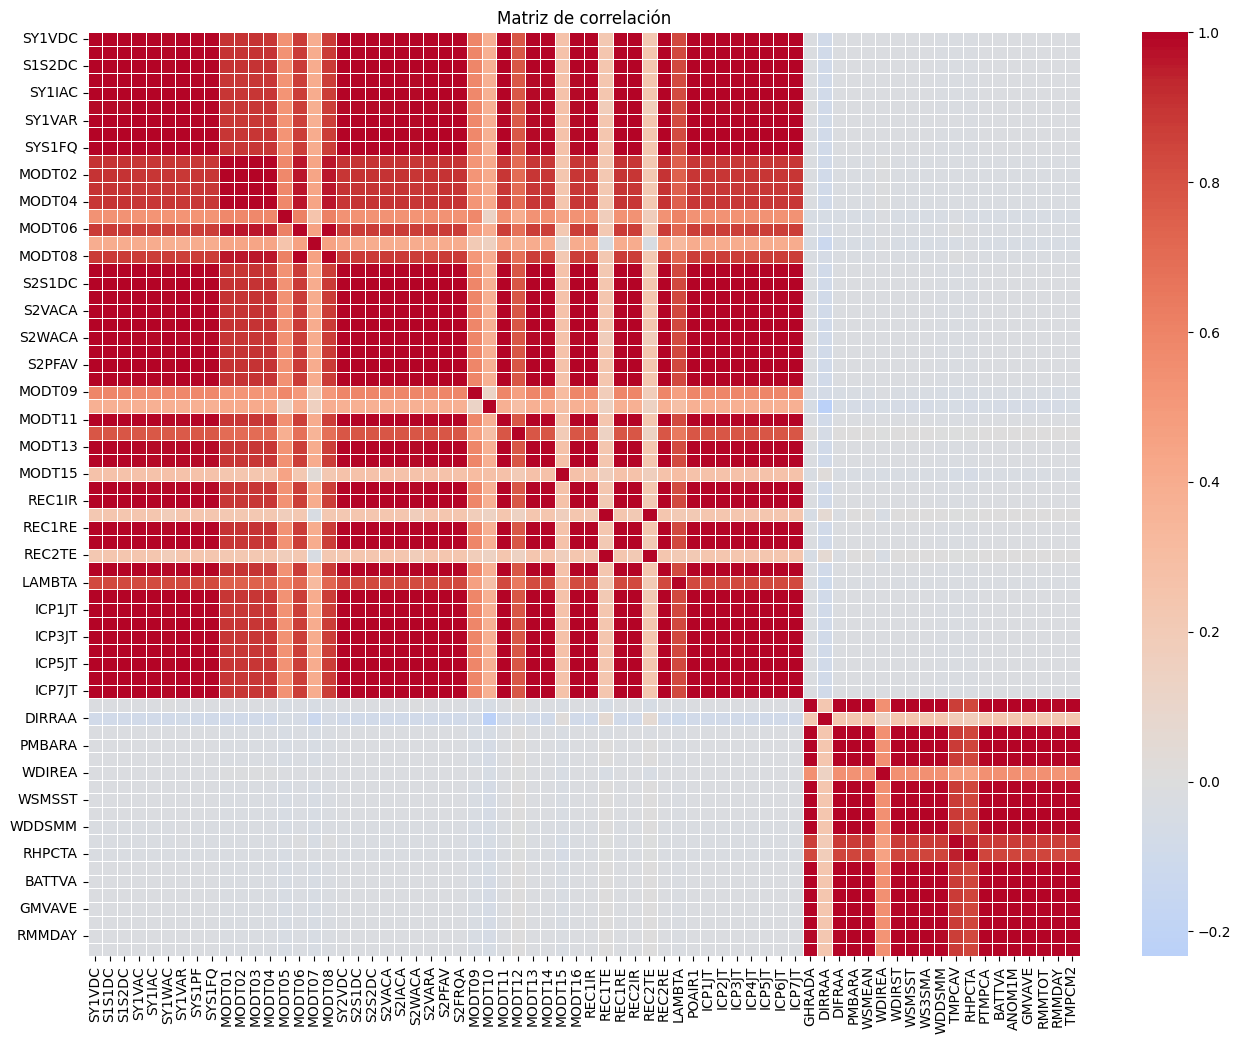

In [ ]:
df_num = result.select_dtypes(include="number").drop(['DAY'], axis=1)
corr_matrix = df_num.corr()

# Mostrar matriz
plt.figure(figsize=(16, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.show()

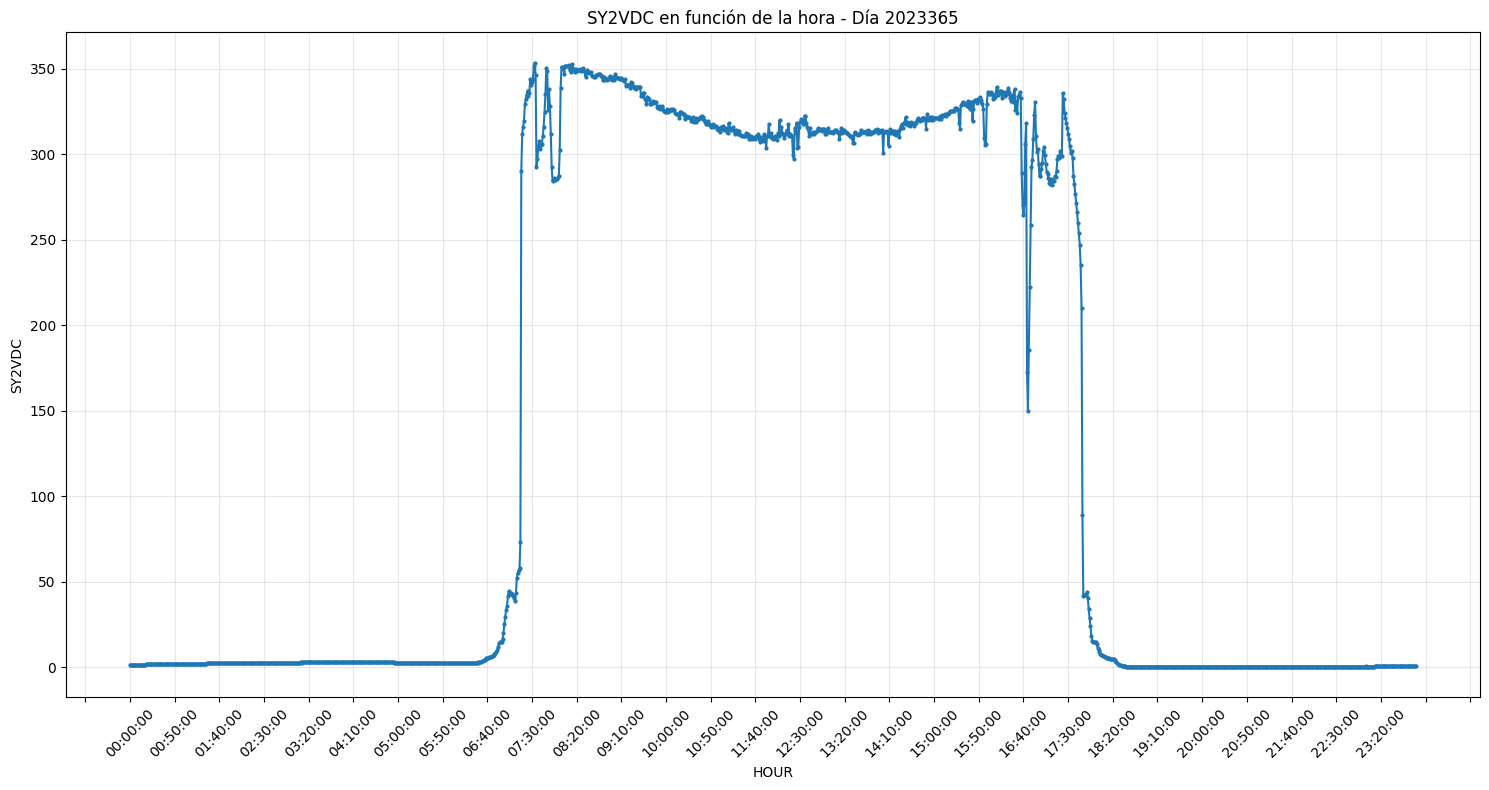

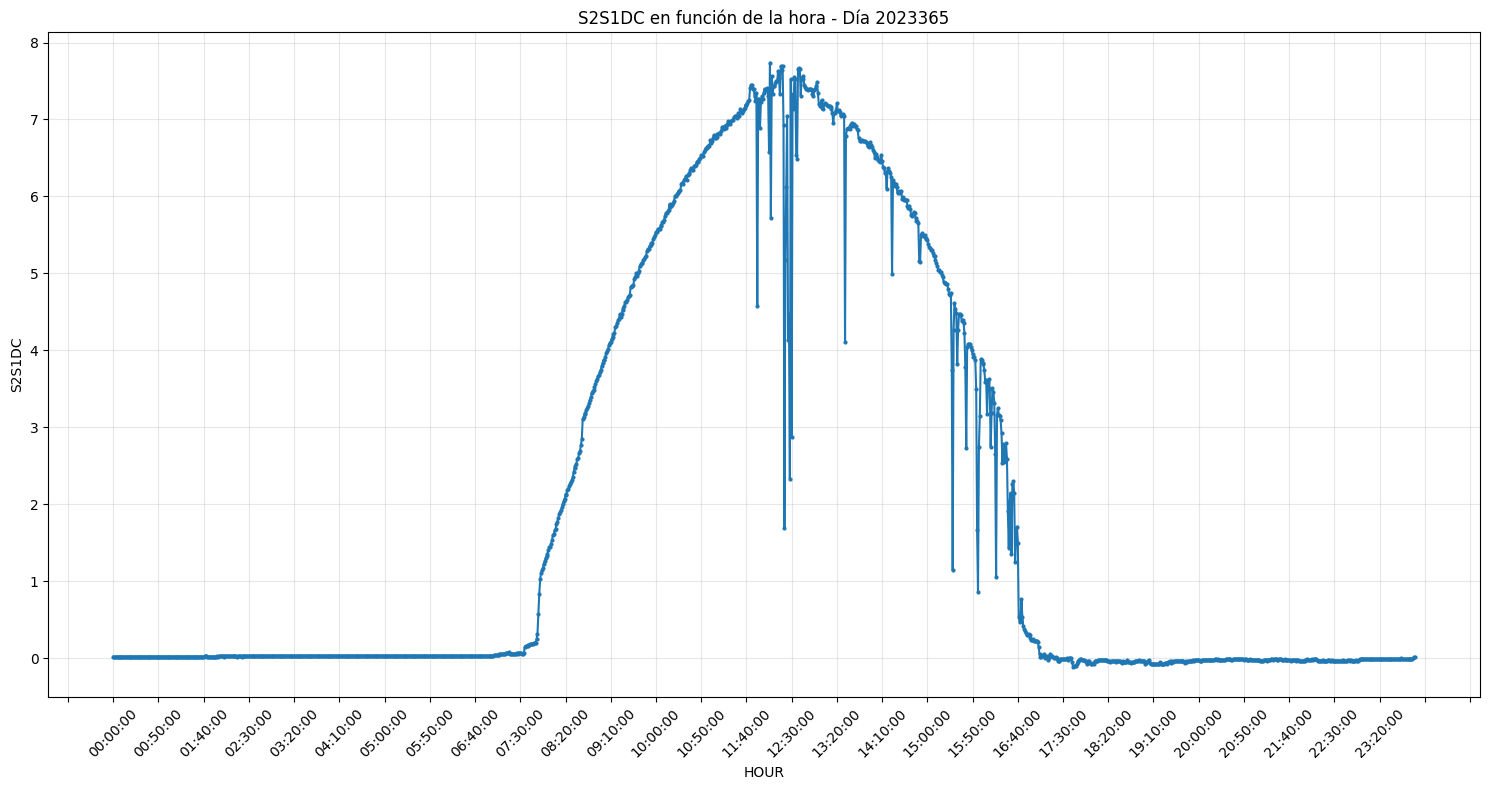

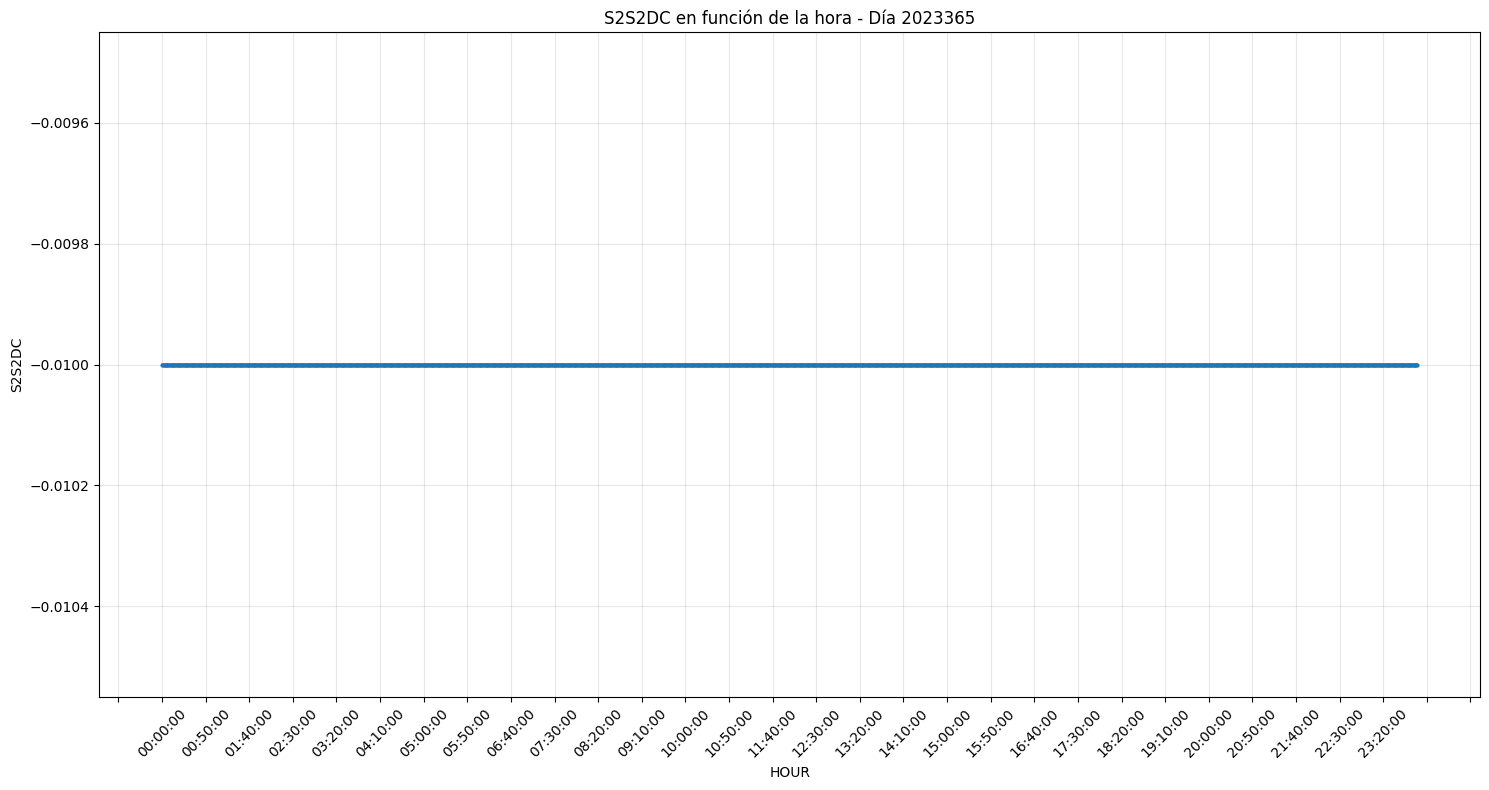

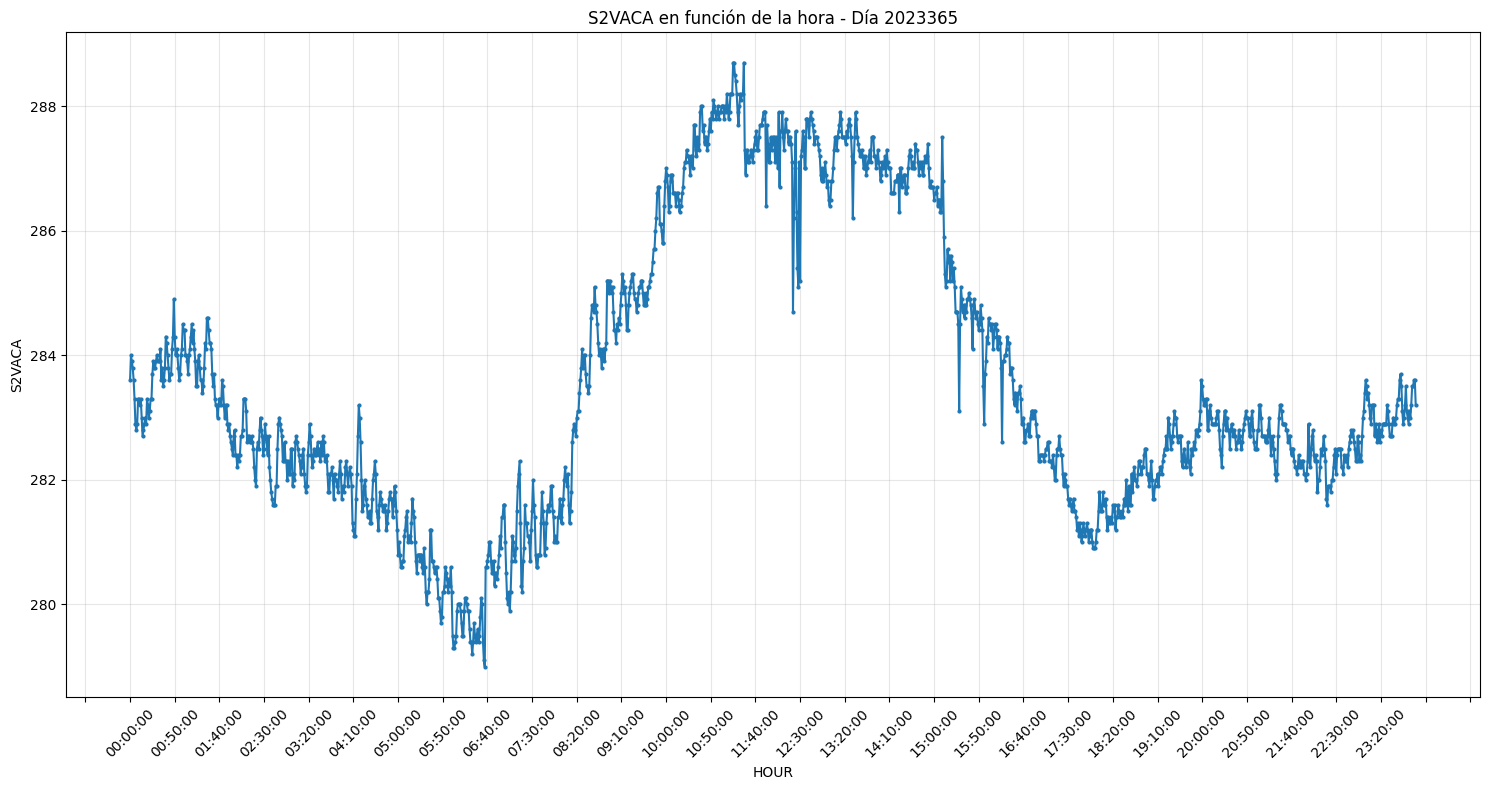

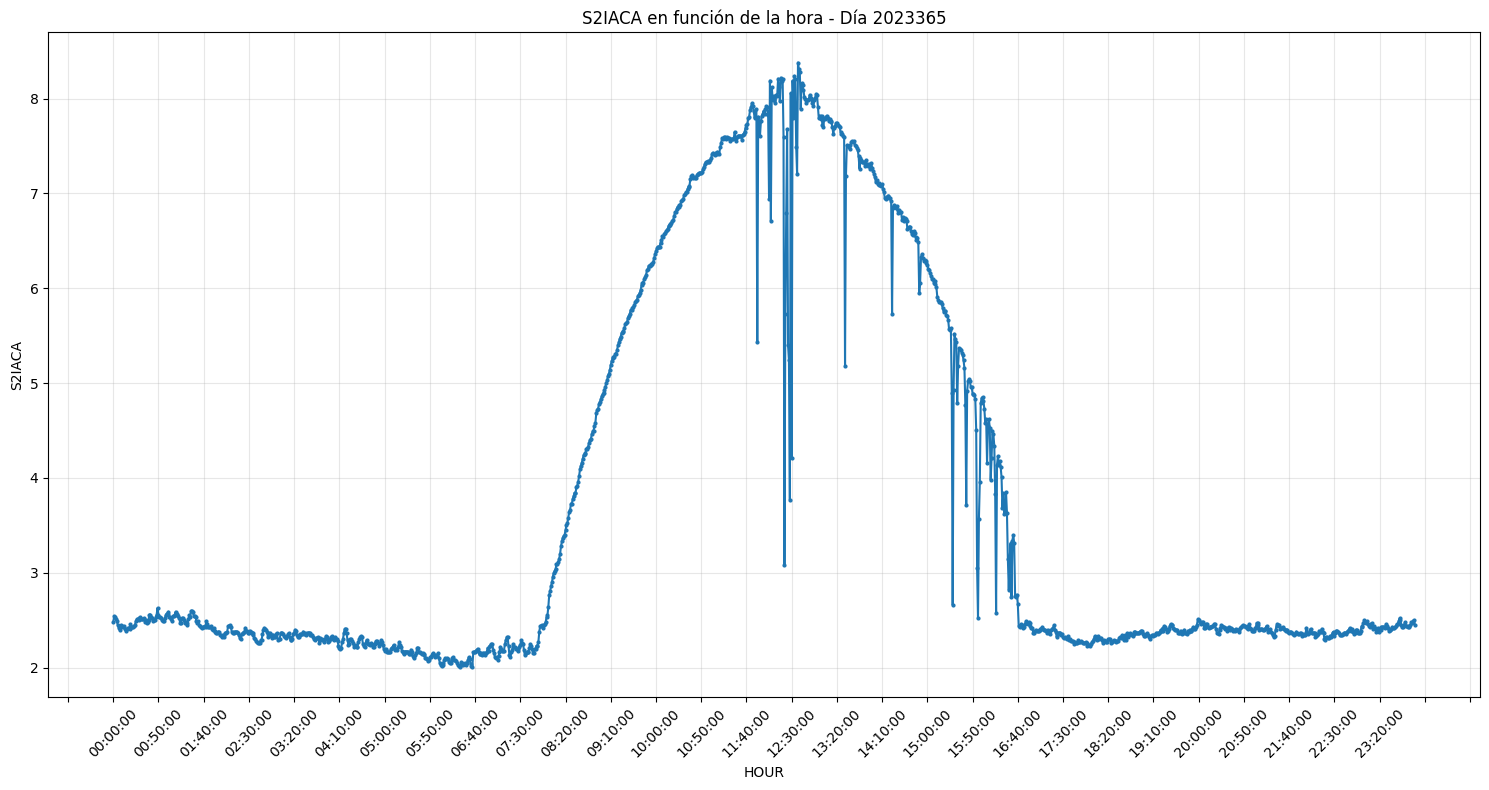

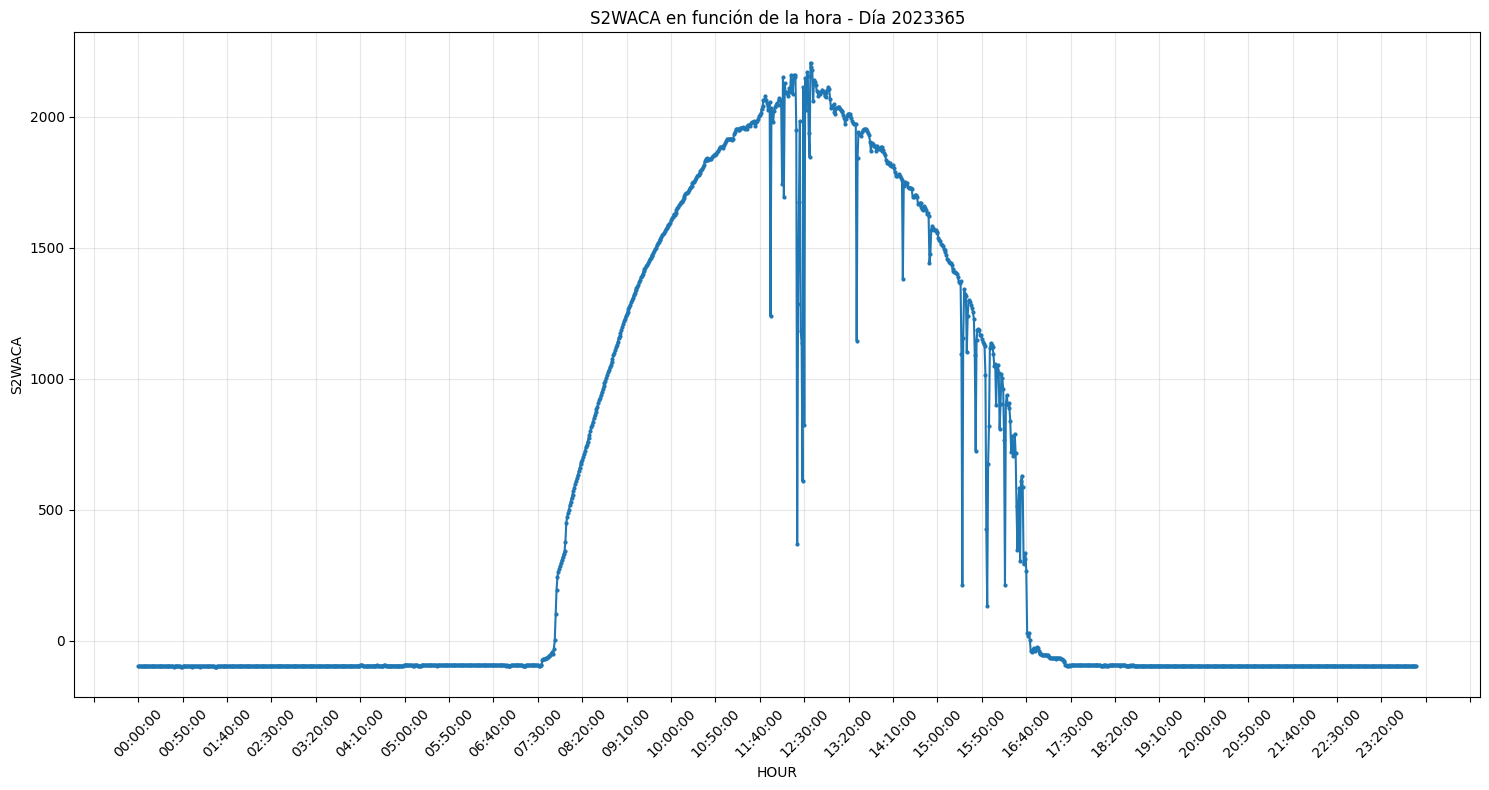

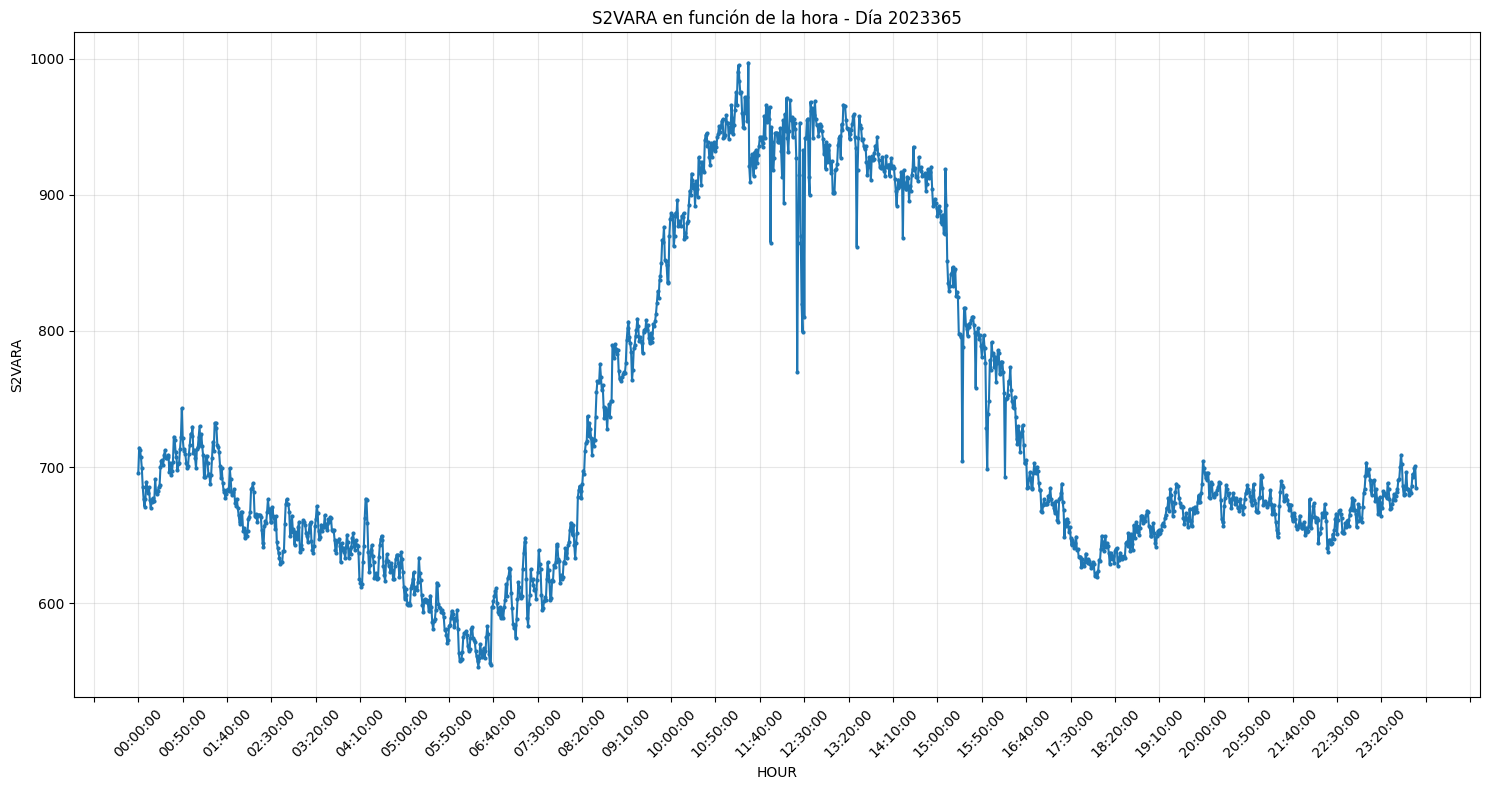

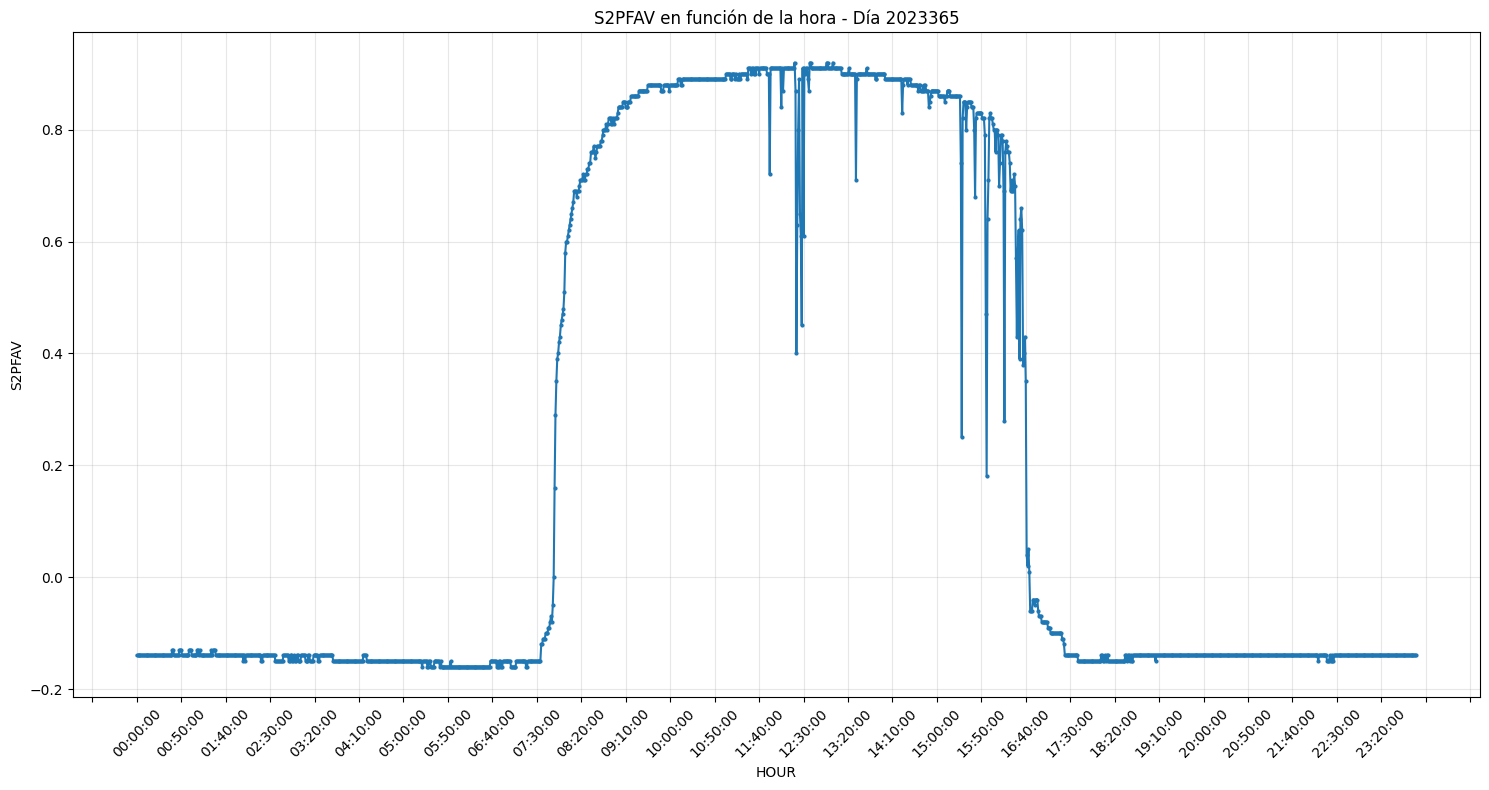

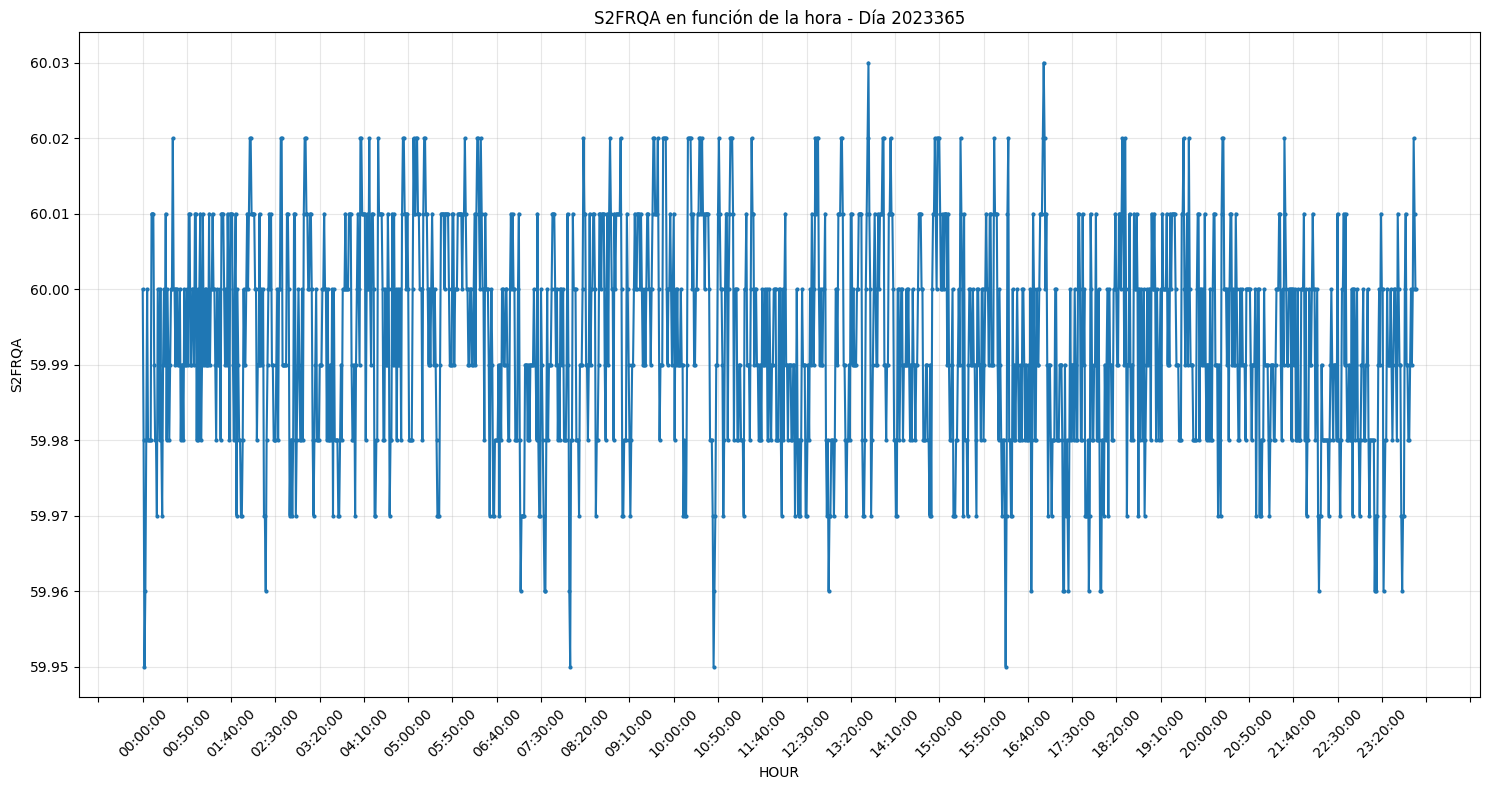

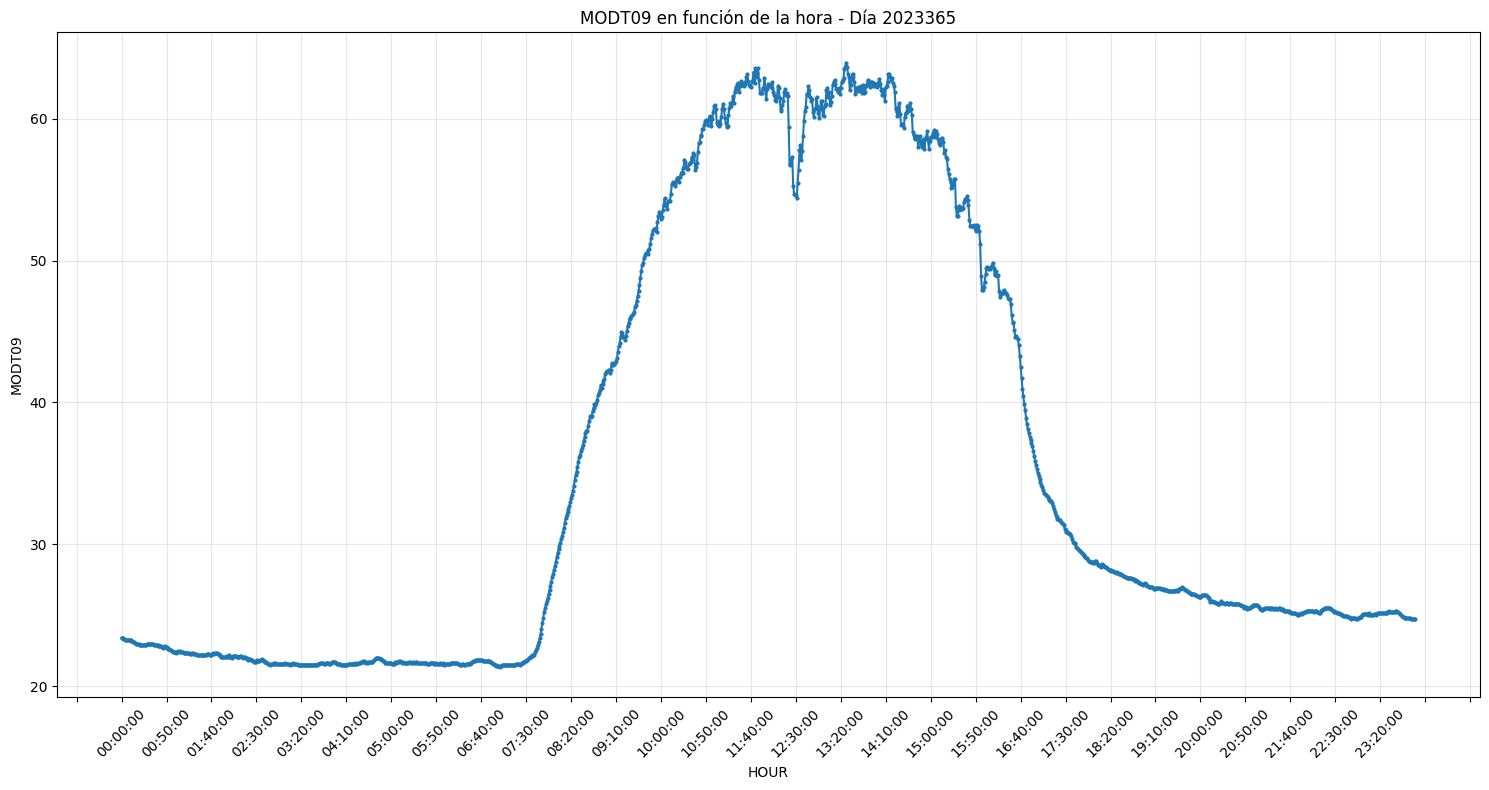

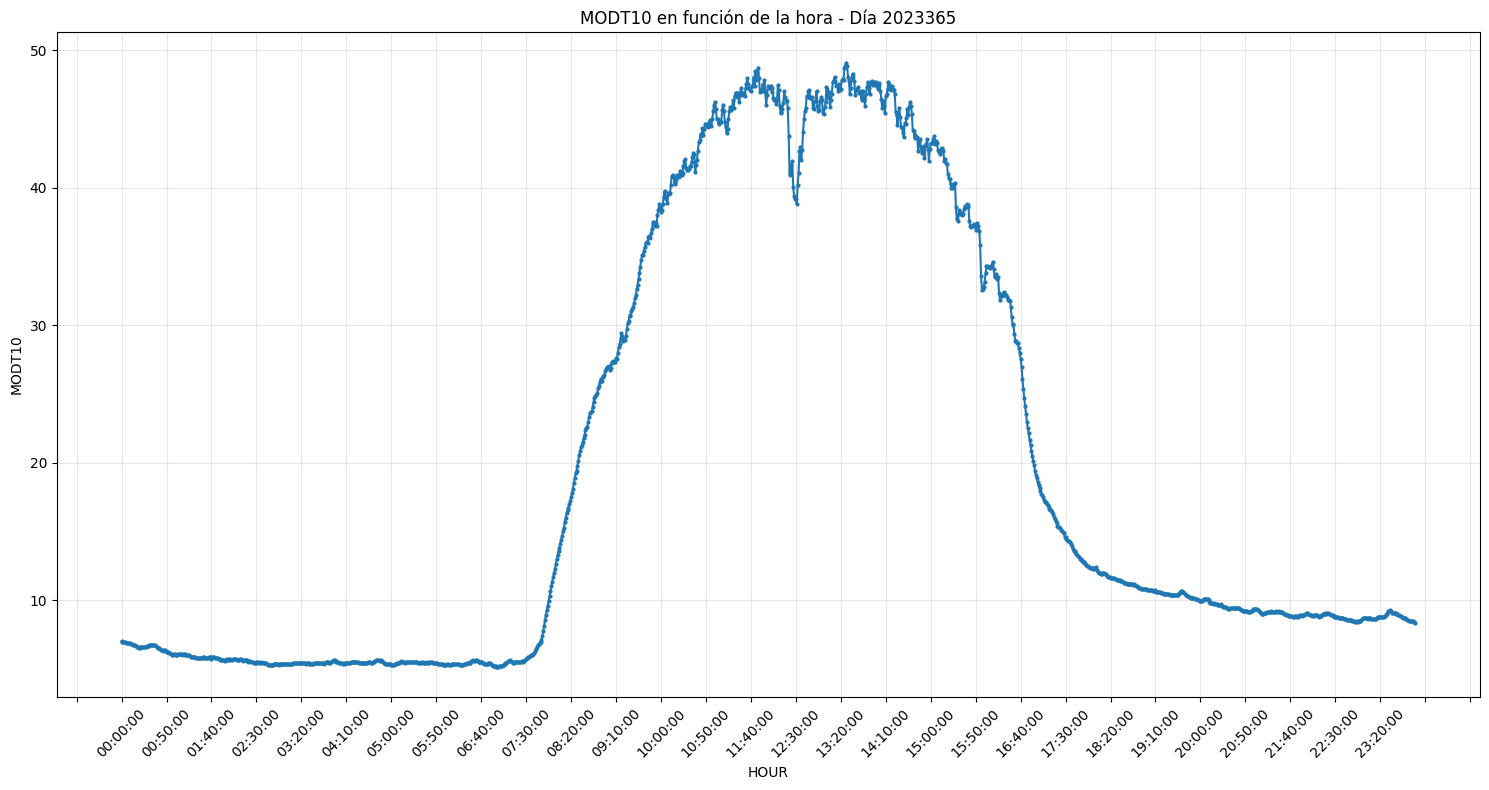

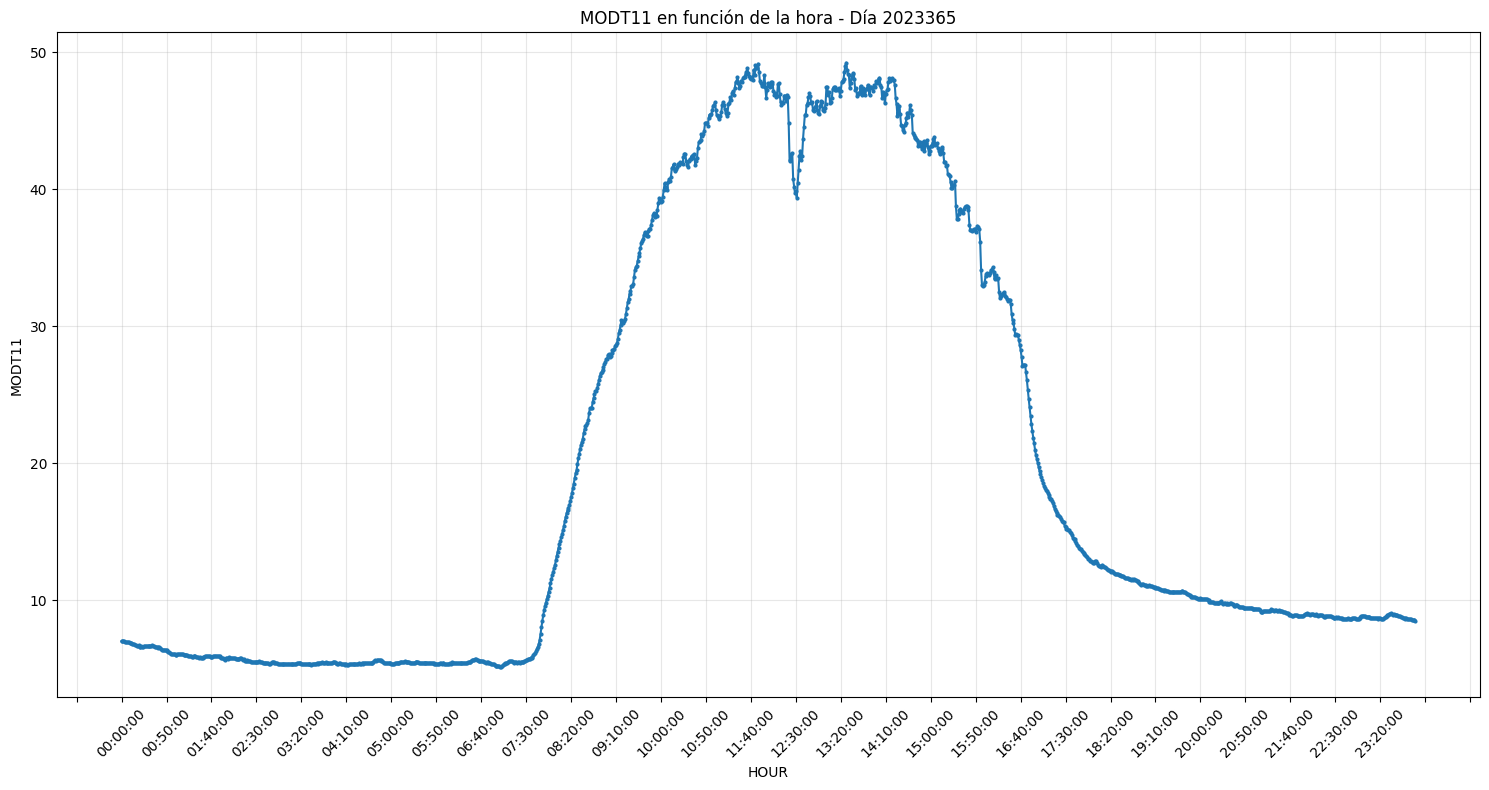

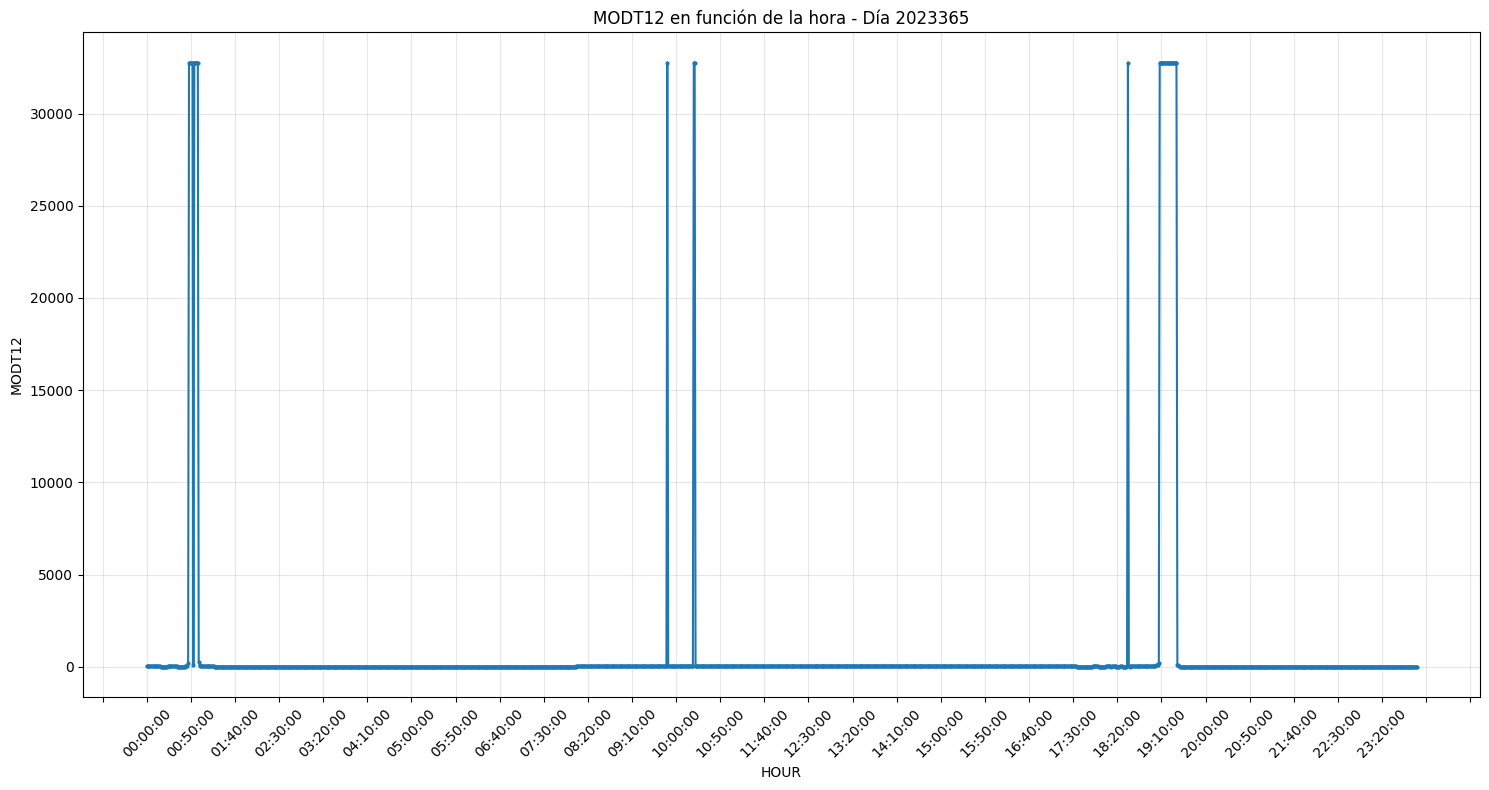

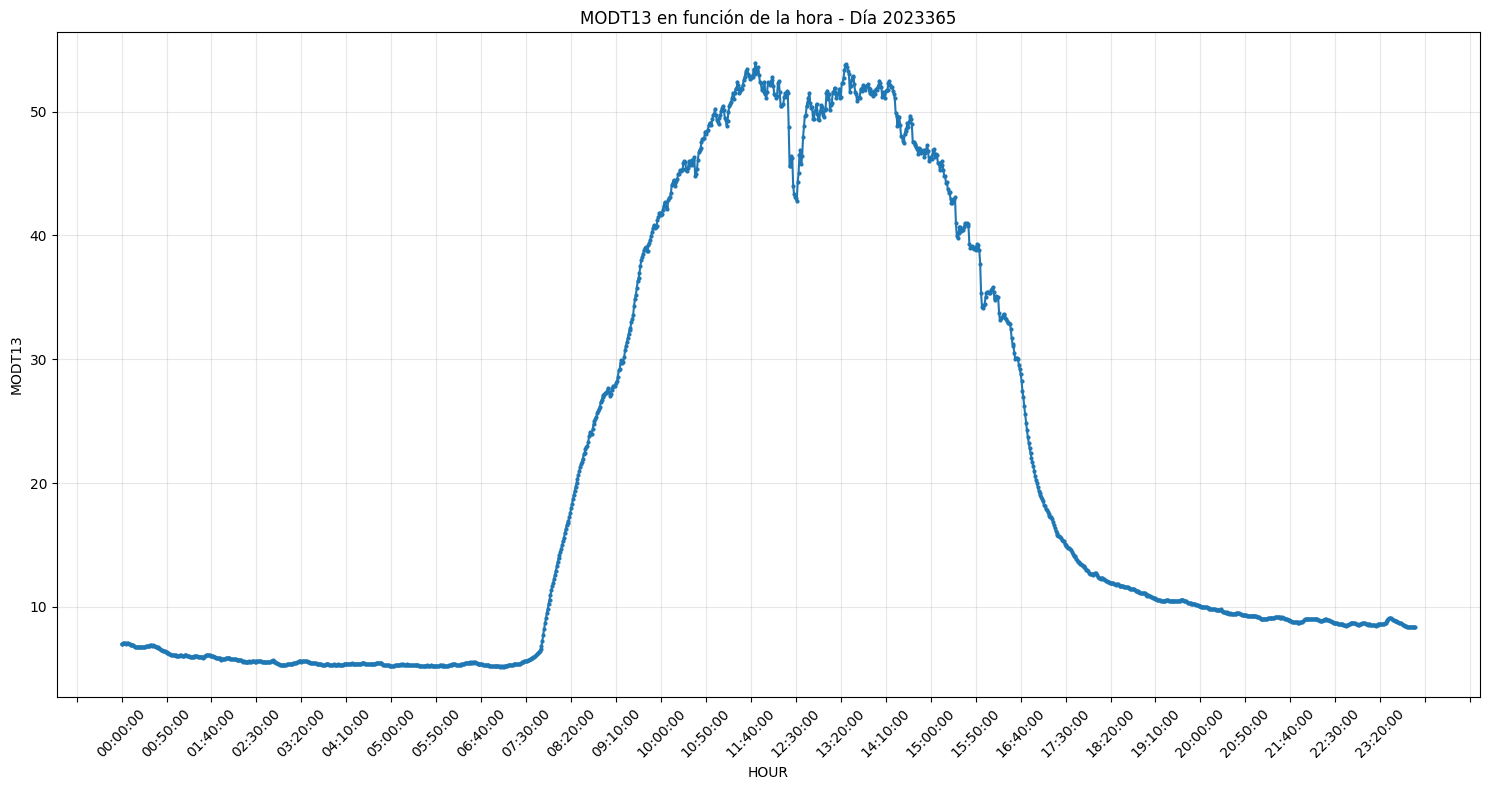

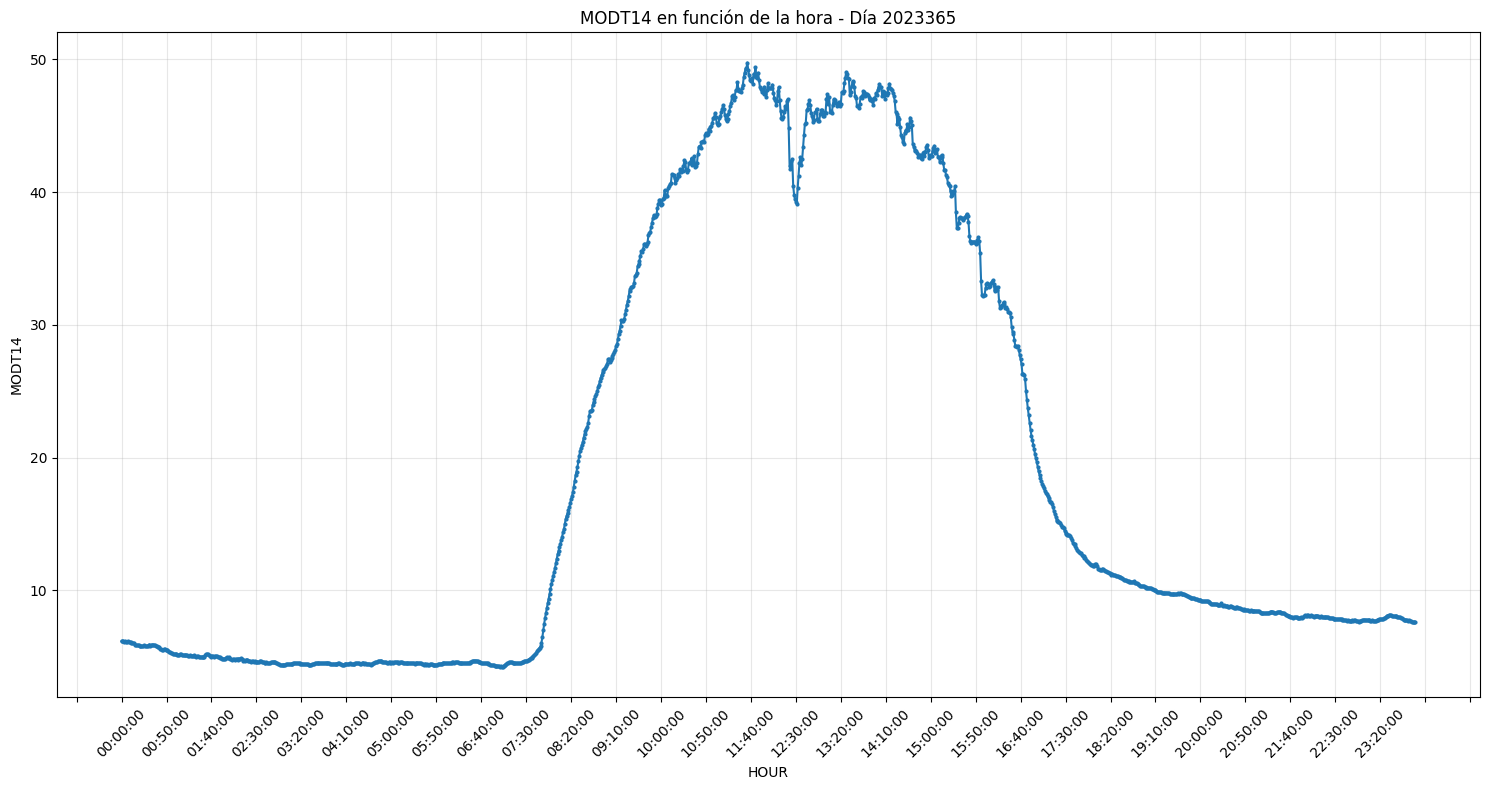

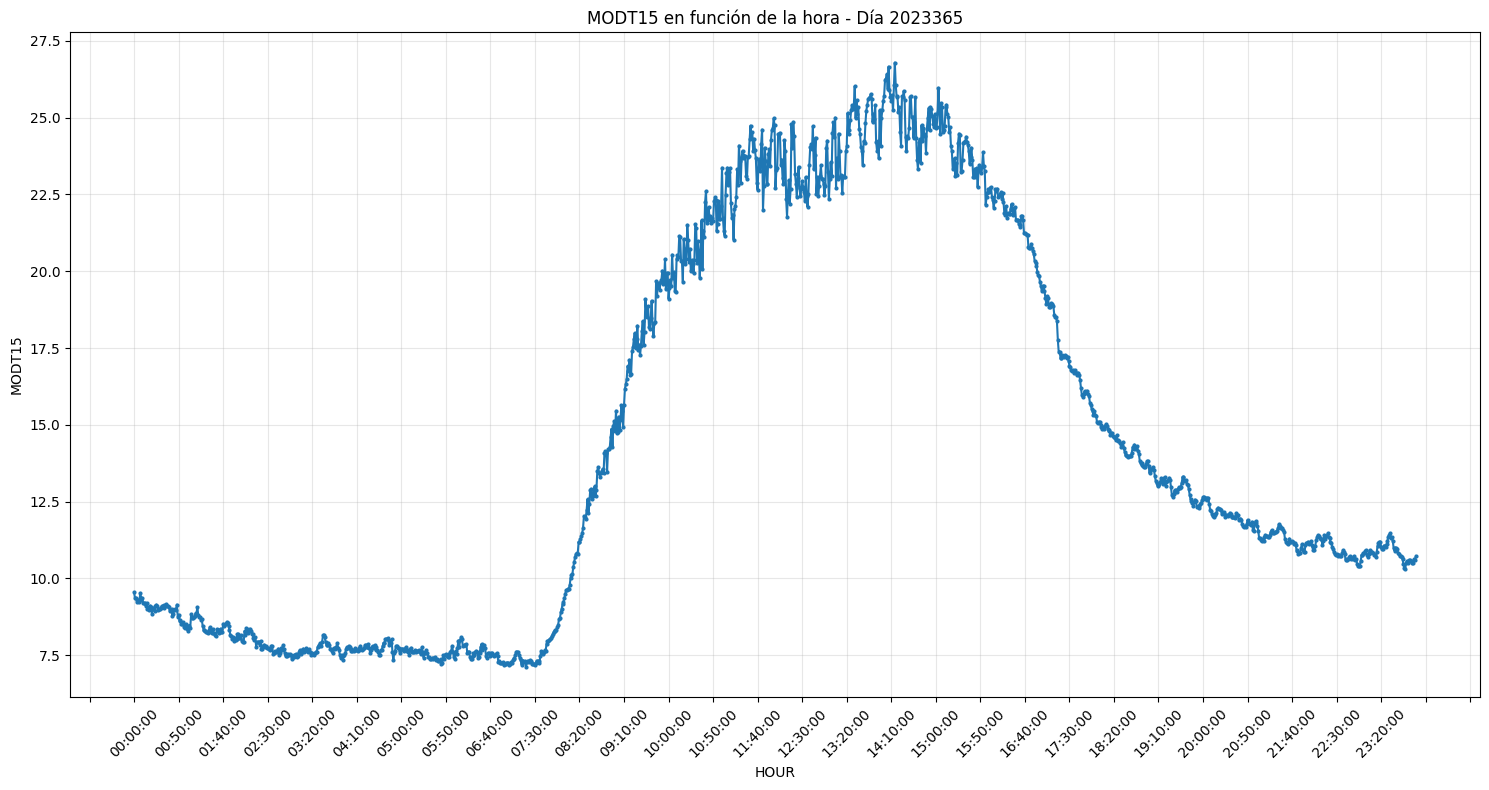

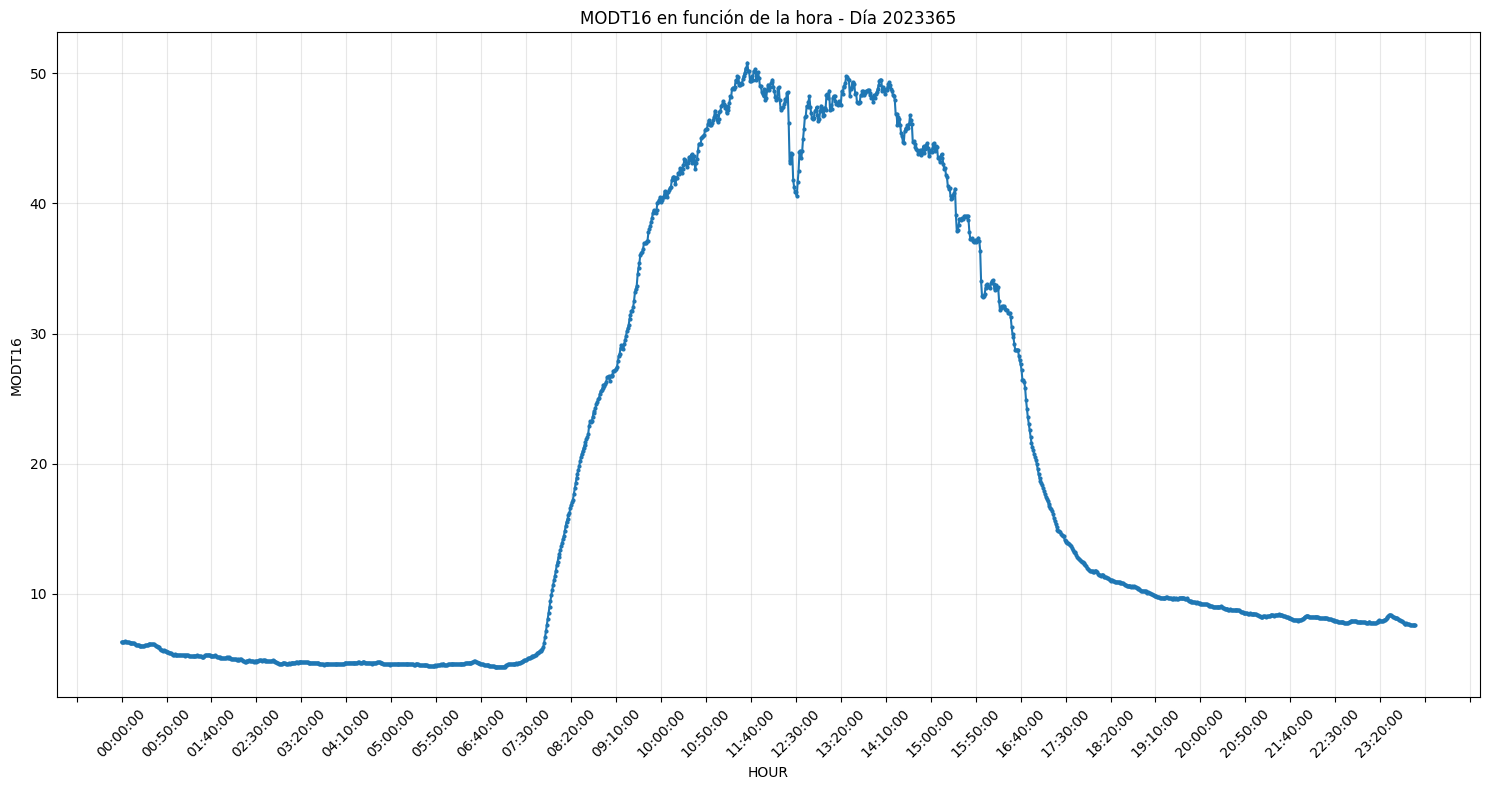

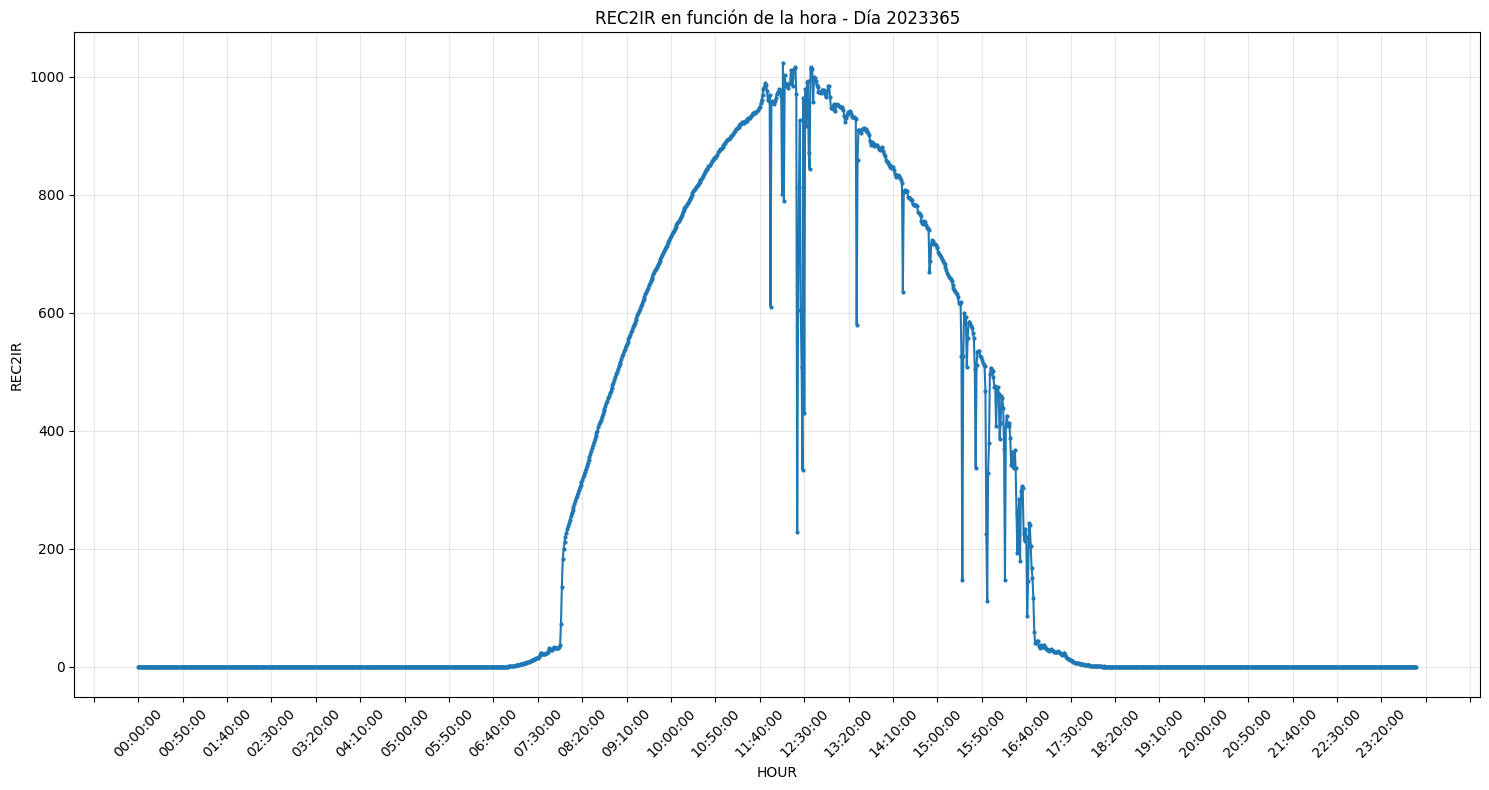

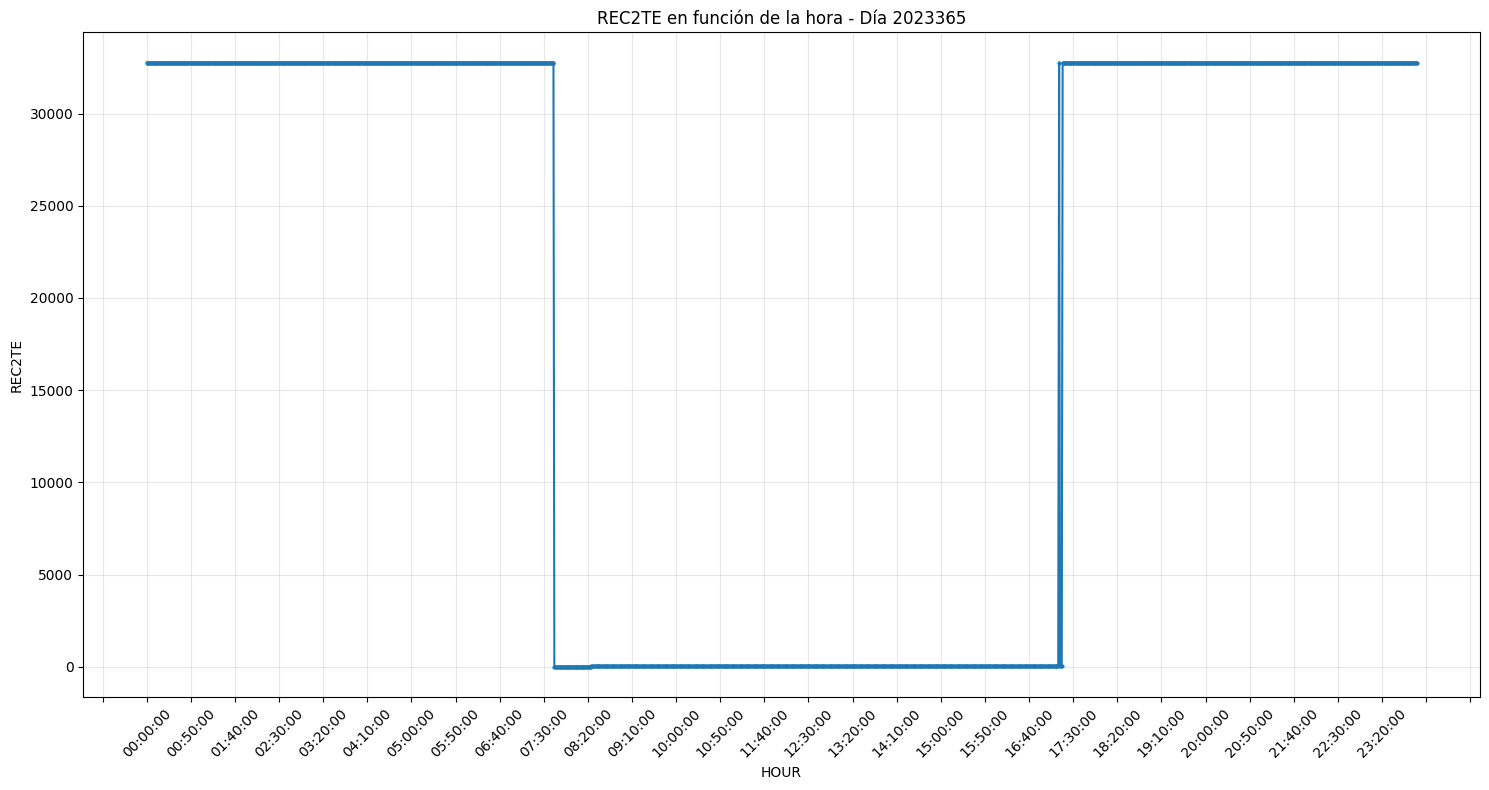

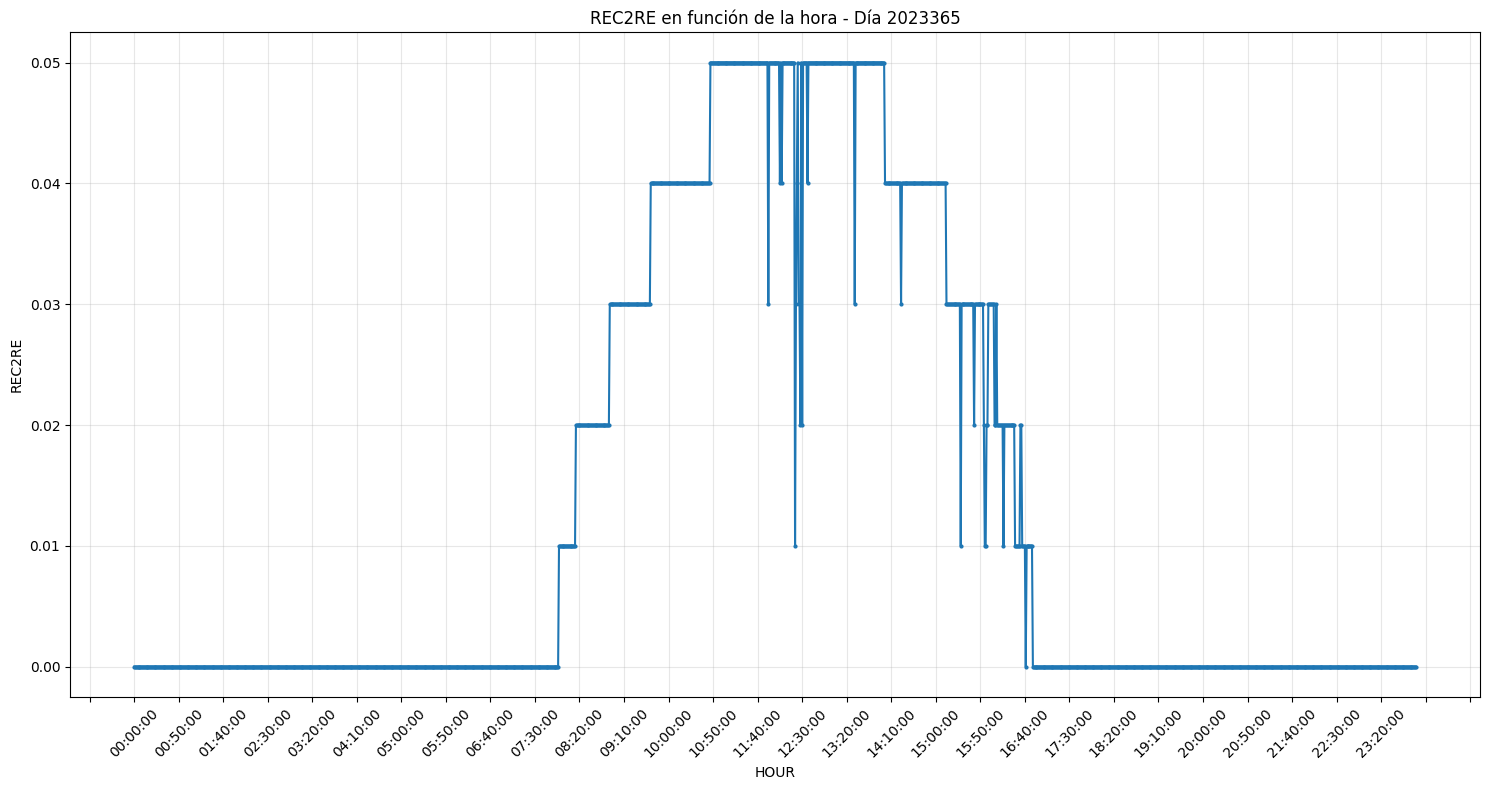

In [ ]:
#Visualizar gráficas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

campos = [
    'SY2VDC',
    'S2S1DC',
    'S2S2DC',
    'S2VACA',
    'S2IACA',
    'S2WACA',
    'S2VARA',
    'S2PFAV',
    'S2FRQA',
    'MODT09',
    'MODT10',
    'MODT11',
    'MODT12',
    'MODT13',
    'MODT14',
    'MODT15',
    'MODT16',
    'REC2IR',
    'REC2TE',
    'REC2RE'
]

day_value = 2023365

# Filtrar el día una sola vez
df_day = result[result['DAY'] == day_value][['DAY', 'HOUR'] + campos].copy()

# Ordenar por hora para que las líneas se unan correctamente
df_day = df_day.sort_values('HOUR')

# Generar una gráfica por cada campo
for campo in campos:

    plt.figure(figsize=(15, 8))

    plt.plot(
        df_day['HOUR'],
        df_day[campo],
        marker='o',
        linestyle='-',
        markersize=2
    )

    plt.xlabel('HOUR')
    plt.ylabel(campo)
    plt.title(f'{campo} en función de la hora - Día {day_value}')

    # Mostrar menos etiquetas en el eje X para que sea legible
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=36))

    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

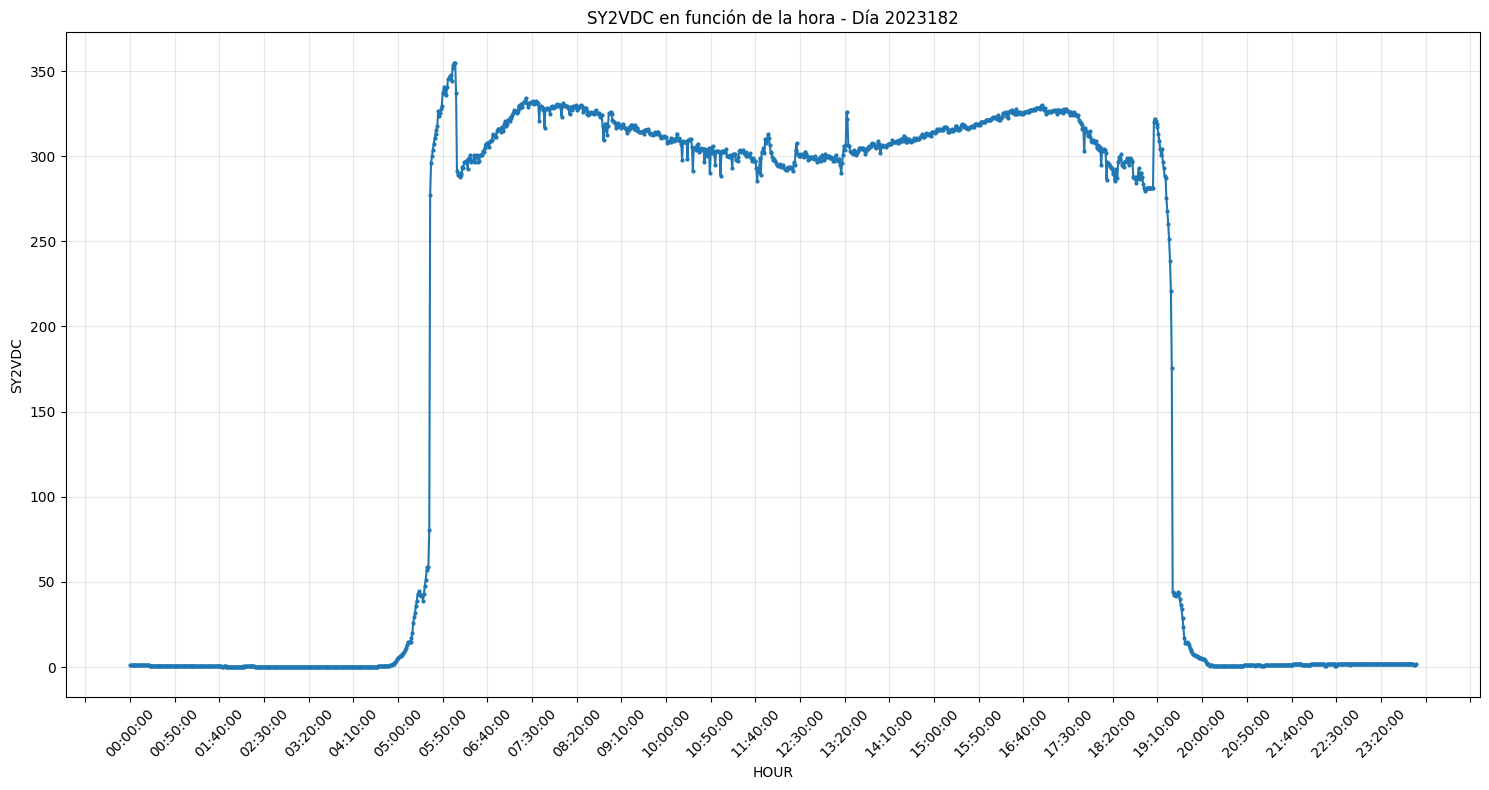

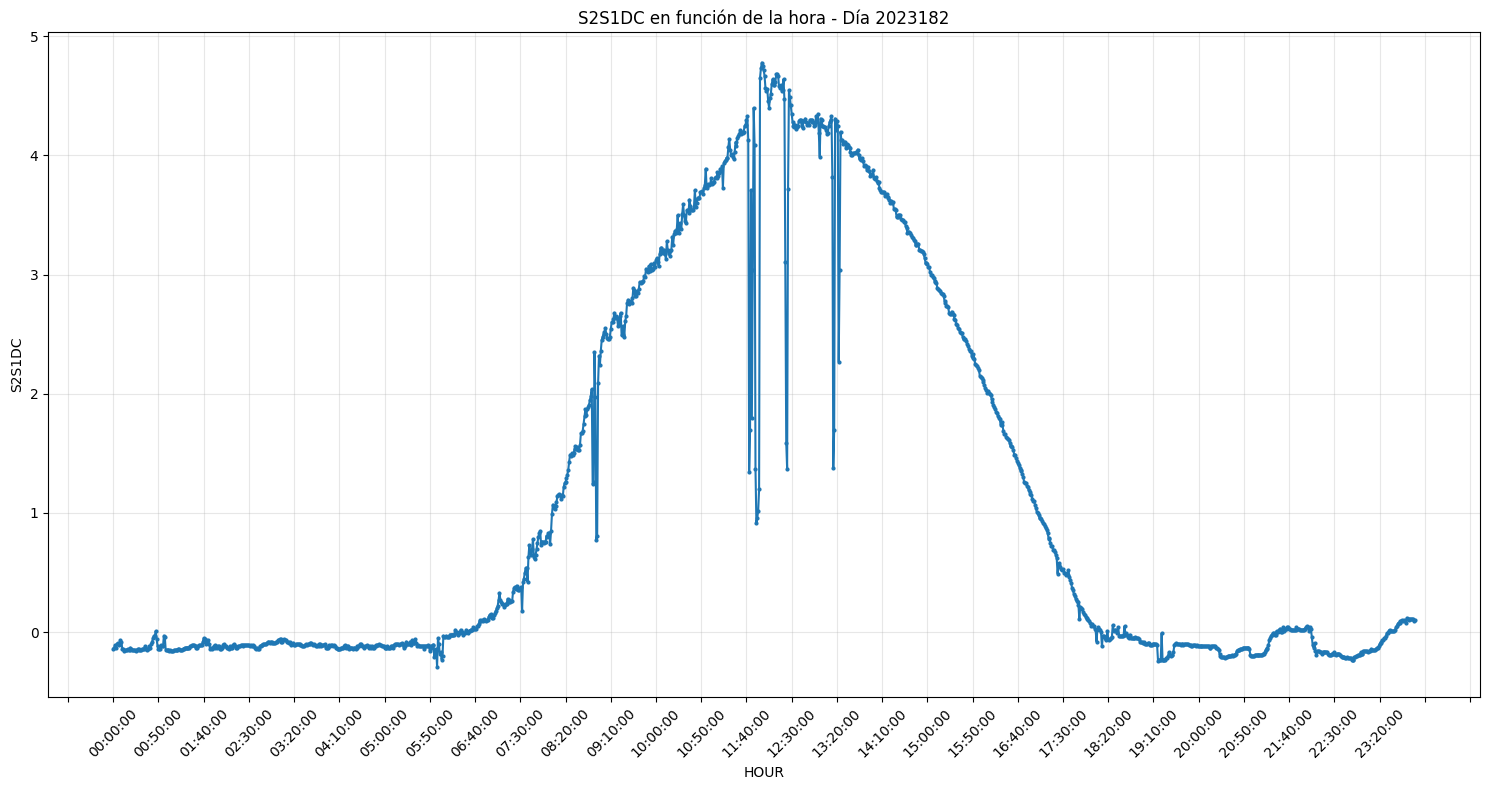

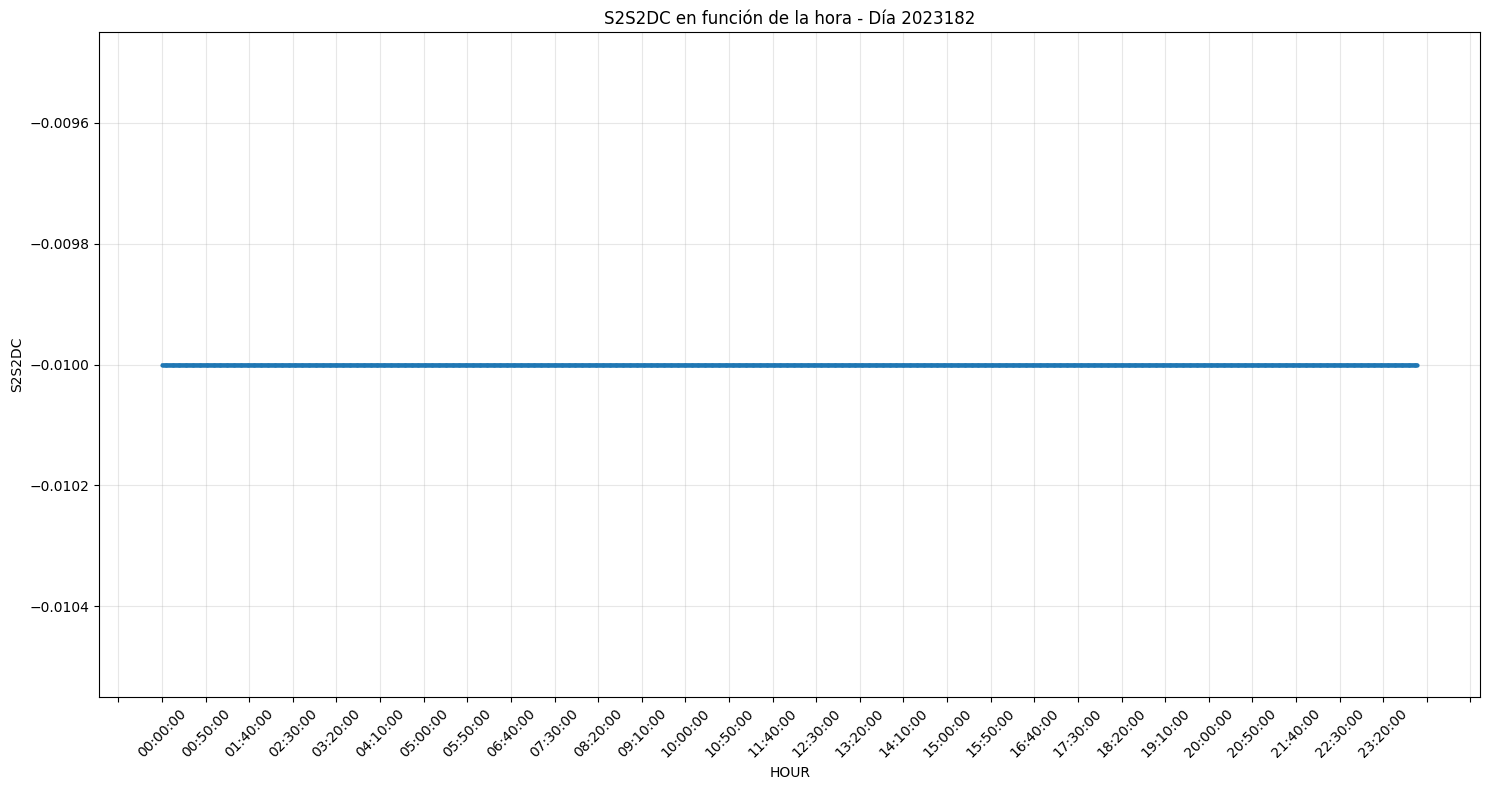

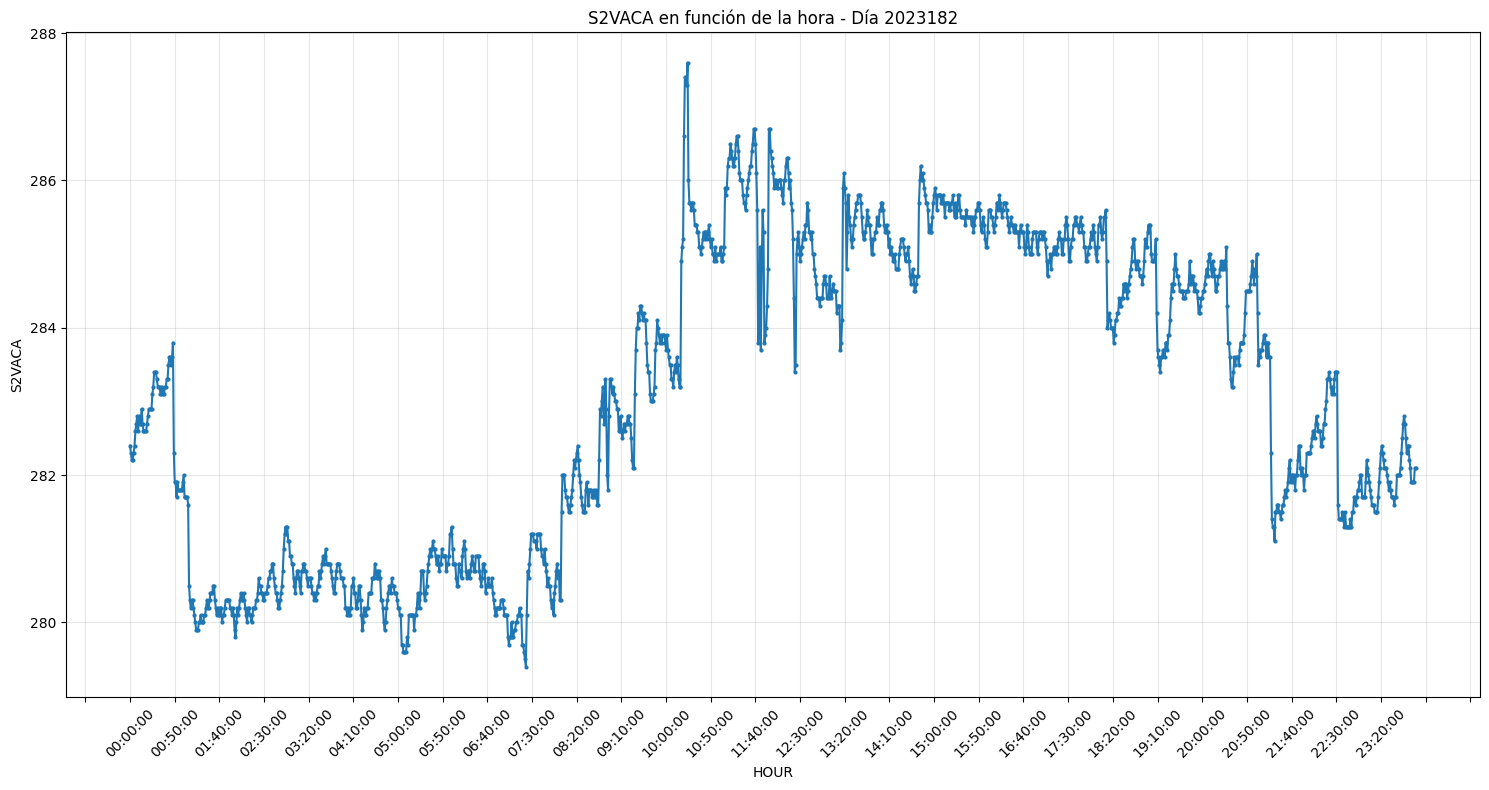

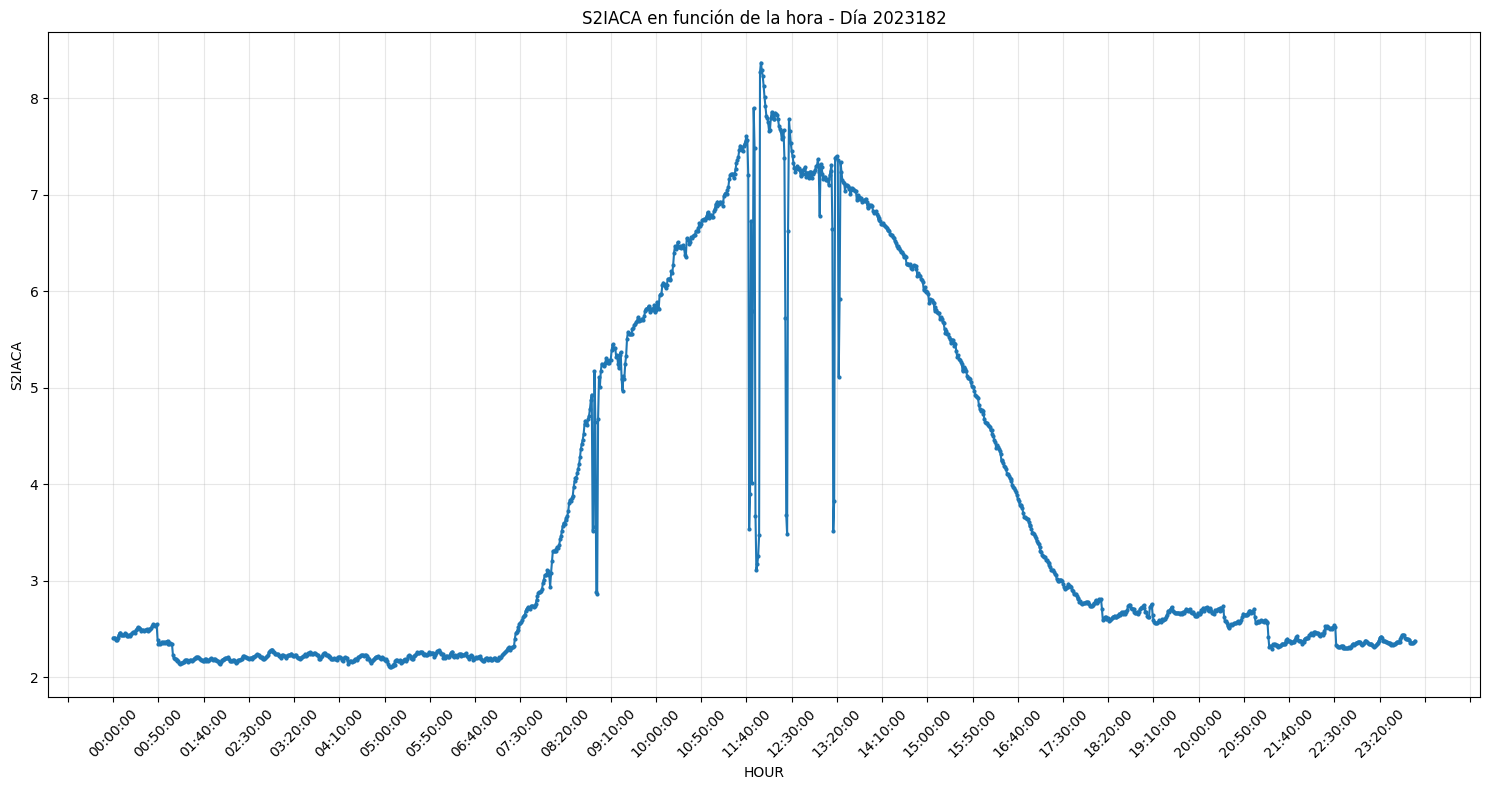

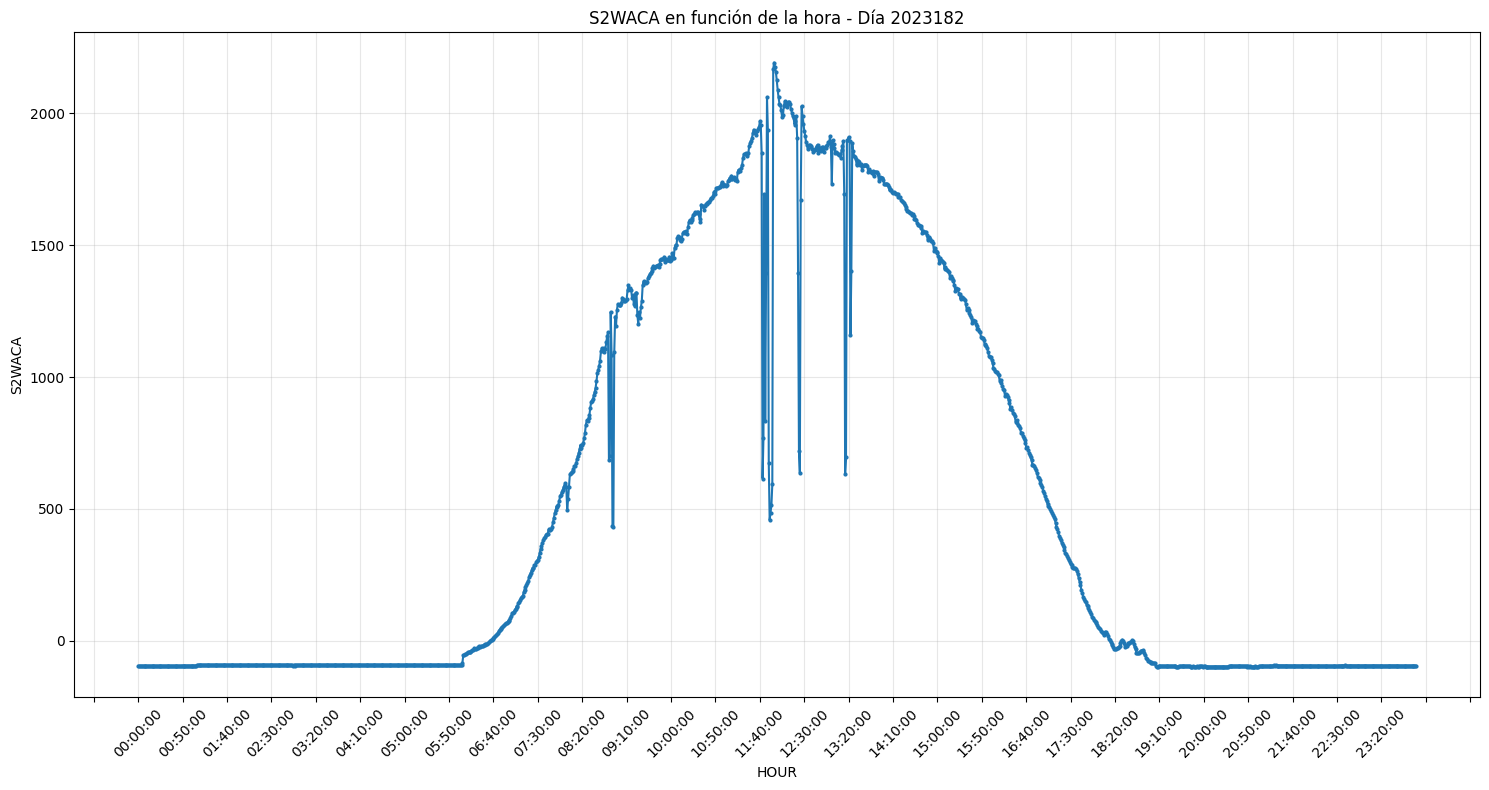

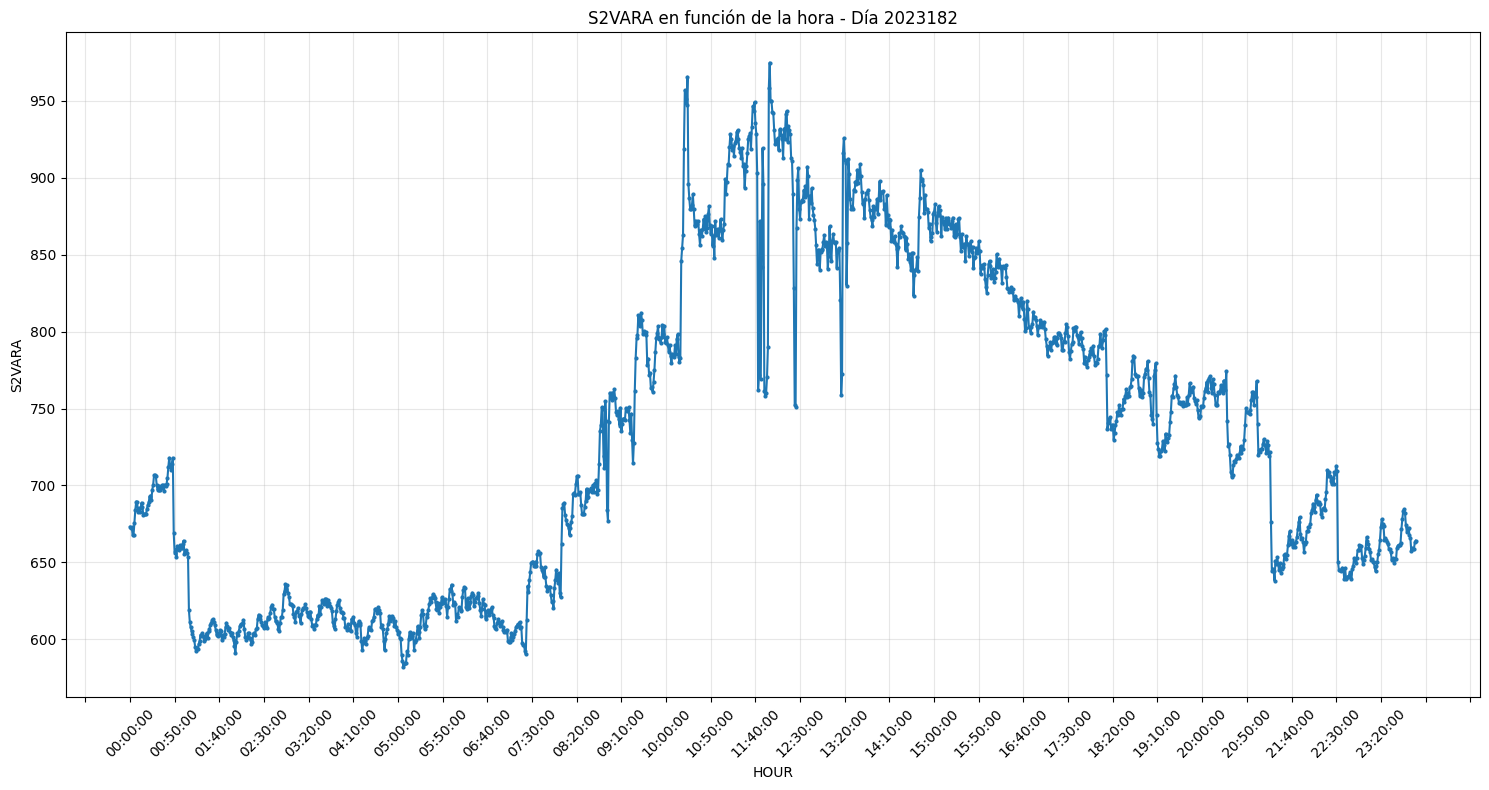

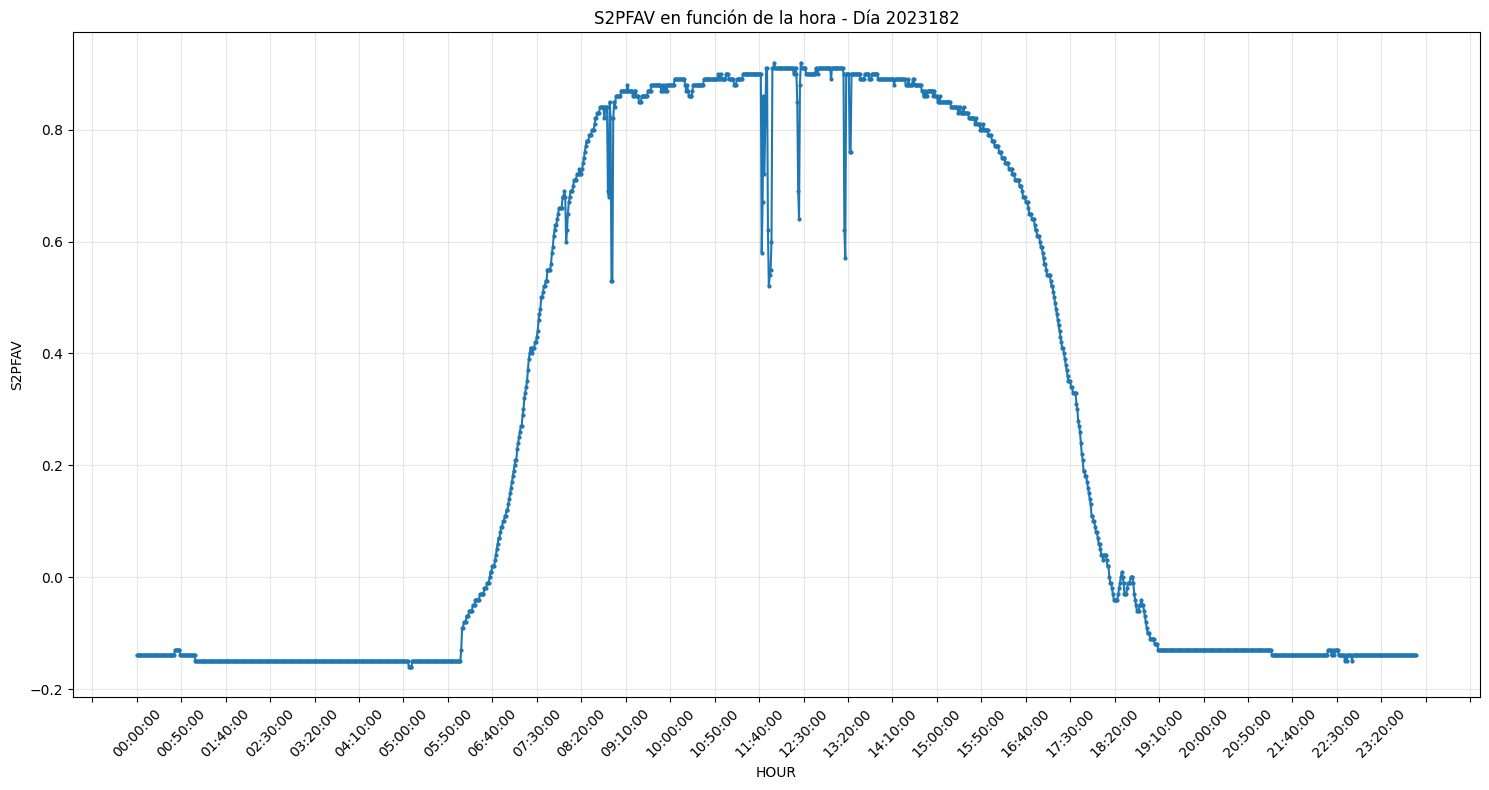

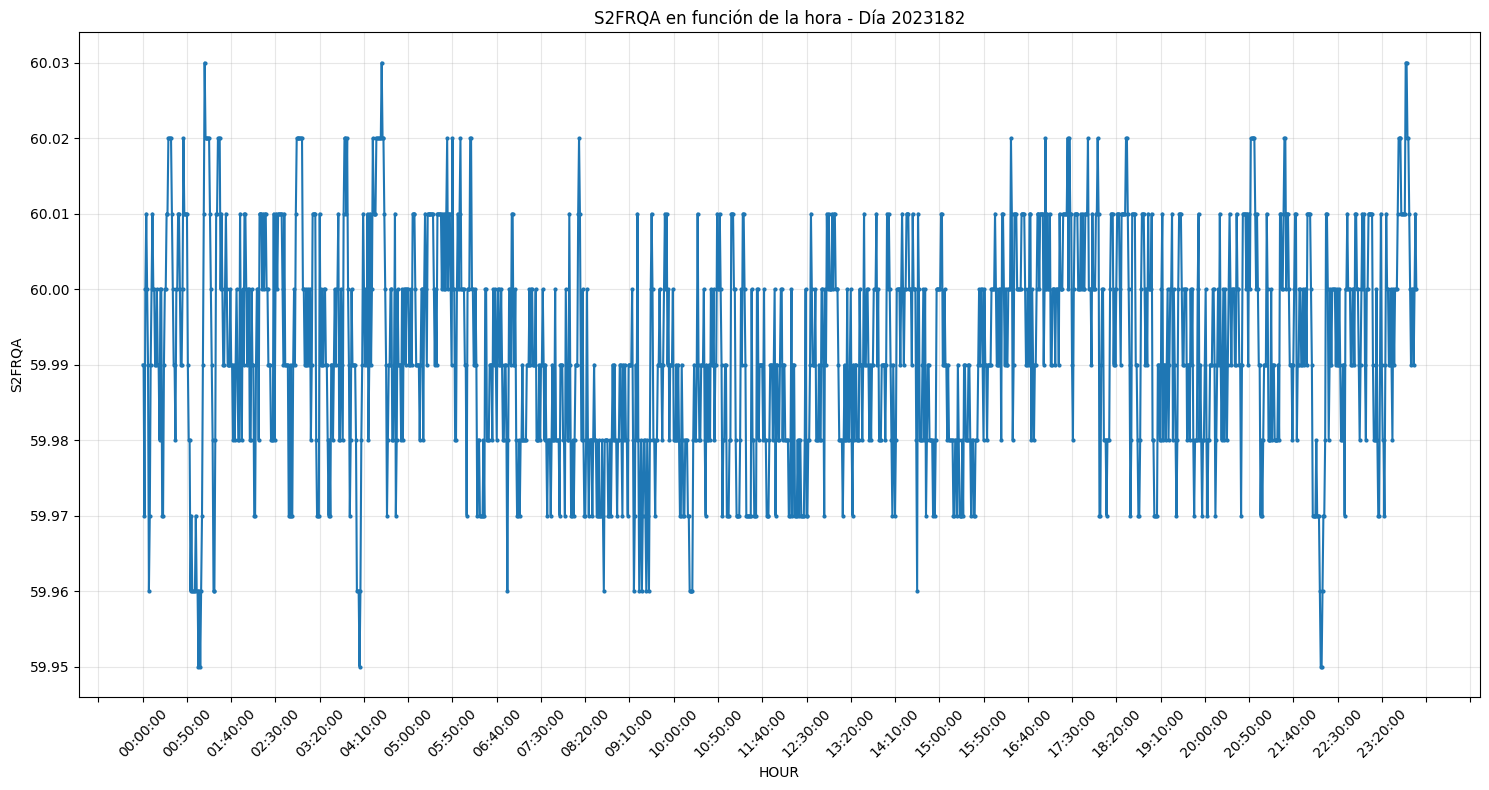

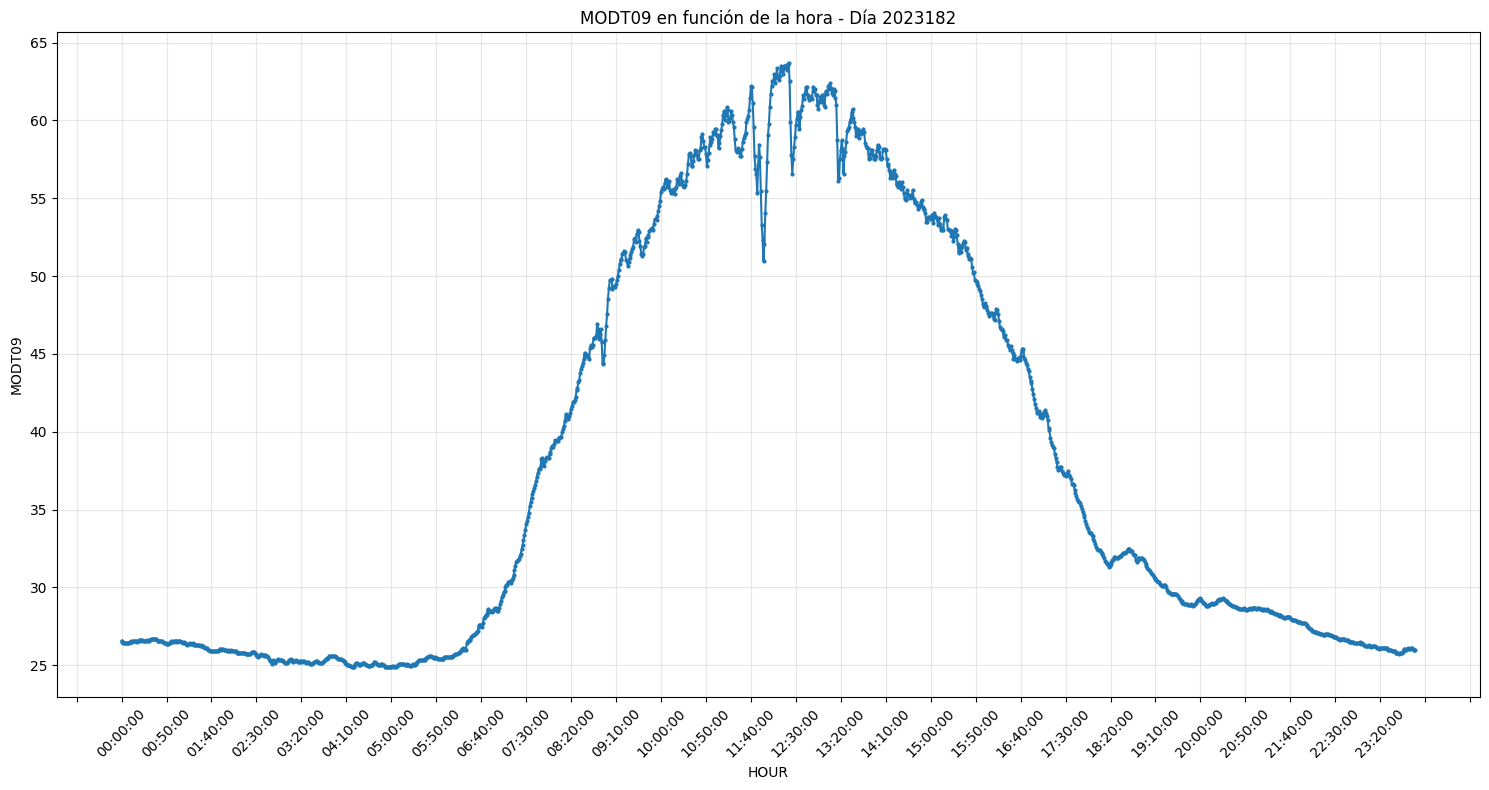

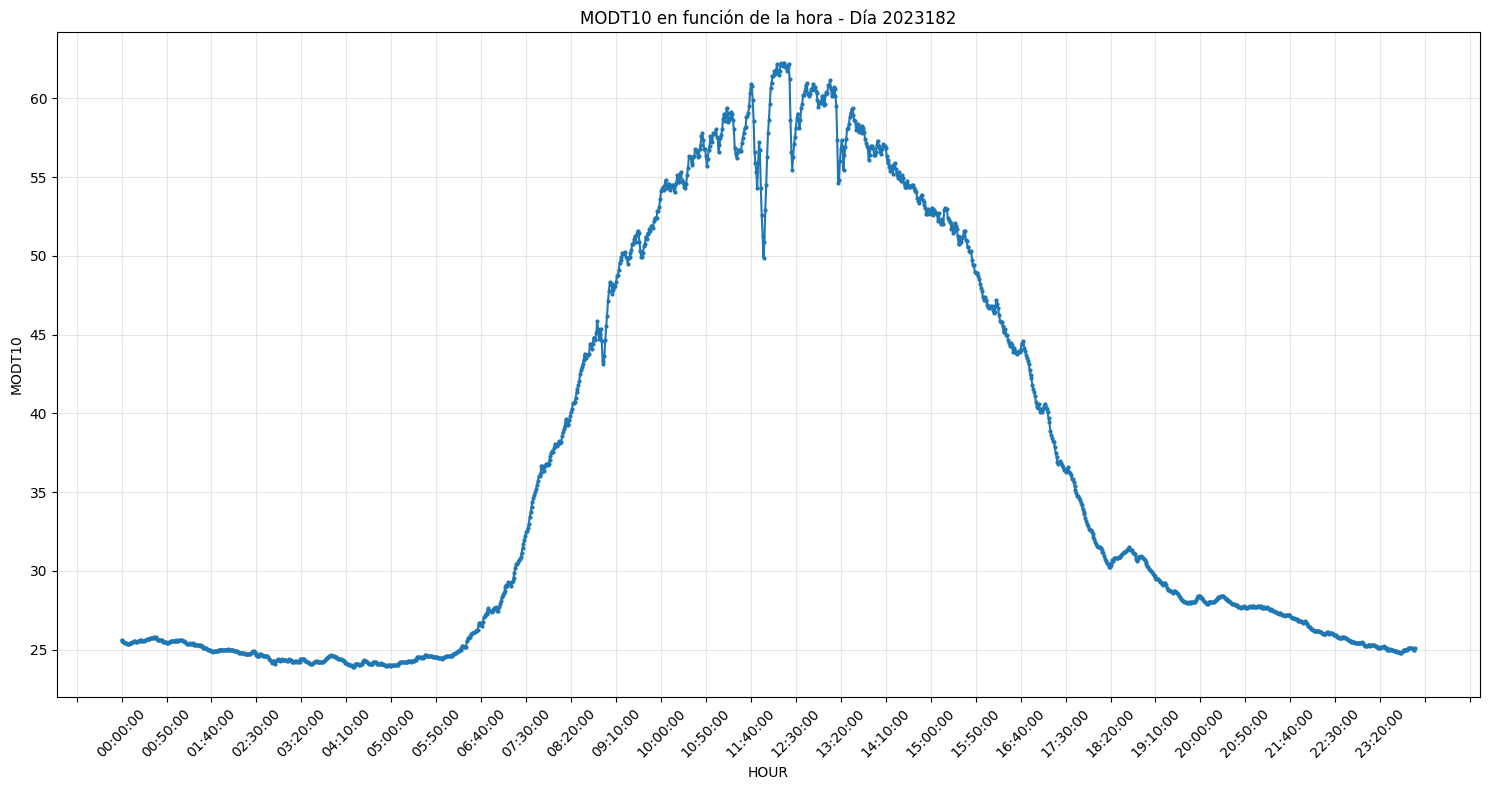

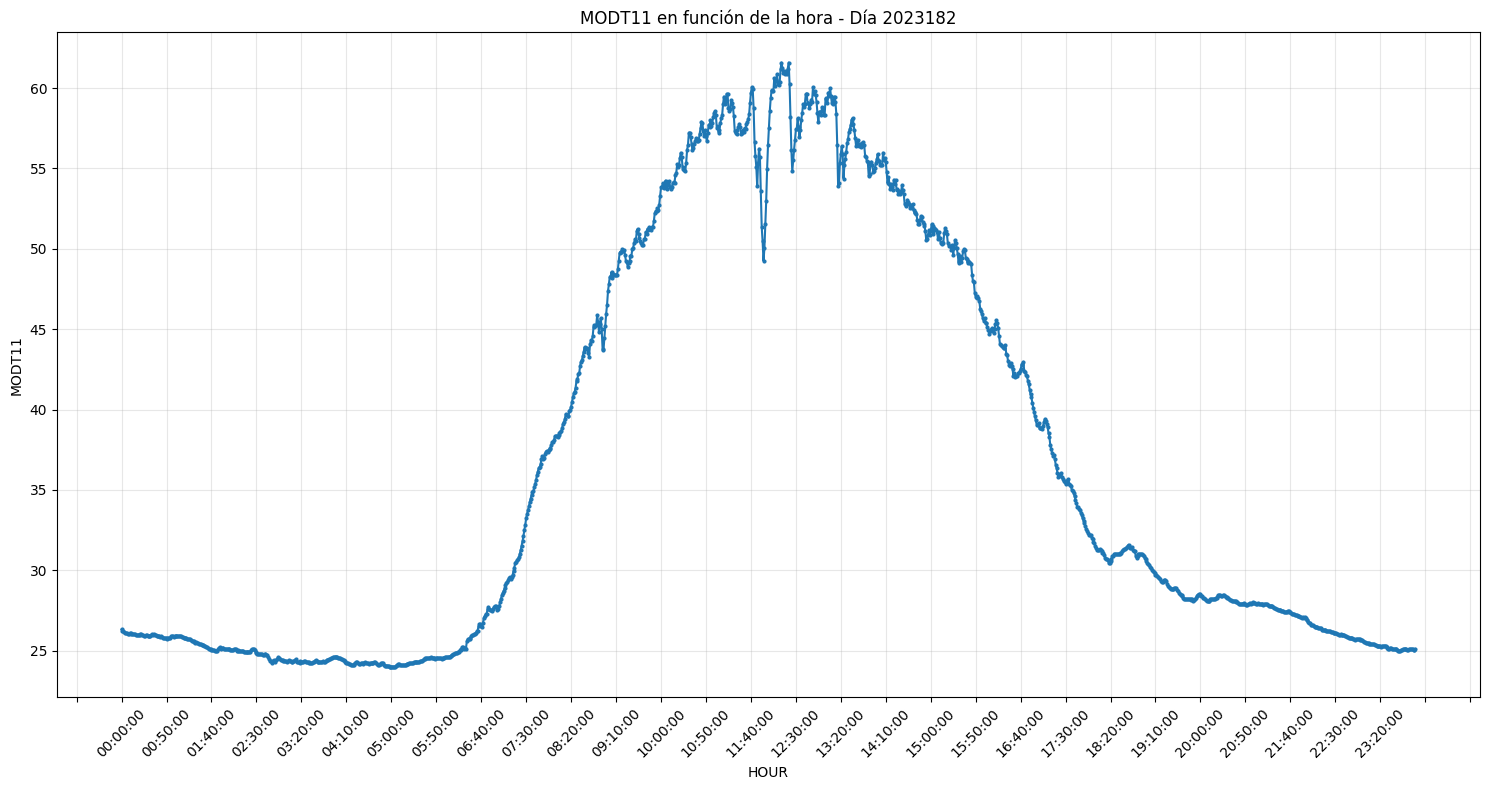

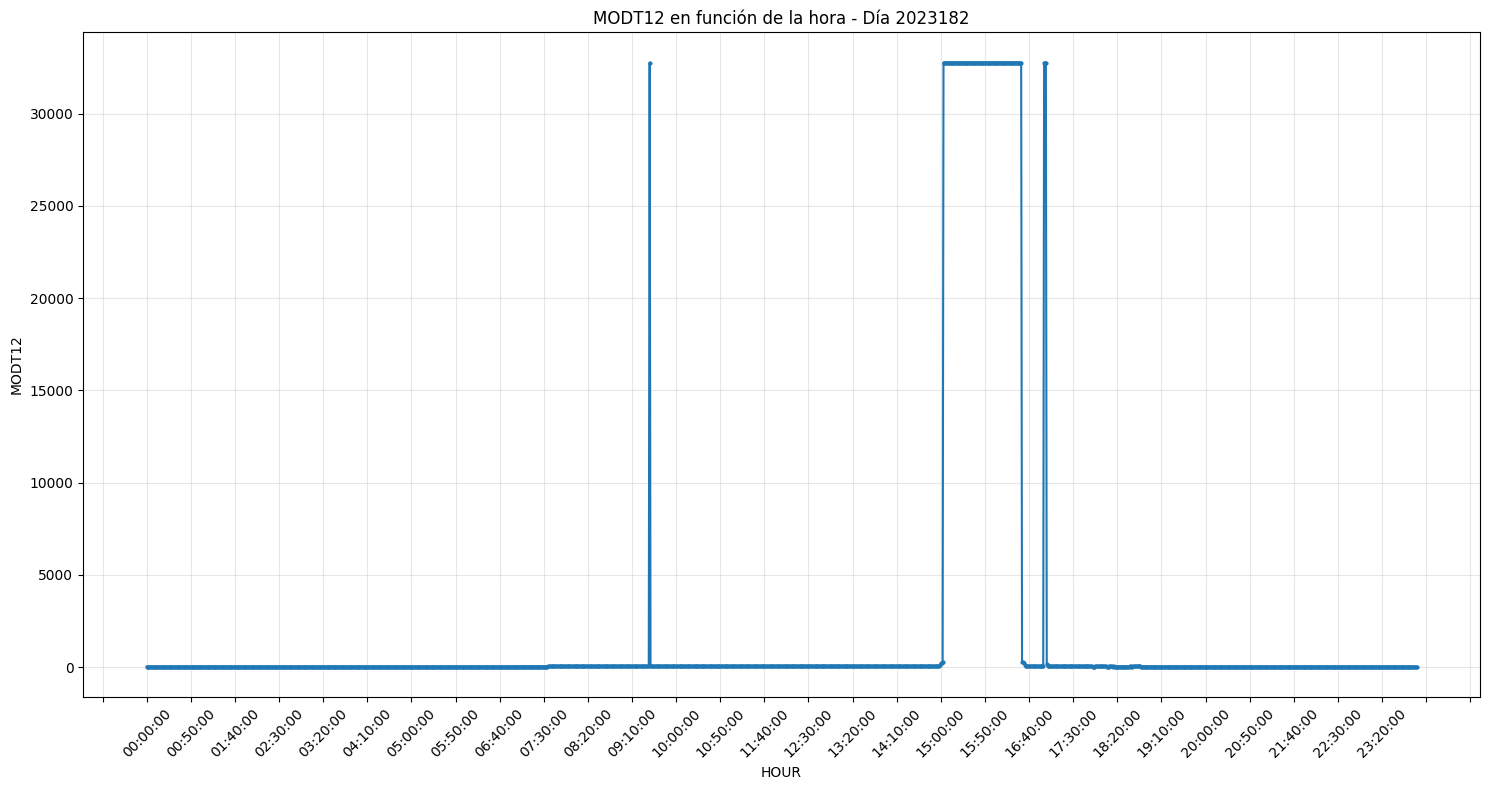

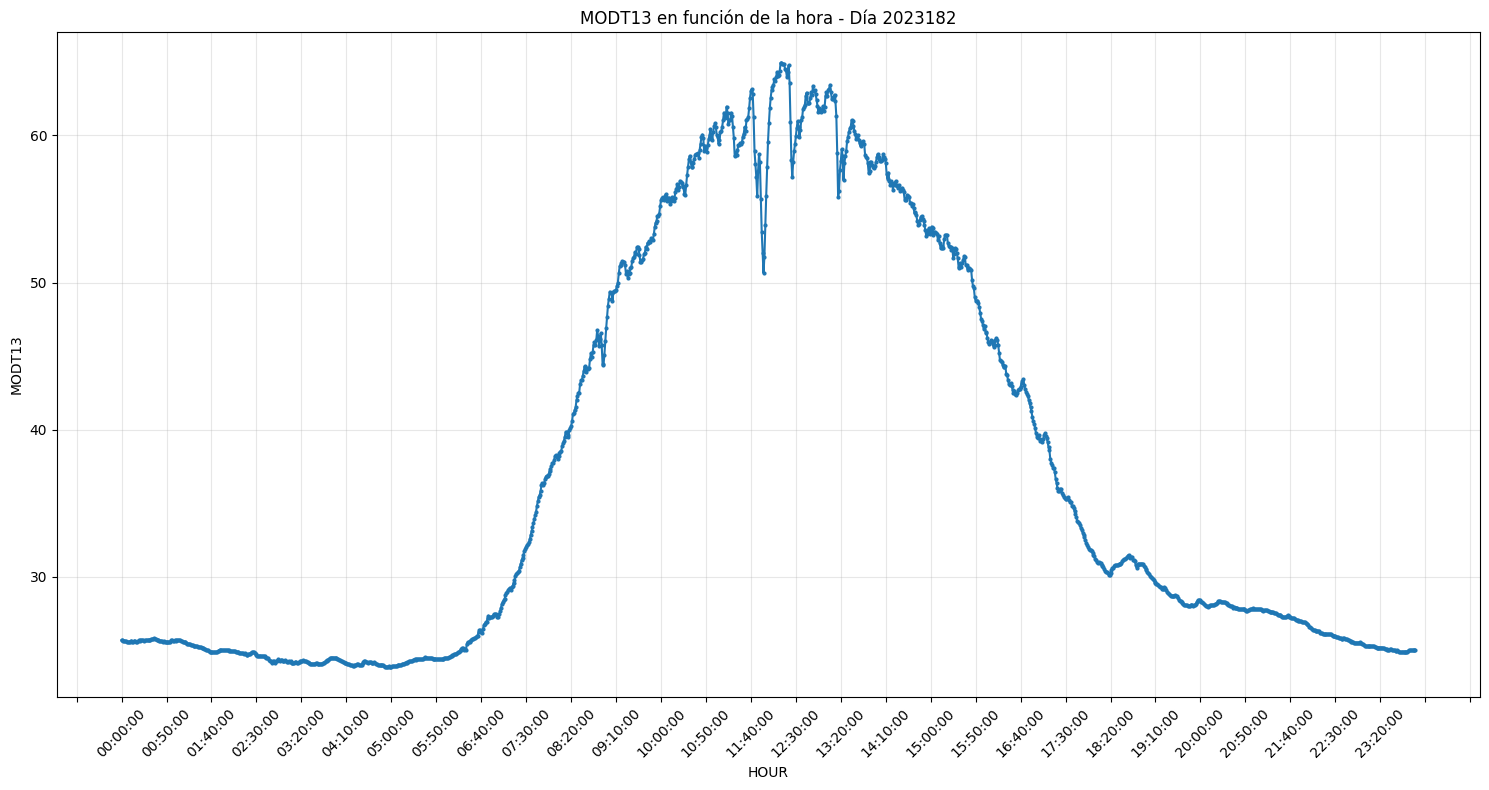

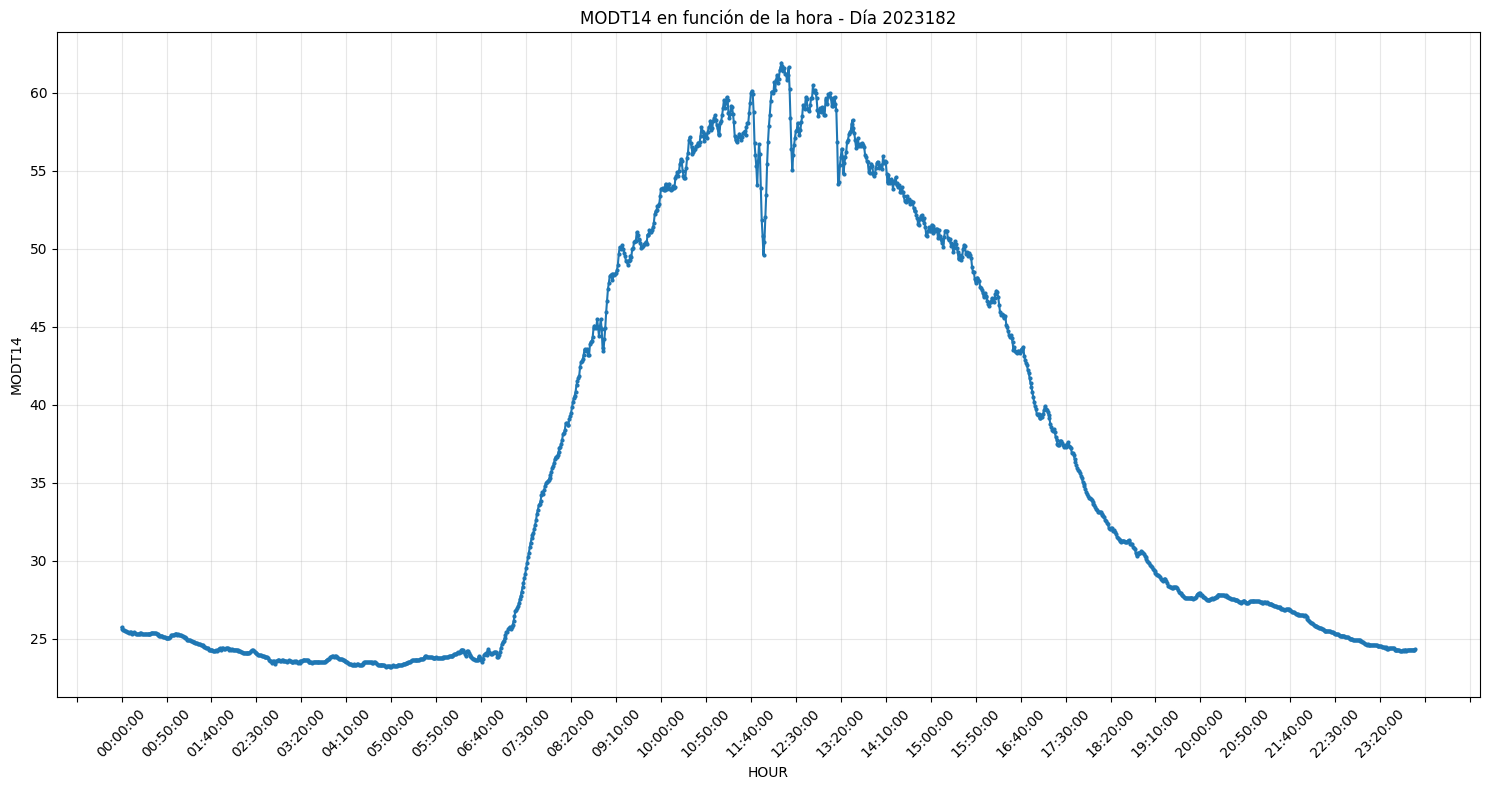

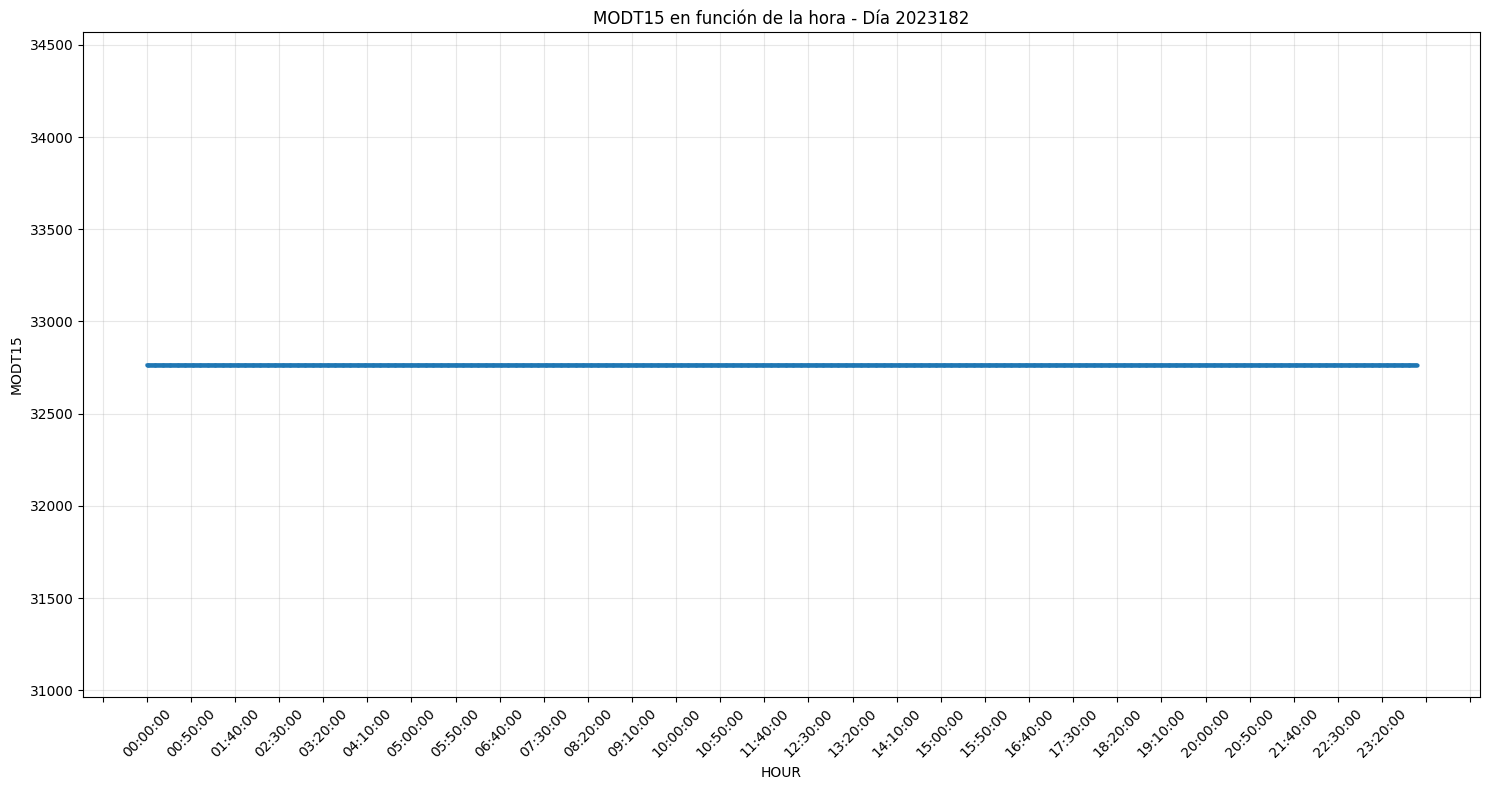

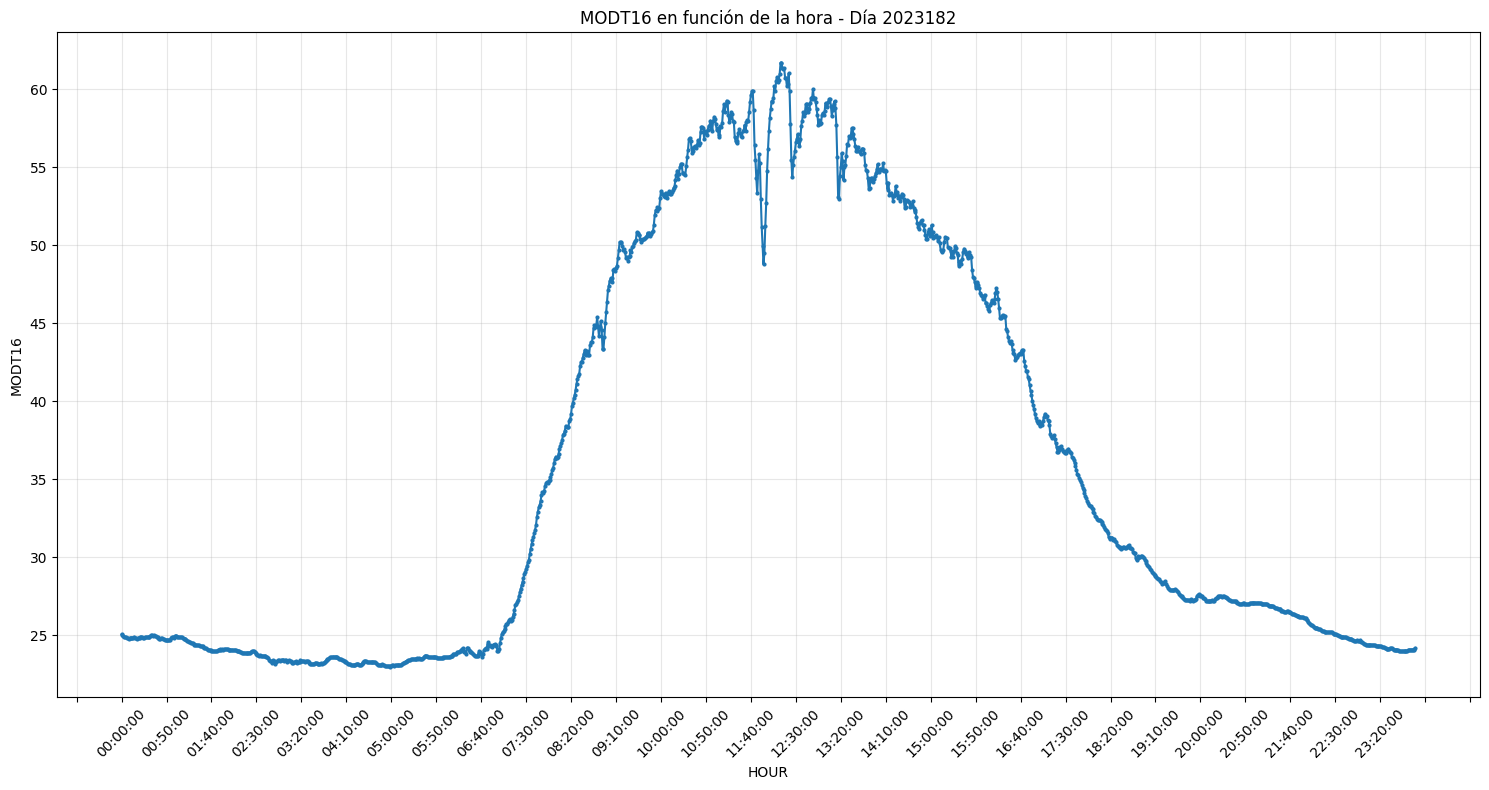

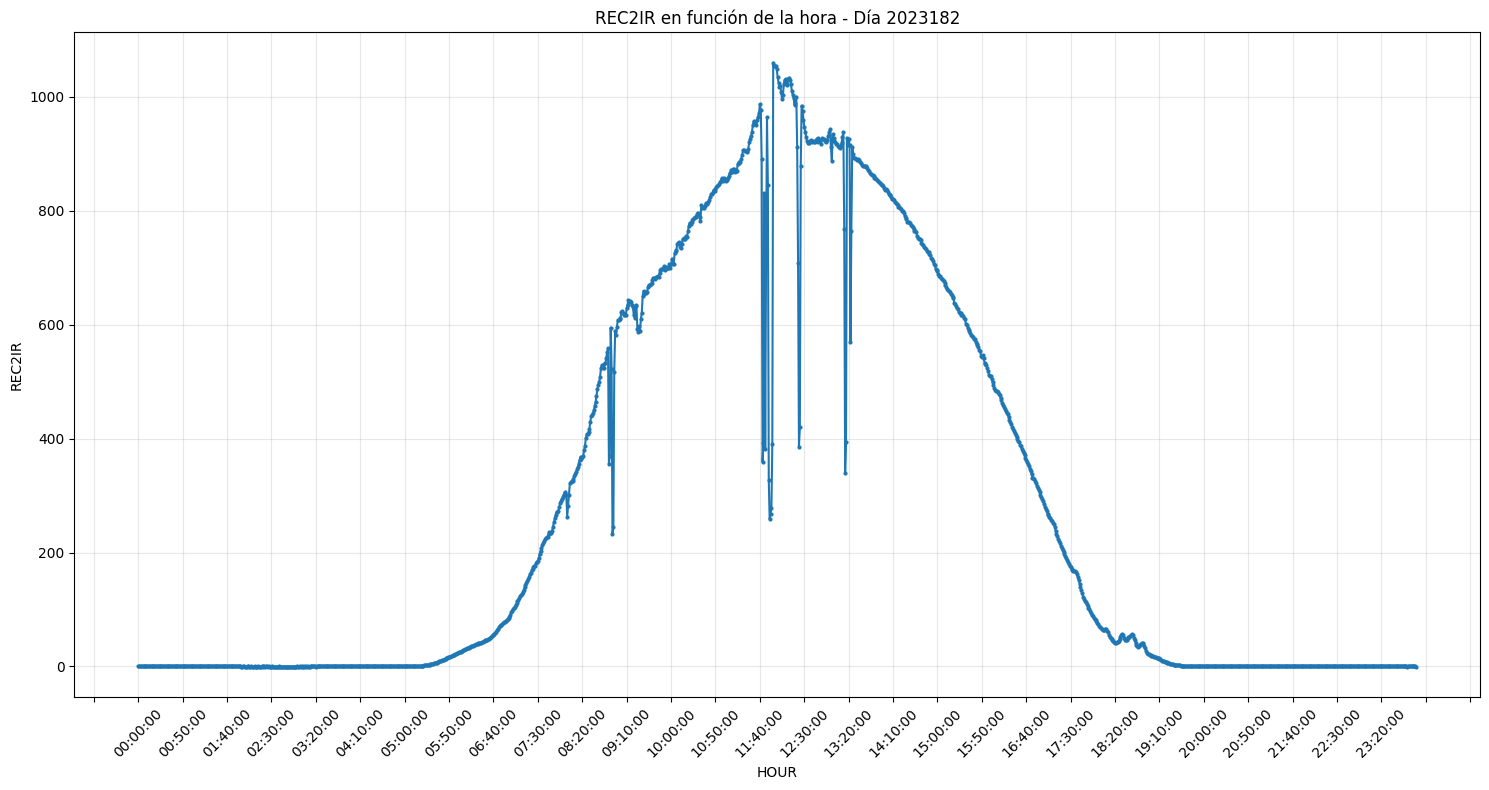

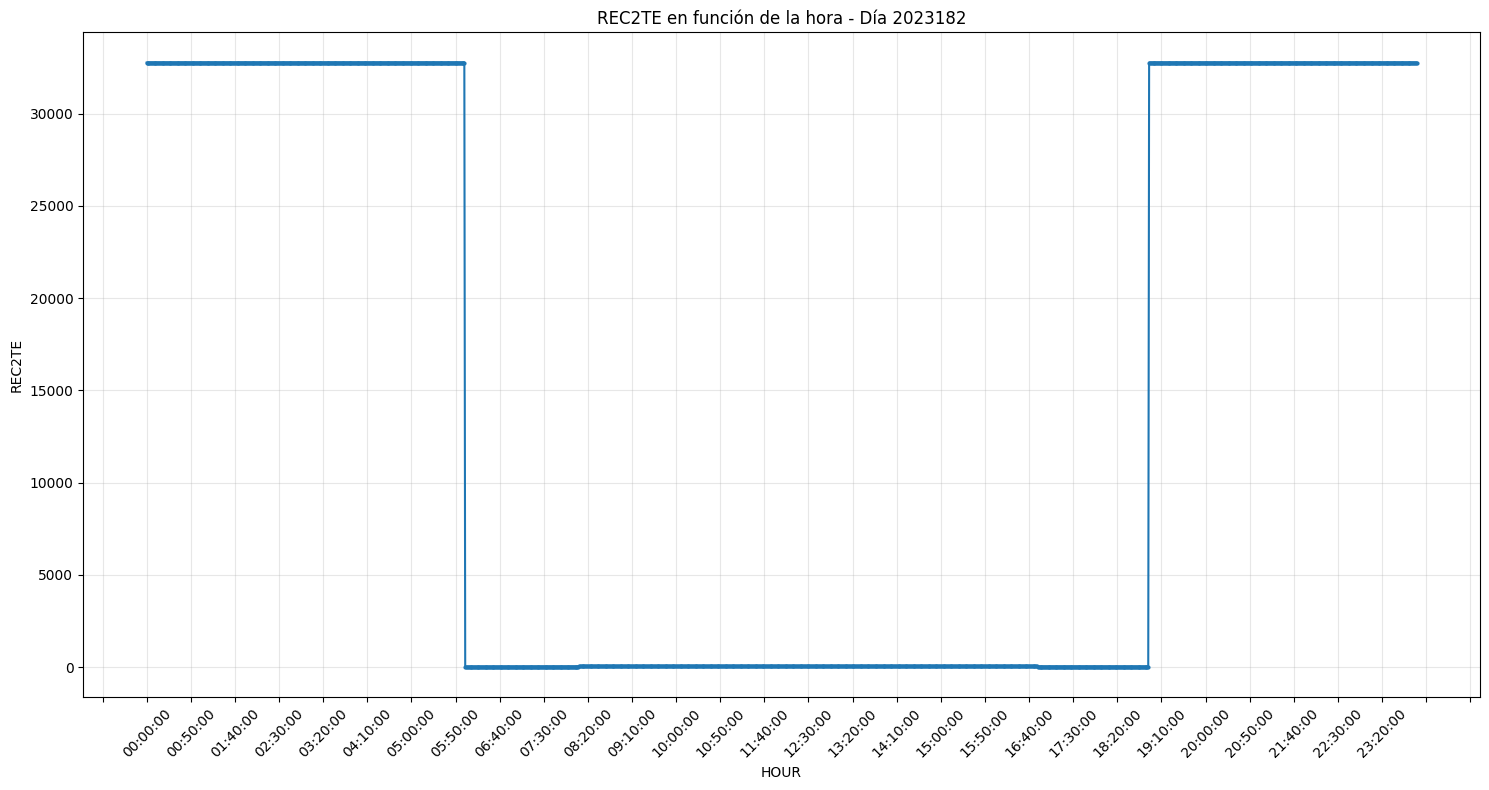

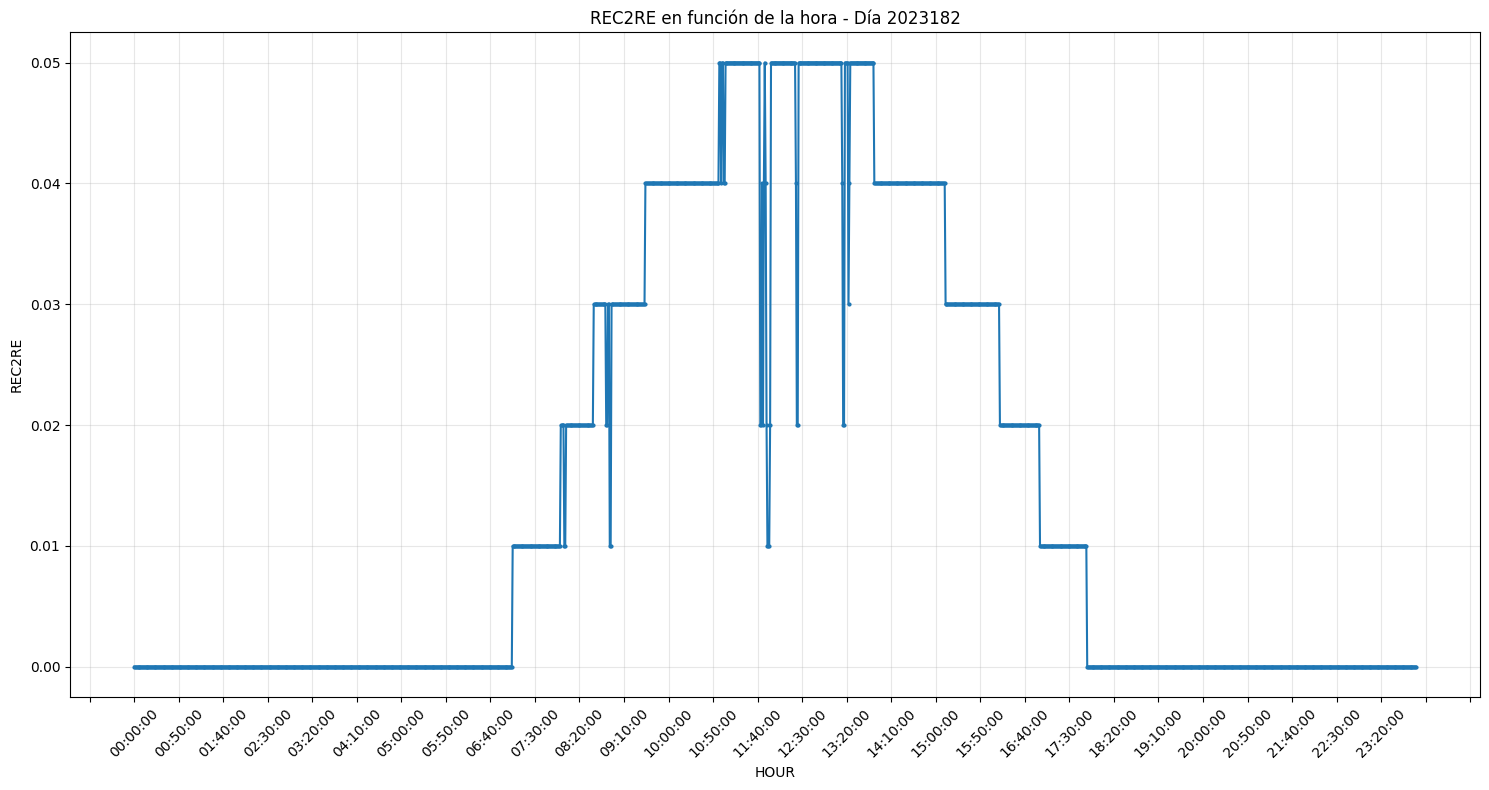

In [ ]:
campos = [
    'SY2VDC',
    'S2S1DC',
    'S2S2DC',
    'S2VACA',
    'S2IACA',
    'S2WACA',
    'S2VARA',
    'S2PFAV',
    'S2FRQA',
    'MODT09',
    'MODT10',
    'MODT11',
    'MODT12',
    'MODT13',
    'MODT14',
    'MODT15',
    'MODT16',
    'REC2IR',
    'REC2TE',
    'REC2RE'
]

day_value = 2023182

# Filtrar el día una sola vez
df_day = result[result['DAY'] == day_value][['DAY', 'HOUR'] + campos].copy()

# Ordenar por hora para que las líneas se unan correctamente
df_day = df_day.sort_values('HOUR')

# Generar una gráfica por cada campo
for campo in campos:

    plt.figure(figsize=(15, 8))

    plt.plot(
        df_day['HOUR'],
        df_day[campo],
        marker='o',
        linestyle='-',
        markersize=2
    )

    plt.xlabel('HOUR')
    plt.ylabel(campo)
    plt.title(f'{campo} en función de la hora - Día {day_value}')

    # Mostrar menos etiquetas en el eje X para que sea legible
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=36))

    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

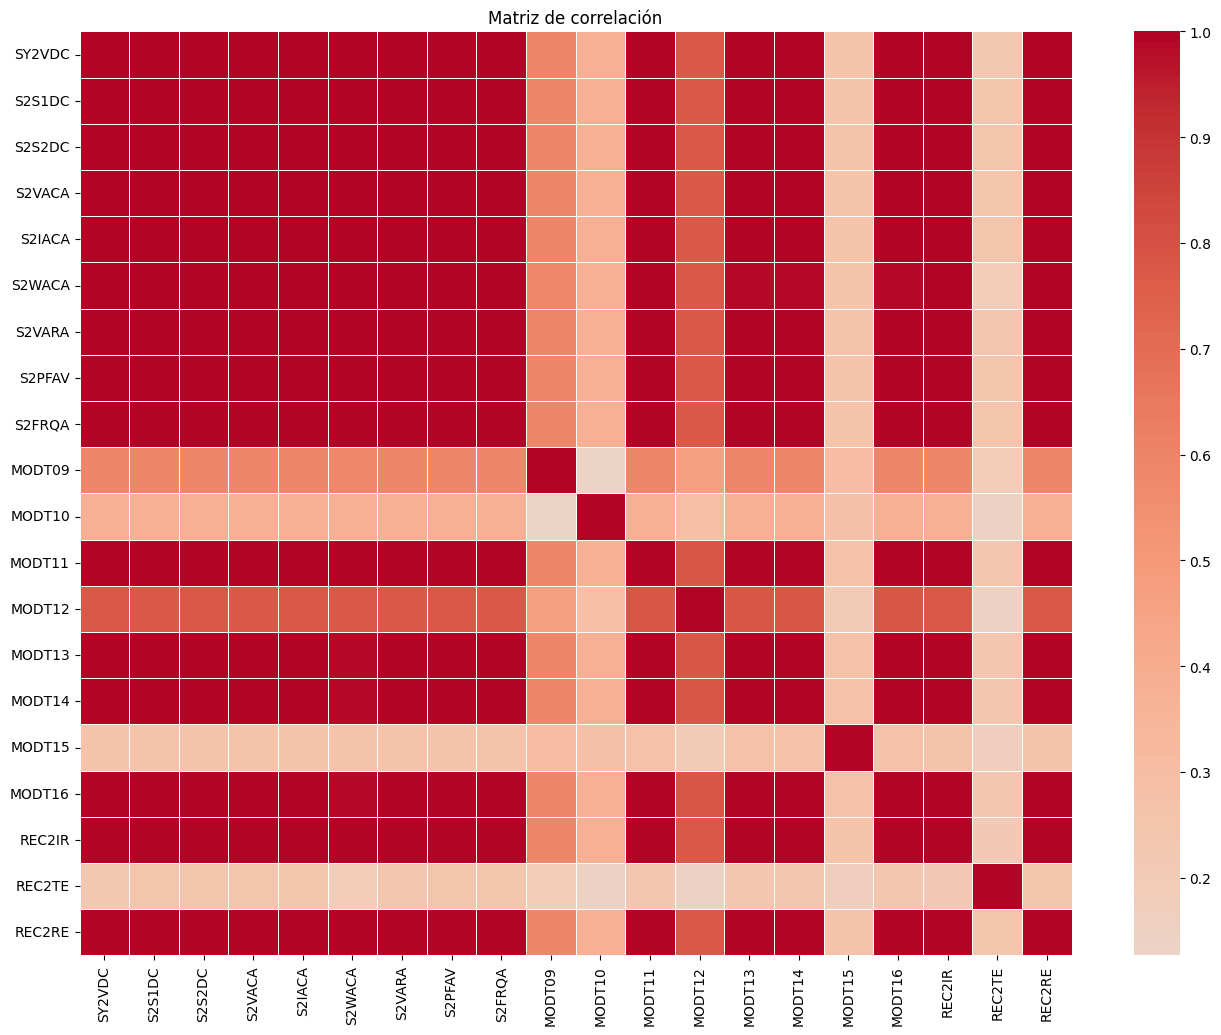

In [ ]:
#Correlación entre sensores de PV System 2 (SIN DATOS AMBIENTALES)
result_pvs2 = result[
    [
            'DAY',
            'HOUR',
            'SY2VDC',
            'S2S1DC',
            'S2S2DC',
            'S2VACA',
            'S2IACA',
            'S2WACA',
            'S2VARA',
            'S2PFAV',
            'S2FRQA',
            'MODT09',
            'MODT10',
            'MODT11',
            'MODT12',
            'MODT13',
            'MODT14',
            'MODT15',
            'MODT16',
            'REC2IR',
            'REC2TE',
            'REC2RE'
    ]
]

df_num = result_pvs2.select_dtypes(include="number").drop(['DAY'], axis=1)
corr_matrix = df_num.corr()

# Mostrar matriz
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.show()

Los datos de Tensión, Intensidad, Potencia e Irradiancia estánmuy altamente correlacionados. Sin embargo son los mayores indicadores de anomalías en el sistema, luego habría que estudiar la importancia de cada una de dichas variables, ya que nos puede llevar a detectar distintos tipos de anomalías.

Respecto a los sensores de temperatura, MODT09, MODT10, MODT15 y REC2TE guardan menor correlación con el resto de variables. Las demás estan muy correlacionadas entre sí, por eso nos quedaremos con dos.

Por el momento, a parte de las variables de Tensión, Intensidad, Potencia e Irradiancia, tendremos en cuenta:
- SY2VDC: System #2 Voltage DC Avg.(volts)
- S2S1DC: System 2 String 1 DC current (amps)
- S2S2DC: System 2 String 2 DC current (amps)
- S2VACA: System 2 Volts AC average (Volts)
- S2WACA: System 2 Power AC Average (watts)
- S2PFAV: System 2 Power Factor Average (PF)
- S2FRQA: System 2 Frequency Average (Hz)
- MODT09: Module Temperature 9 Avg.  (deg. C)
- MODT10: Module Temperature 10 Avg. (deg. C)
- MODT11: Module Temperature 11 Avg. (deg. C)
- MODT12: Module Temperature 12 Avg. (deg. C)
- MODT15: Module Temperature 15 Avg. (deg. C)
- REC2IR: Reference cell #2 Irradiance (watts/Sq. m)
- REC2TE: Reference cell #2 Temperature (C)

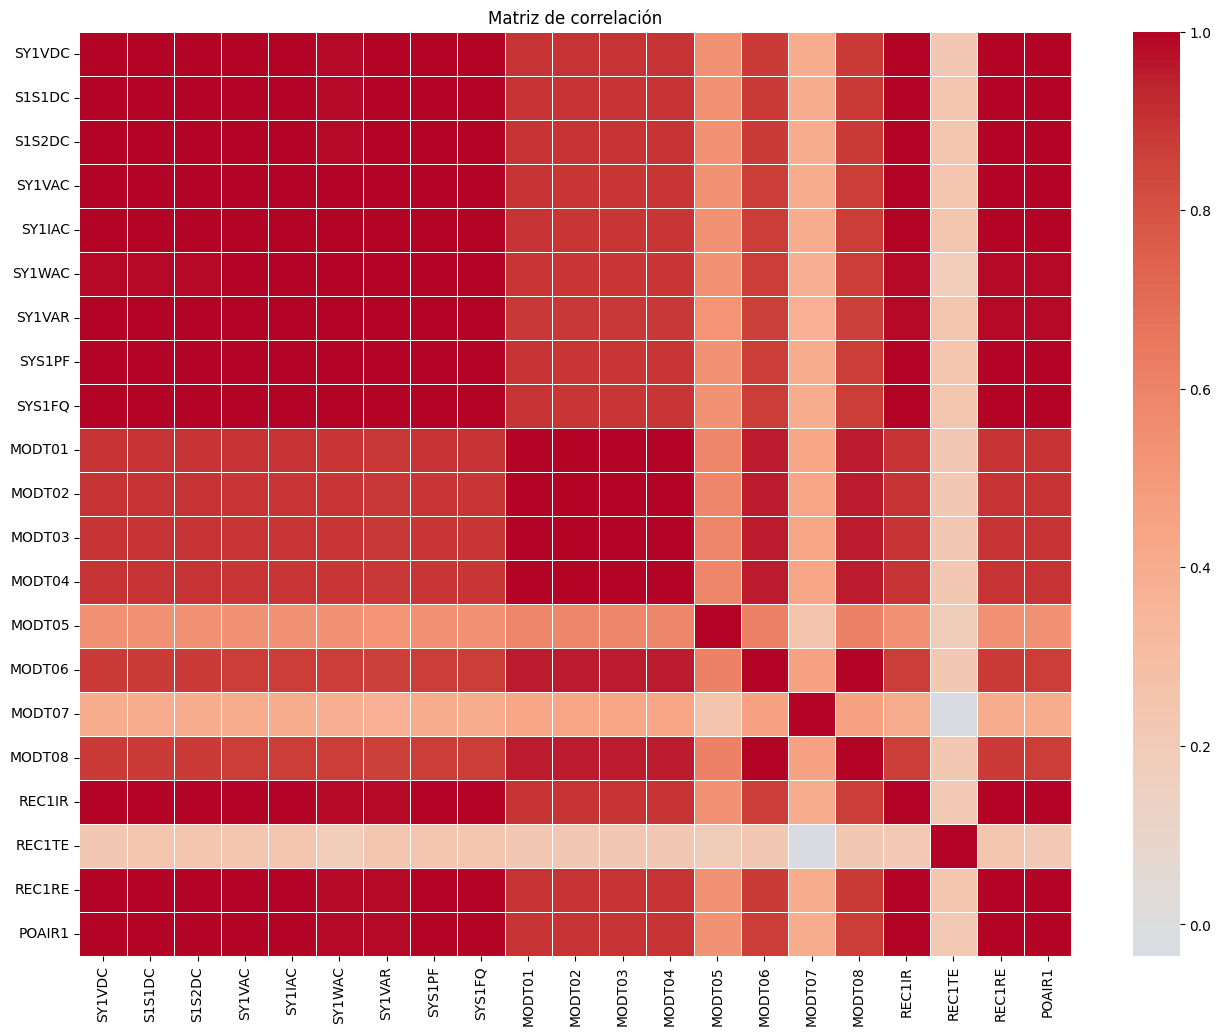

In [ ]:
#Correlación entre sensores de PV System 1 (SIN DATOS AMBIENTALES)
result_pvs1 = result[
    [
            'DAY',
            'HOUR',
            'SY1VDC',
            'S1S1DC',
            'S1S2DC',
            'SY1VAC',
            'SY1IAC',
            'SY1WAC',
            'SY1VAR',
            'SYS1PF',
            'SYS1FQ',
            'MODT01',
            'MODT02',
            'MODT03',
            'MODT04',
            'MODT05',
            'MODT06',
            'MODT07',
            'MODT08',
            'REC1IR',
            'REC1TE',
            'REC1RE',
            'POAIR1'
    ]
]

df_num = result_pvs1.select_dtypes(include="number").drop(['DAY'], axis=1)
corr_matrix = df_num.corr()

# Mostrar matriz
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.show()

Al igual que en el otr caso, los datos de Tensión, Intensidad, Potencia e Irradiancia estánmuy altamente correlacionados. Sin embargo son los mayores indicadores de anomalías en el sistema, luego habría que estudiar la importancia de cada una de dichas variables, ya que nos puede llevar a detectar distintos tipos de anomalías.

Respecto a los sensores de temperatura, MODT05, MODT07 y REC1TE guardan menos correlación con el resto de variables. Las demás estan muy correlacionadas entre sí, aunque menos que el sistema 2.

Nos quedaremos con los campos equivalentes al Sistema 2:

- SY1VDC: System #1 Voltage DC Avg. (Volts)
- S1S1DC: System #1 String1 DC Current Avg. (Amps)
- S1S2DC: System #1 String2 DC Current Avg. (Amps)
- SY1VAC: System Voltage AC #1 Avg. (Volts)
- SY1WAC: System 1 Power AC Average (watts)
- SYS1PF: System 1 Power Factor (PF)
- SYS1FQ: System 1 Frequency (Hz)
- MODT01: Module Temperature 1 Avg. (deg. C)
- MODT02: Module Temperature 2 Avg. (deg. C)
- MODT04: Module Temperature 4 Avg. (deg. C)
- MODT05: Module Temperature 11 Avg. (deg. C)
- MODT07: Module Temperature 15 Avg. (deg. C)
- REC1TE: Reference cell #2 Temperature (C)


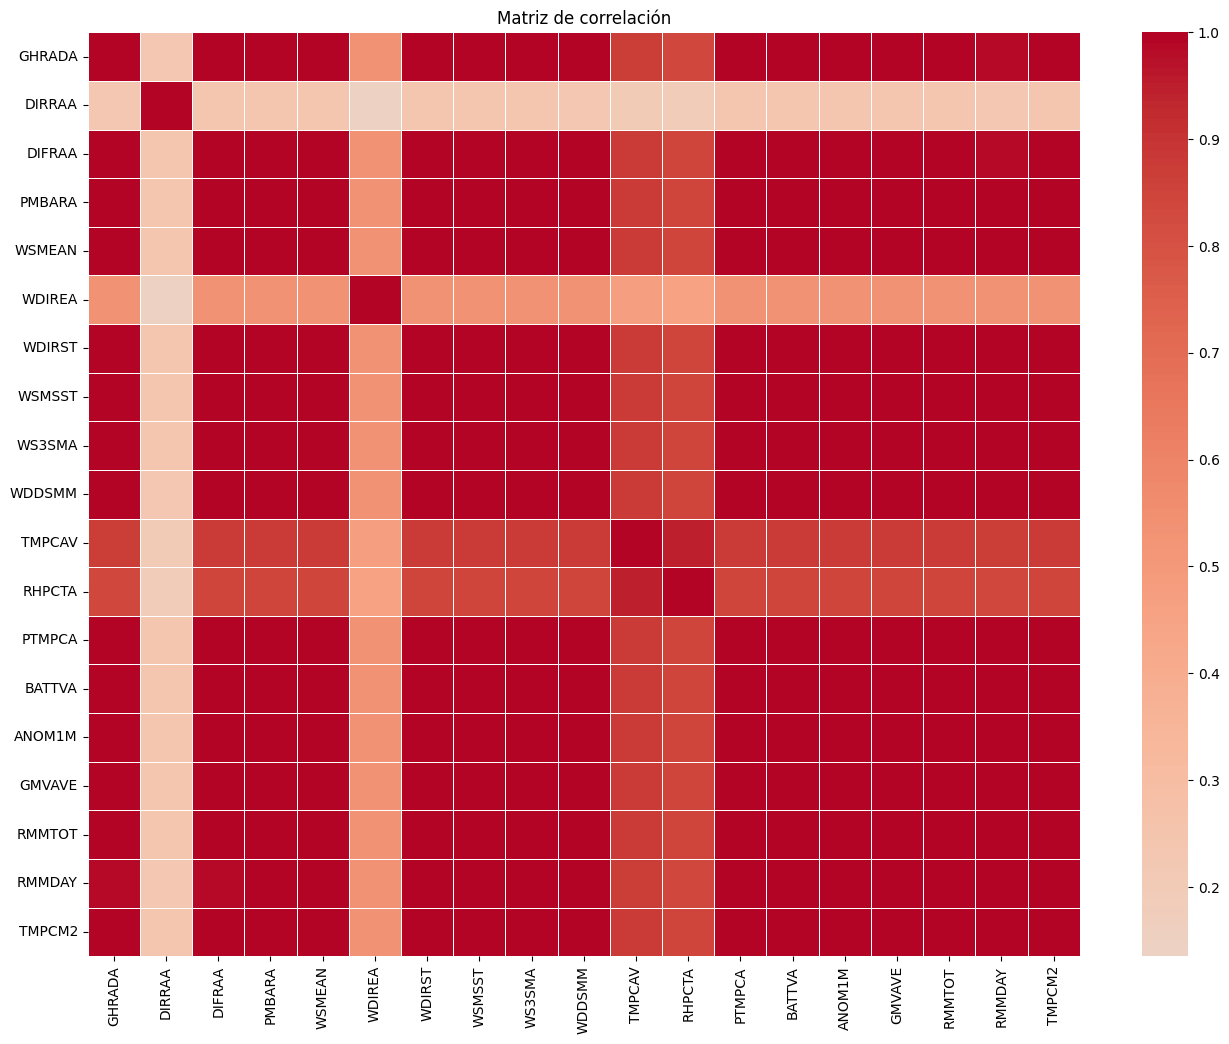

In [ ]:
#Correlación entre campos ambientales
result_amb = result[
    [
            'GHRADA',
            'DIRRAA',
            'DIFRAA',
            'PMBARA',
            'WSMEAN',
            'WDIREA',
            'WDIRST',
            'WSMSST',
            'WS3SMA',
            'WDDSMM',
            'TMPCAV',
            'RHPCTA',
            'PTMPCA',
            'BATTVA',
            'ANOM1M',
            'GMVAVE',
            'RMMTOT',
            'RMMDAY',
            'TMPCM2'
    ]
]

df_num = result_amb.select_dtypes(include="number")
corr_matrix = df_num.corr()

# Mostrar matriz
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.show()

Los datos ambientales están muy altamente correlacionados salvo DIRRAA (Direct Solar Radiation Avg. (watts/Sq. m)) y WDIREA (Wind direction mean (deg)).

Por lo tanto, se decide descartar los campos más redundantes. Nos quedamos fianlmente con:
- GHRADA: Global Horizontal Radiation Avg. (watts/Sq. m)
- DIRRAA: Direct Solar Radiation Avg. (watts/Sq. m)
- PMBARA: Atmospheric pressure average (mbar)
- WSMEAN: Wind speed mean (m/sec)
- WDIREA: Wind direction mean (deg)
- TMPCAV: Ambient temperature average (C)
- RHPCTA: Relative humidity percent average(RH%)

Propongo empezar la detección de anomalías con uno de los dos sistemas.

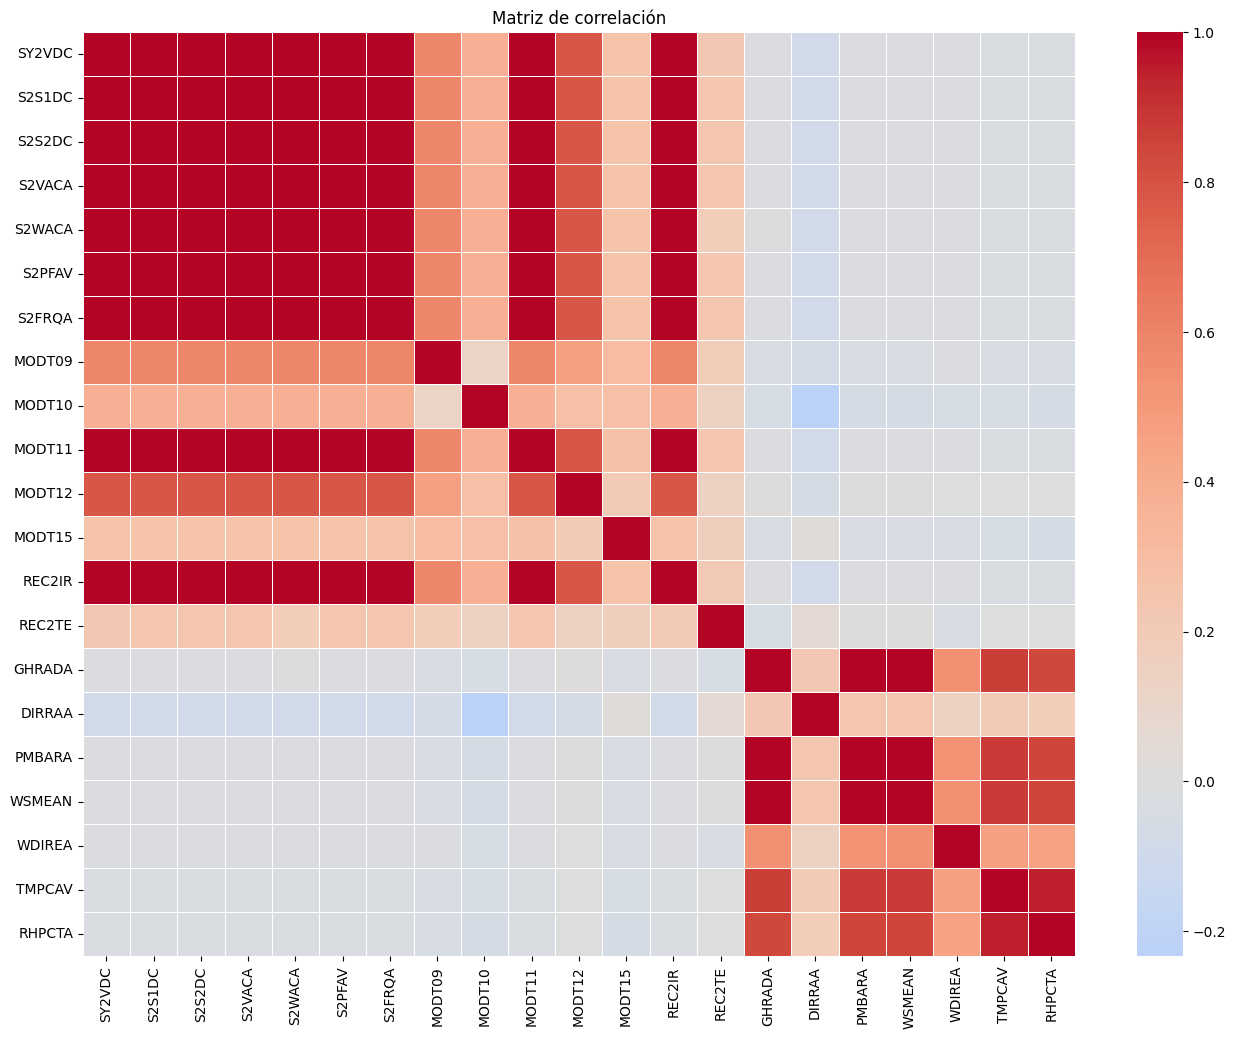

In [ ]:
result_pvs2 = result[
    [
            'DAY',
            'HOUR',
            'SY2VDC',
            'S2S1DC',
            'S2S2DC',
            'S2VACA',
            'S2WACA',
            'S2PFAV',
            'S2FRQA',
            'MODT09',
            'MODT10',
            'MODT11',
            'MODT12',
            'MODT15',
            'REC2IR',
            'REC2TE',
            'GHRADA',
            'DIRRAA',
            'PMBARA',
            'WSMEAN',
            'WDIREA',
            'TMPCAV',
            'RHPCTA'
    ]
]

df_num = result_pvs2.select_dtypes(include="number").drop(['DAY'], axis=1)
corr_matrix = df_num.corr()

# Mostrar matriz
plt.figure(figsize=(16, 12))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    annot=False,
    linewidths=0.5
)

plt.title("Matriz de correlación")
plt.show()

In [ ]:
corr_matrix[['GHRADA',
            'DIRRAA',
            'PMBARA',
            'WSMEAN',
            'WDIREA',
            'TMPCAV',
            'RHPCTA']].head(14)

,GHRADA,DIRRAA,PMBARA,WSMEAN,WDIREA,TMPCAV,RHPCTA
SY2VDC,-0.016684,-0.089091,-0.020535,-0.020624,-0.016935,-0.023346,-0.024928
S2S1DC,-0.018220,-0.088899,-0.020712,-0.020805,-0.017904,-0.023604,-0.025200
S2S2DC,-0.018251,-0.088907,-0.020716,-0.020810,-0.017917,-0.023608,-0.025205
S2VACA,-0.018225,-0.088912,-0.020707,-0.020800,-0.017910,-0.023442,-0.025033
S2WACA,-0.008244,-0.088104,-0.020278,-0.020366,-0.013736,-0.022908,-0.024551
S2PFAV,-0.018247,-0.088906,-0.020717,-0.020810,-0.017917,-0.023455,-0.025044
S2FRQA,-0.018252,-0.088906,-0.020717,-0.020811,-0.017920,-0.023455,-0.025045
MODT09,-0.034611,-0.064545,-0.035340,-0.035588,-0.020798,-0.040886,-0.039635
MODT10,-0.052407,-0.233271,-0.055782,-0.055164,-0.048837,-0.054132,-0.057982
MODT11,-0.017995,-0.089097,-0.020545,-0.020658,-0.017719,-0.025690,-0.027101


Las variables atmosfericas no guardan correlación alguna con las variables de datos captados con los sensores. Habria que estudiar si realmente nos son útiles.

In [ ]:

#Generar campo que una día y hora
result_pvs2['datetime'] = (
    pd.to_datetime(result_pvs2['DAY'].astype(str), format='%Y%j')
    + pd.to_timedelta(result_pvs2['HOUR'])
)

/tmp/ipykernel_4132/2327932619.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  result_pvs2['datetime'] = (


In [ ]:
result_pvs2.head(10)

,DAY,HOUR,SY2VDC,S2S1DC,S2S2DC,S2VACA,S2WACA,S2PFAV,S2FRQA,MODT09,...,REC2IR,REC2TE,GHRADA,DIRRAA,PMBARA,WSMEAN,WDIREA,TMPCAV,RHPCTA,datetime
2103839,2018001,00:00:00,4.4,0.27,-0.01,280.0,-91.6,-0.16,60.01,16.14,...,0.0,0.0,-2.1,0.5,1019.8,0.0,0.0,13.39,81.9,2018-01-01 00:00:00
2103840,2018001,00:01:00,4.4,0.28,-0.01,280.1,-91.8,-0.16,60.01,16.12,...,0.0,0.0,-2.1,0.4,1019.8,0.0,0.0,13.41,82.0,2018-01-01 00:01:00
2103841,2018001,00:02:00,4.4,0.27,-0.01,280.2,-92.0,-0.15,60.02,16.12,...,0.0,0.0,-2.1,0.5,1019.8,0.0,0.0,13.43,82.0,2018-01-01 00:02:00
2103842,2018001,00:03:00,4.3,0.22,-0.01,280.3,-91.9,-0.15,60.03,16.11,...,0.0,0.0,-2.1,0.5,1019.8,0.0,0.0,13.42,82.0,2018-01-01 00:03:00
2103843,2018001,00:04:00,4.2,0.22,-0.01,280.4,-92.1,-0.15,60.03,16.10,...,0.0,0.0,-2.1,0.5,1019.9,0.0,0.0,13.42,82.0,2018-01-01 00:04:00
2103844,2018001,00:05:00,4.2,0.23,-0.01,280.3,-92.0,-0.15,60.03,16.09,...,0.0,0.0,-2.1,0.4,1019.9,0.0,0.0,13.42,81.9,2018-01-01 00:05:00
2103845,2018001,00:06:00,4.2,0.26,-0.01,280.1,-91.8,-0.16,60.03,16.10,...,0.0,0.0,-2.1,0.4,1019.9,0.0,0.0,13.42,81.9,2018-01-01 00:06:00
2103846,2018001,00:07:00,4.2,0.27,-0.01,280.0,-91.8,-0.16,60.01,16.10,...,0.0,0.0,-2.1,0.4,1019.9,0.0,0.0,13.42,82.0,2018-01-01 00:07:00
2103847,2018001,00:08:00,4.0,0.25,-0.01,280.3,-91.9,-0.15,60.01,16.10,...,0.0,0.0,-2.1,0.4,1019.9,0.0,0.0,13.42,82.1,2018-01-01 00:08:00
2103848,2018001,00:09:00,3.9,0.28,-0.01,280.3,-92.1,-0.15,60.01,16.10,...,0.0,0.0,-2.1,0.4,1019.9,0.0,0.0,13.43,82.1,2018-01-01 00:09:00


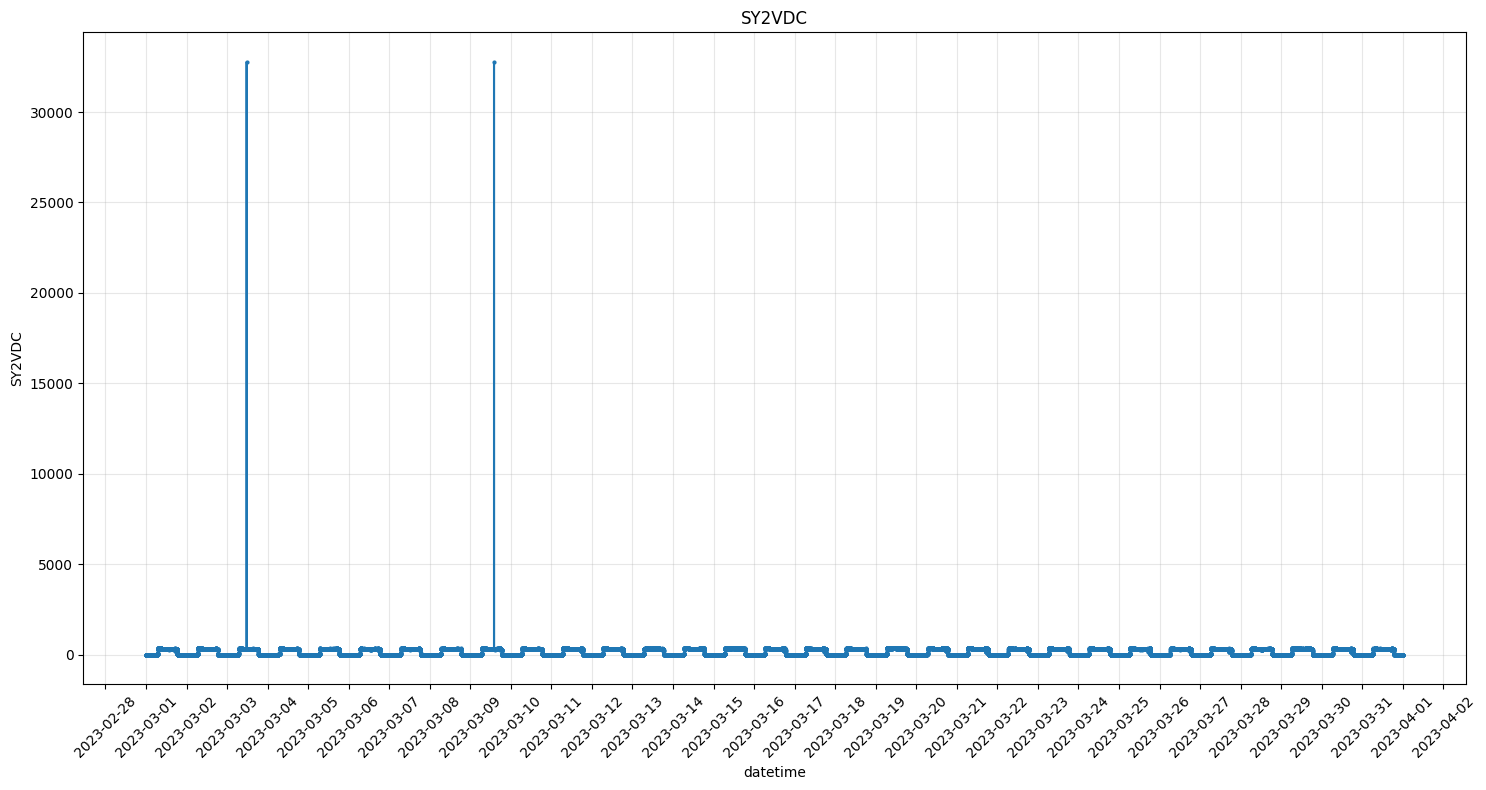

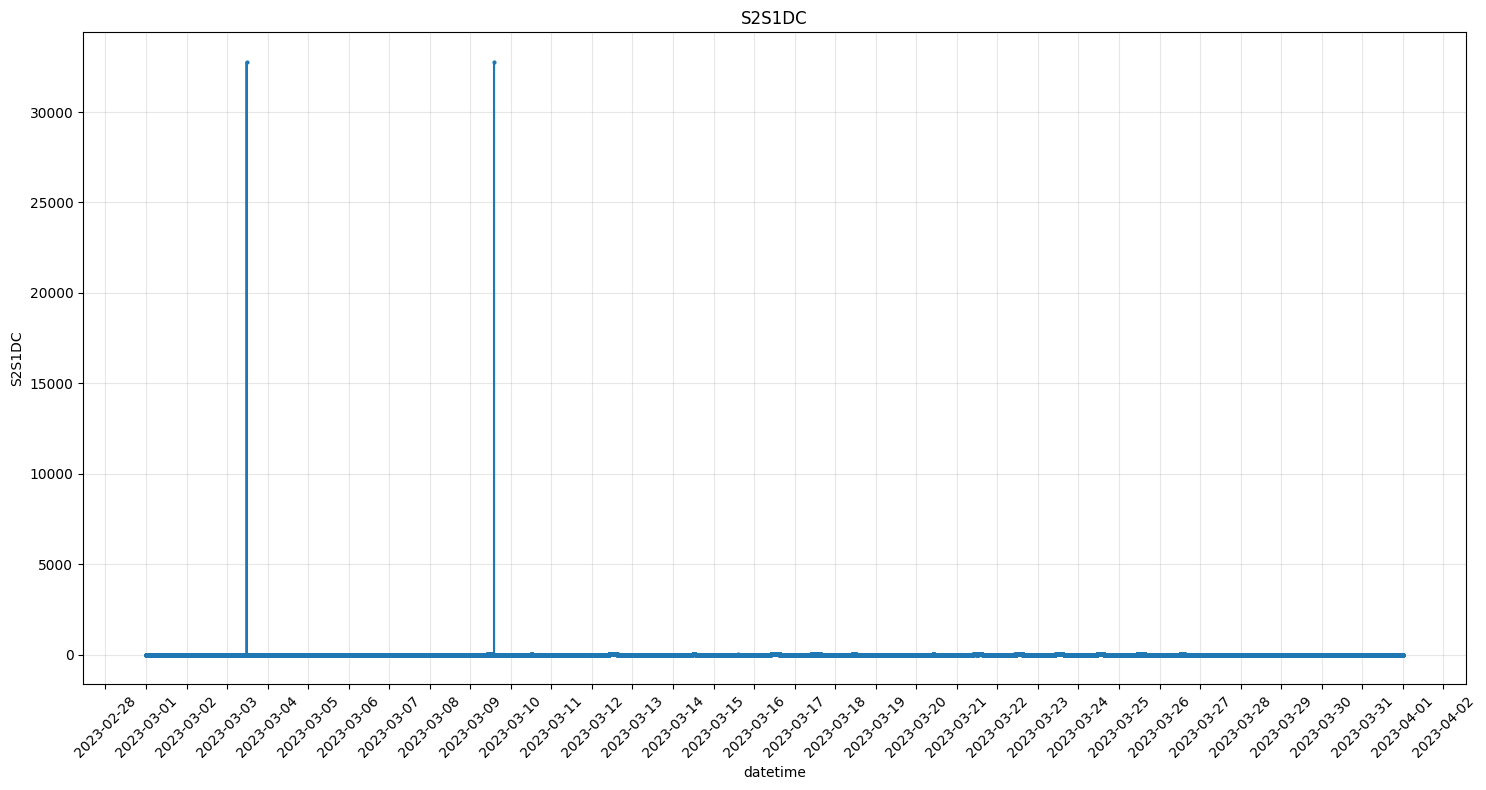

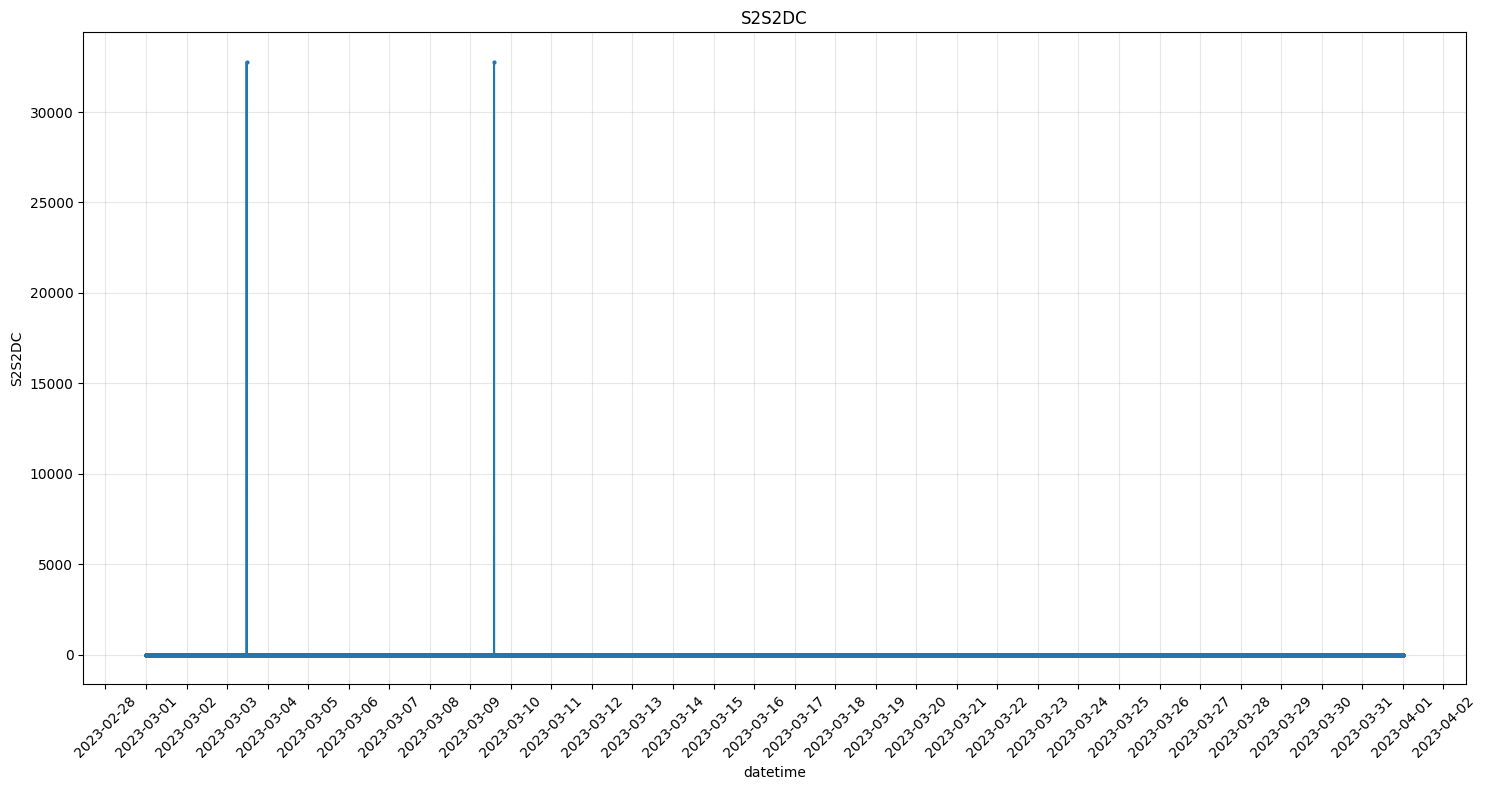

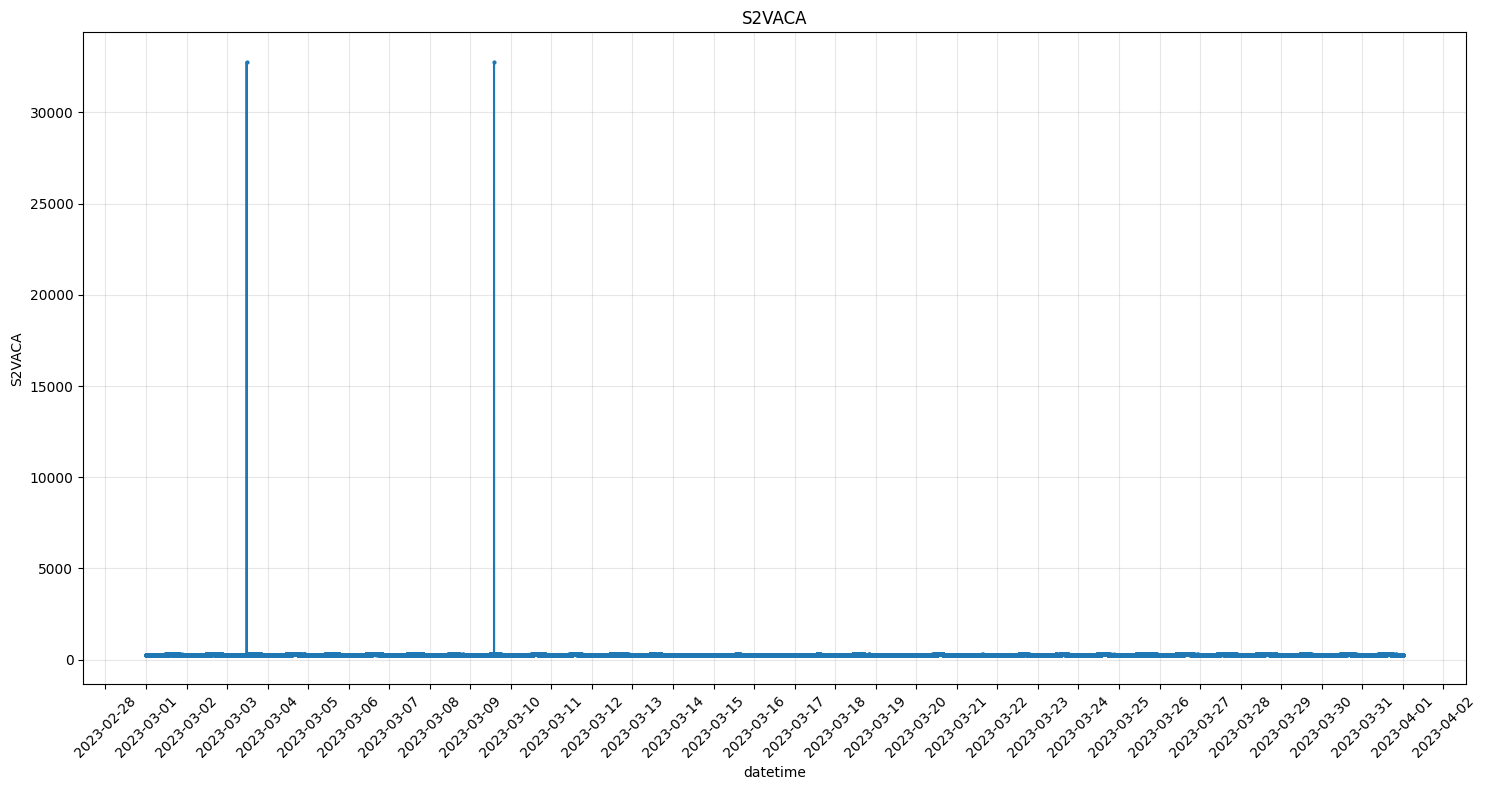

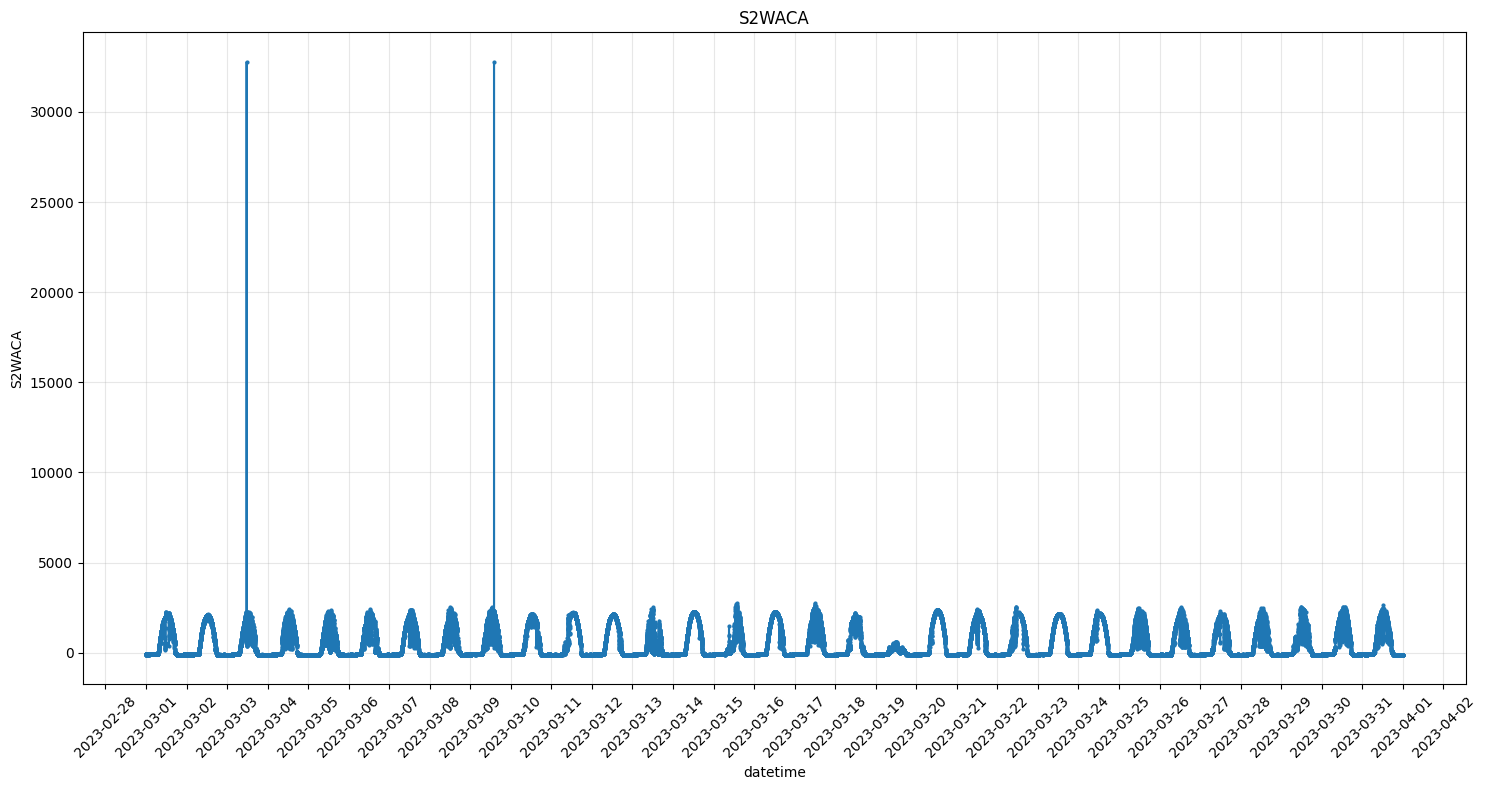

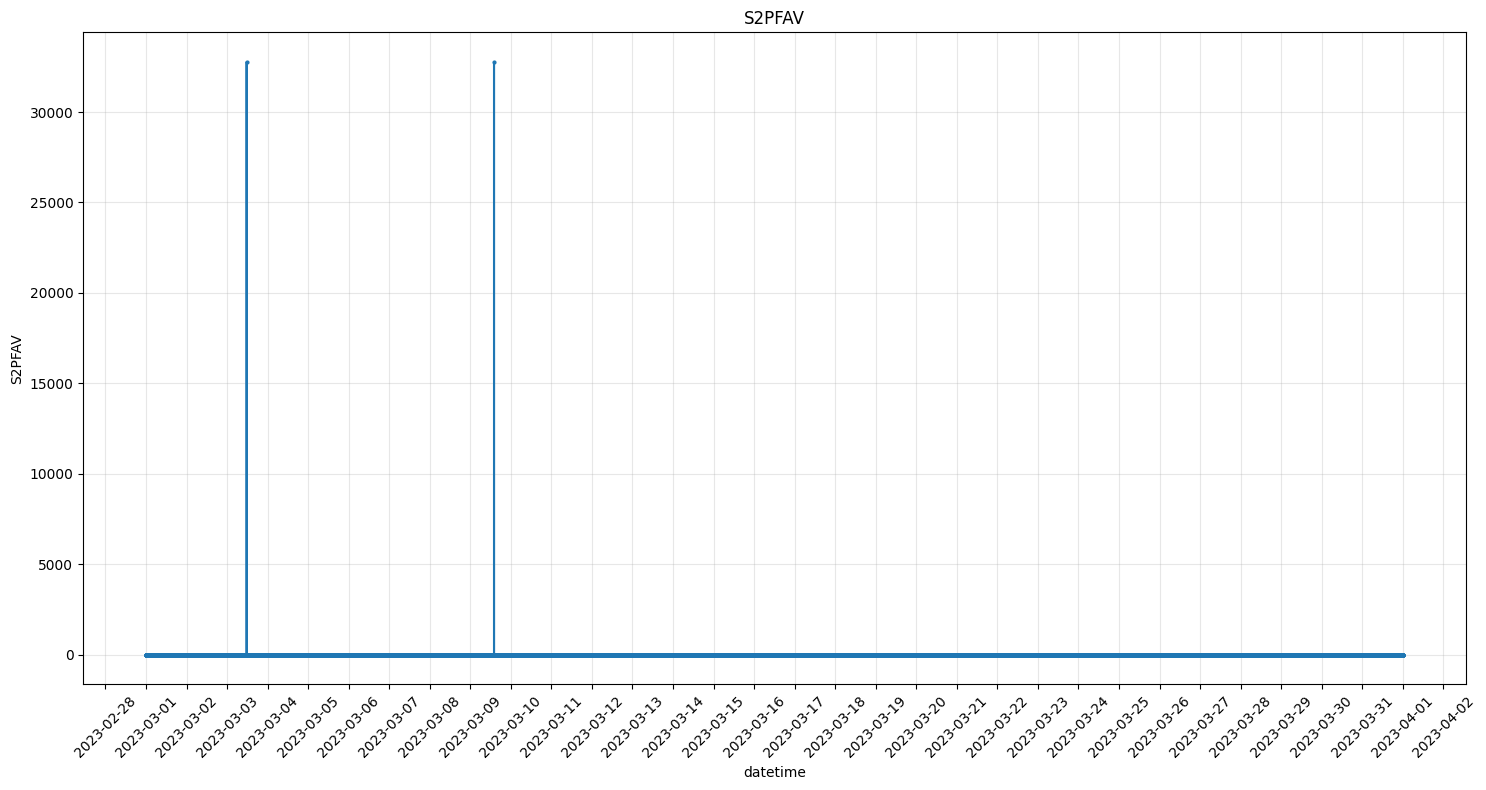

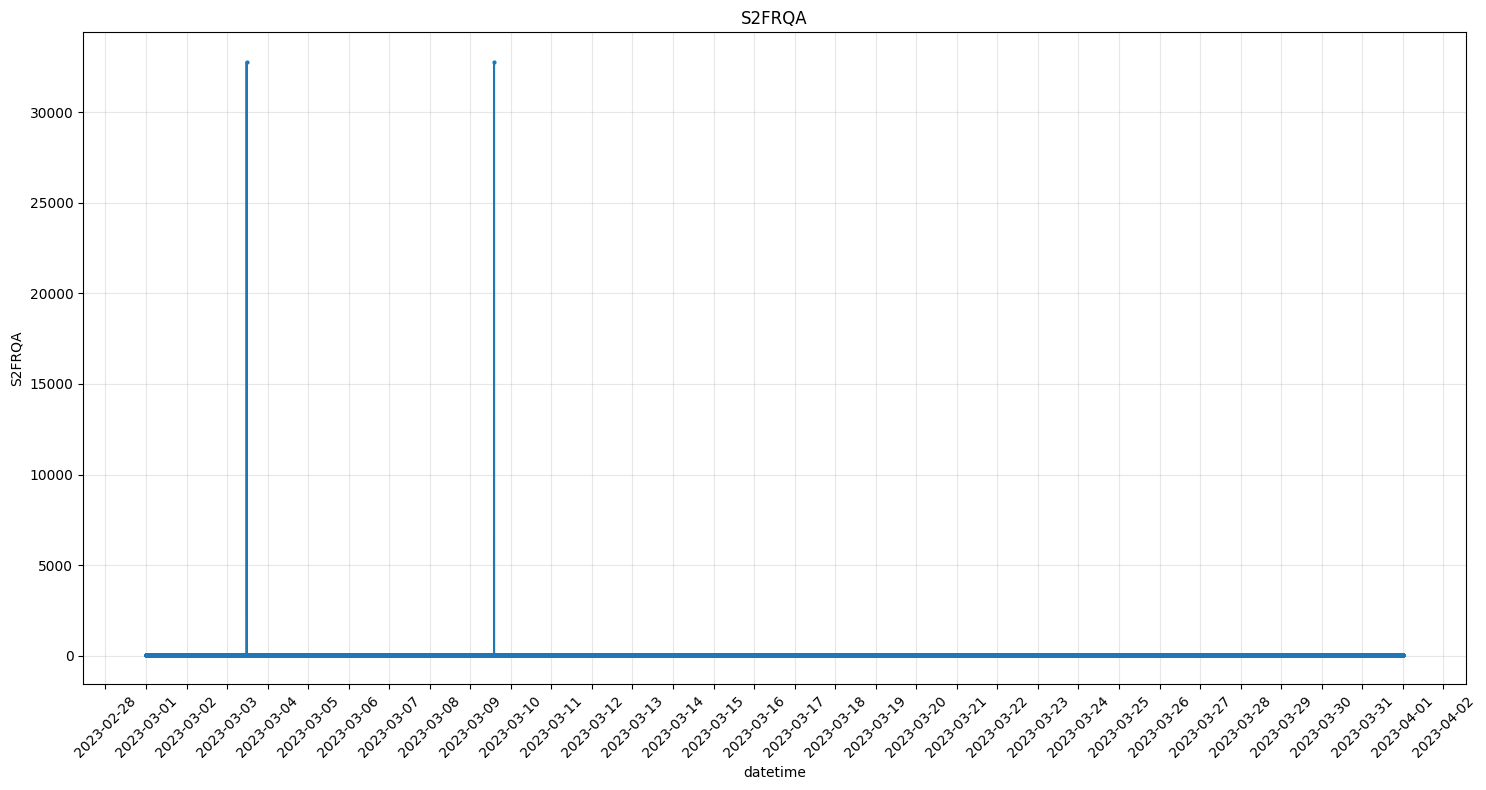

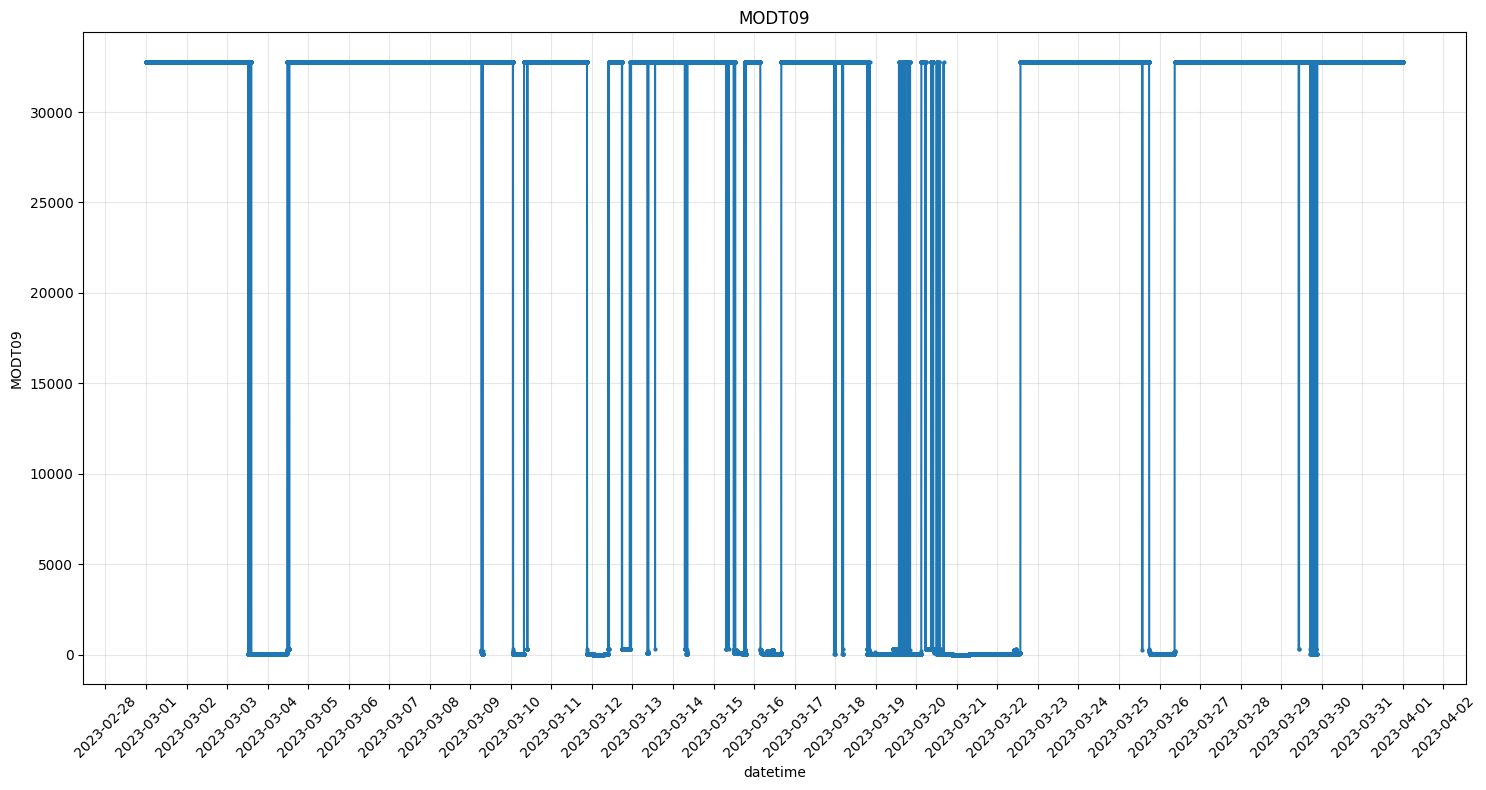

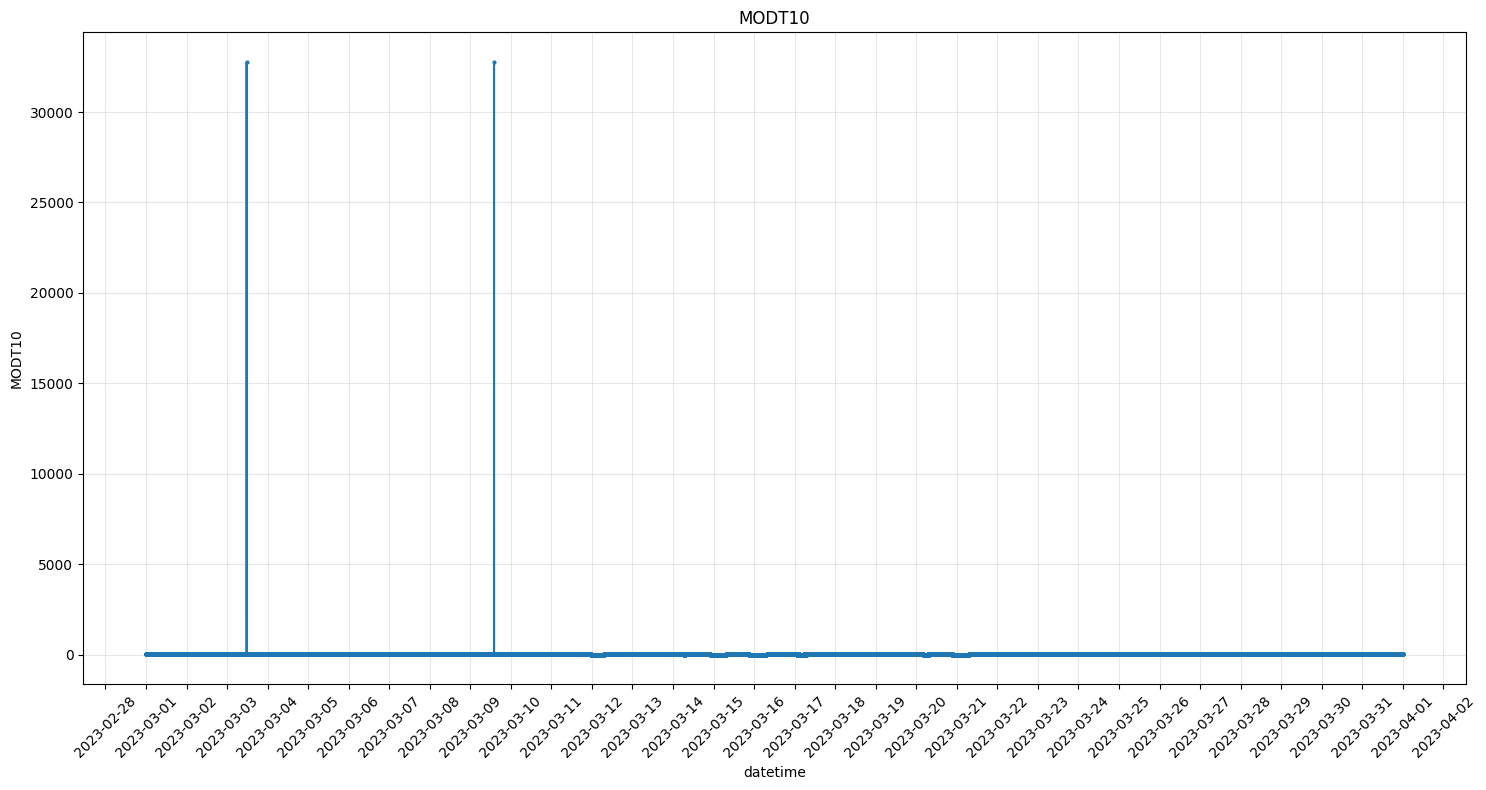

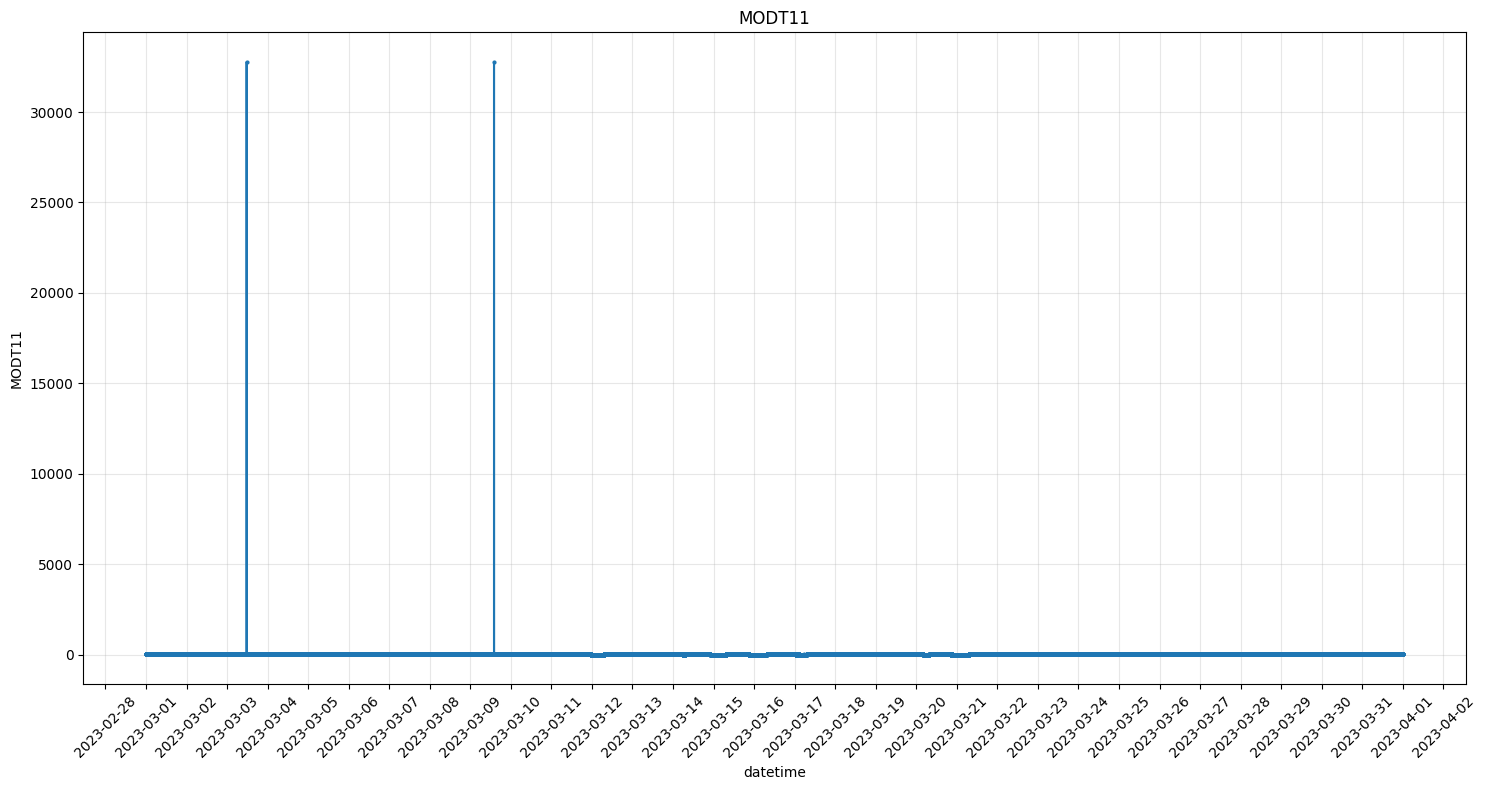

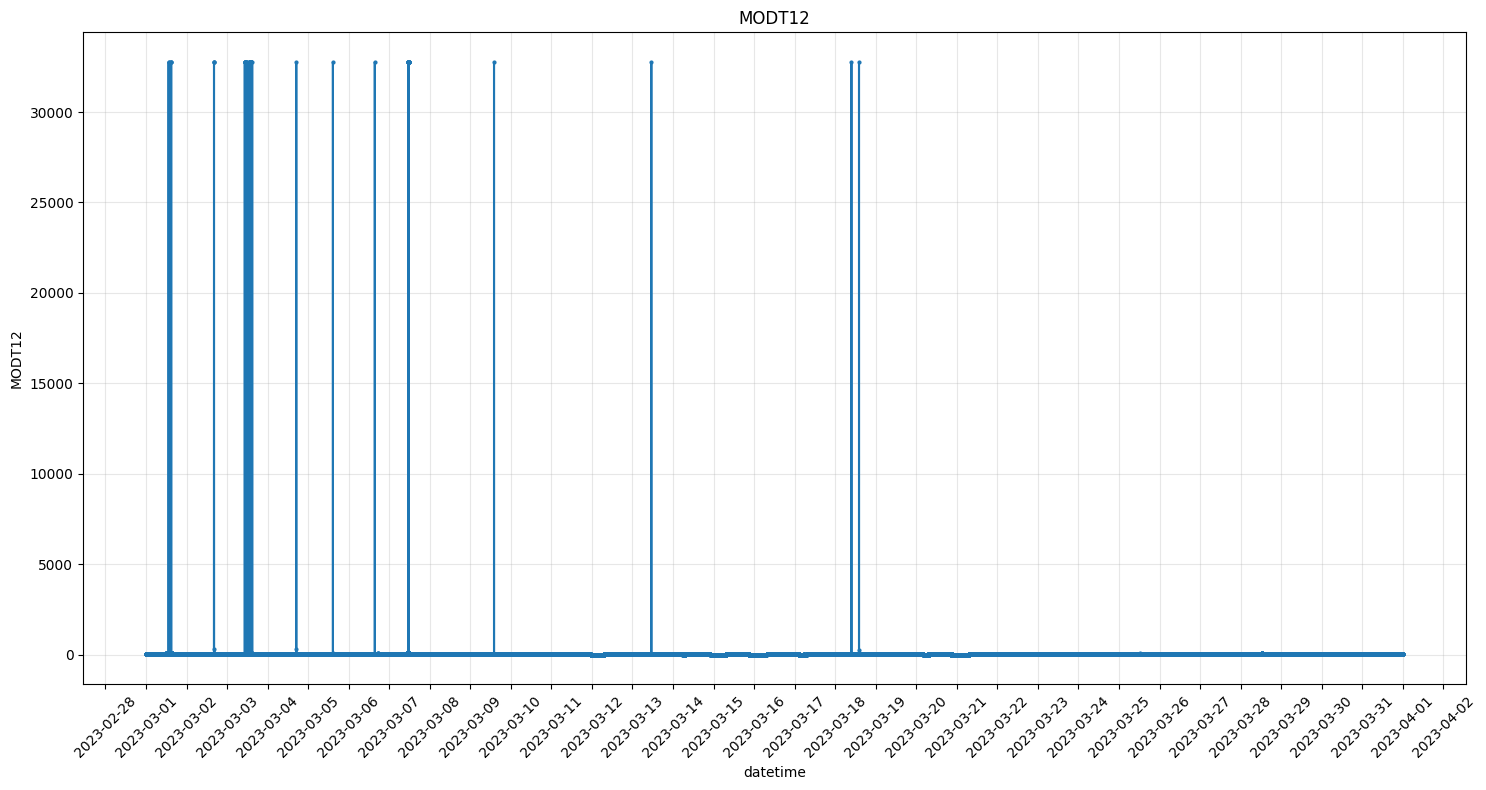

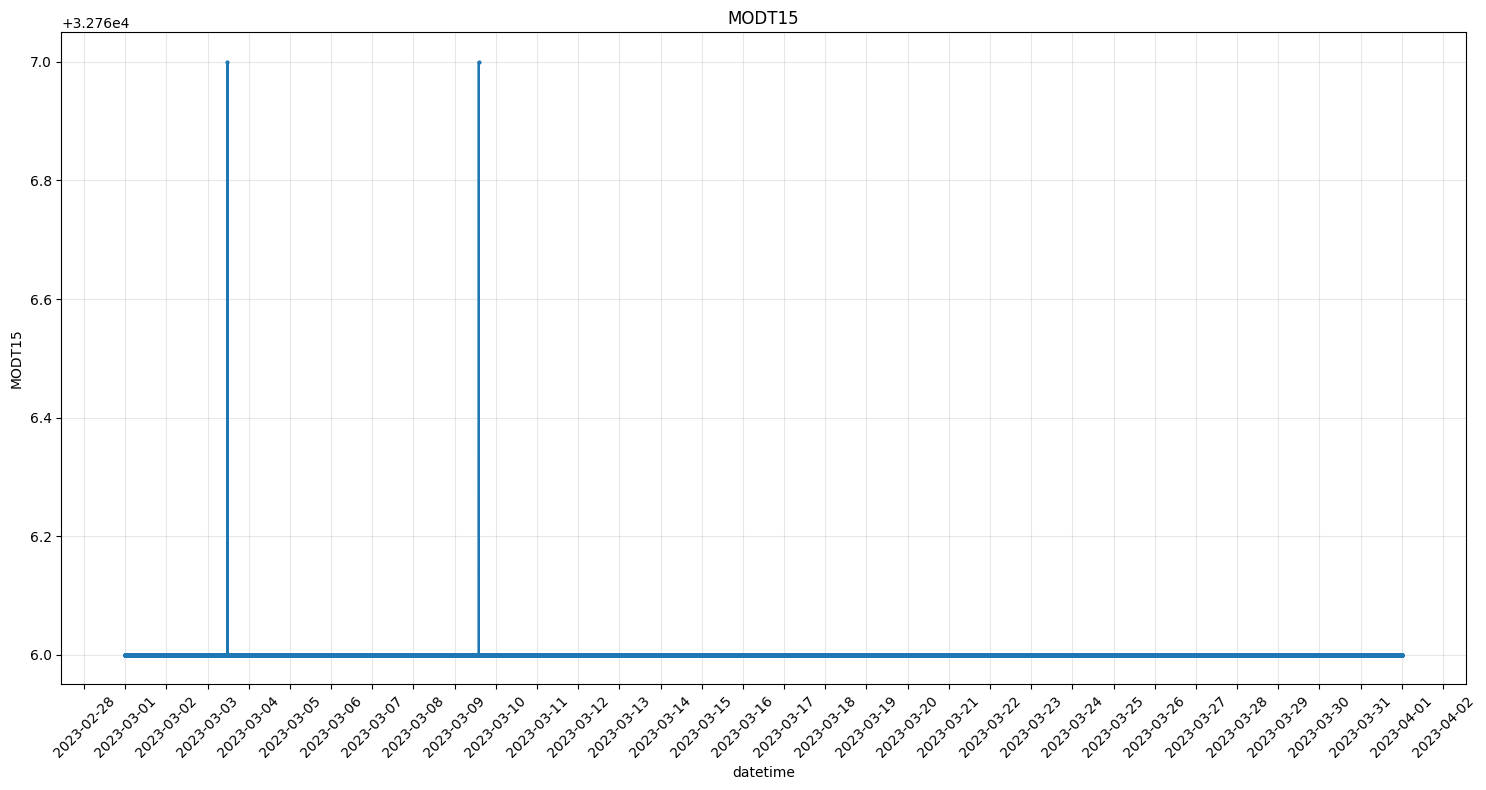

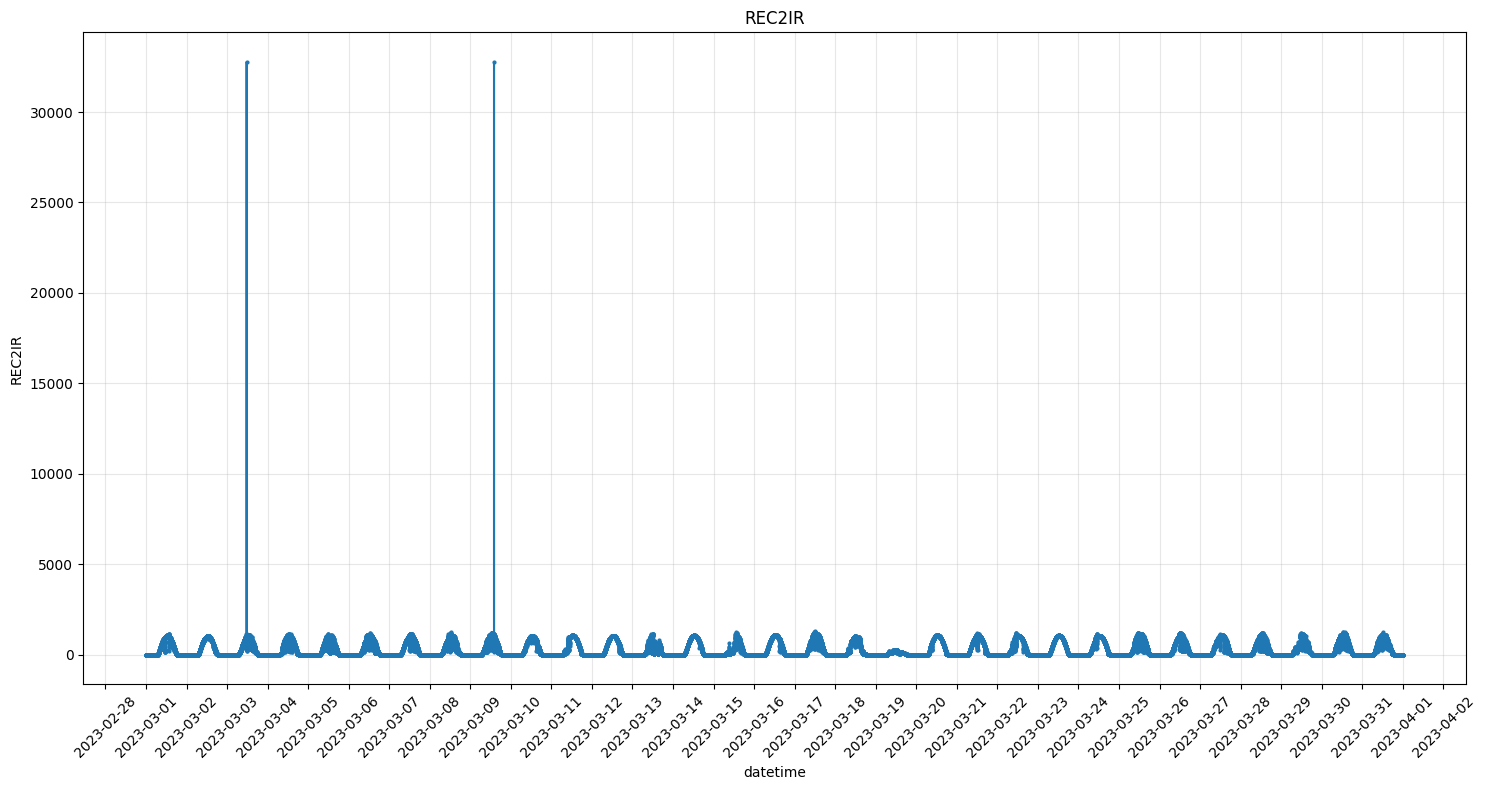

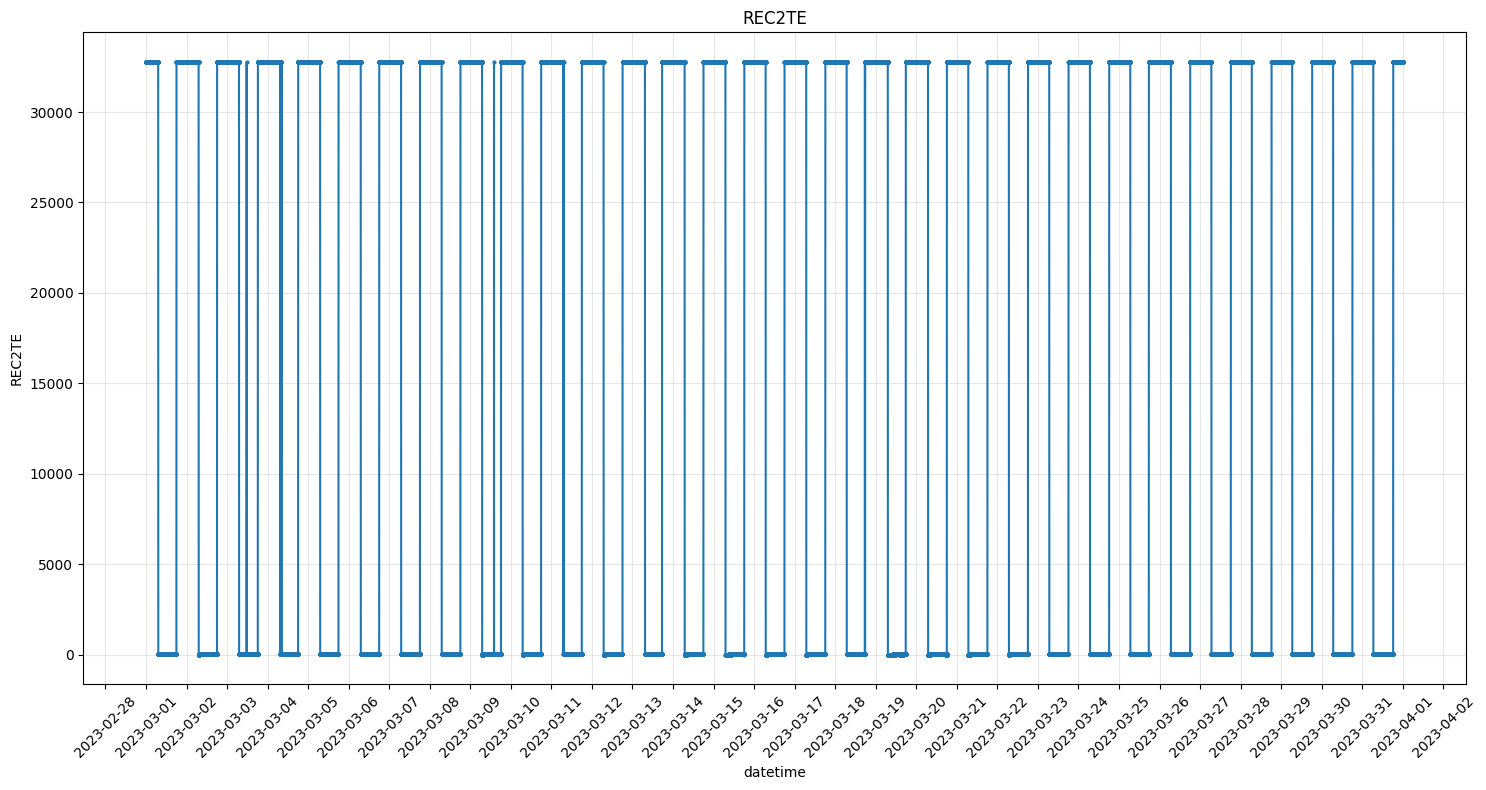

In [ ]:
#Visualizar gráficas
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

campos = [
    'SY2VDC',
    'S2S1DC',
    'S2S2DC',
    'S2VACA',
    'S2WACA',
    'S2PFAV',
    'S2FRQA',
    'MODT09',
    'MODT10',
    'MODT11',
    'MODT12',
    'MODT15',
    'REC2IR',
    'REC2TE'
]

# Filtrar el día una sola vez
df_day = result_pvs2[(result_pvs2['datetime'] >= '2023-03-01') & (result_pvs2['datetime'] < '2023-04-01') ][['datetime'] + campos].copy()

# Ordenar por hora para que las líneas se unan correctamente
df_day = df_day.sort_values('datetime')

# Generar una gráfica por cada campo
for campo in campos:

    plt.figure(figsize=(15, 8))

    plt.plot(
        df_day['datetime'],
        df_day[campo],
        marker='o',
        linestyle='-',
        markersize=2
    )

    plt.xlabel('datetime')
    plt.ylabel(campo)
    plt.title(f'{campo}')

    # Mostrar menos etiquetas en el eje X para que sea legible
    ax = plt.gca()
    ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=36))

    plt.xticks(rotation=45)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

Se detectan outliers. ¿Que hacemos con ellas?

In [ ]:
result_pvs2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3155040 entries, 2103839 to 5258878
Data columns (total 24 columns):
 #   Column    Dtype         
---  ------    -----         
 0   DAY       int64         
 1   HOUR      object        
 2   SY2VDC    float64       
 3   S2S1DC    float64       
 4   S2S2DC    float64       
 5   S2VACA    float64       
 6   S2WACA    float64       
 7   S2PFAV    float64       
 8   S2FRQA    float64       
 9   MODT09    float64       
 10  MODT10    float64       
 11  MODT11    float64       
 12  MODT12    float64       
 13  MODT15    float64       
 14  REC2IR    float64       
 15  REC2TE    float64       
 16  GHRADA    float64       
 17  DIRRAA    float64       
 18  PMBARA    float64       
 19  WSMEAN    float64       
 20  WDIREA    float64       
 21  TMPCAV    float64       
 22  RHPCTA    float64       
 23  datetime  datetime64[ns]
dtypes: datetime64[ns](1), float64(21), int64(1), object(1)
memory usage: 601.8+ MB
